# Notebook - Find best Drug compound for different viruses
- Marburg virus
- Ebola virus
- Lassa virus
- Nipah virus
- Venezuelan equine encephalitis virus (VEEV)
- Hantavirus
- SARS-CoV
- SARS-CoV-2

In this notebook, we demonstrate the use of MACAW embeddings to model binding affinity to a protein receptor of pharmacological interest. MACAW embeddings are then applied to identify promising candidate molecules in a custom virtual library.

In [1]:
import sys
import os

# Completely suppress stderr output
sys.stderr = open(os.devnull, 'w')

# Now import everything
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score

#Needed to show molecules
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole 
import seaborn as sns
from copy import deepcopy
import pickle

import sys
sys.path.append('../')

import macaw
print(macaw.__version__)
from macaw import *

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']
matplotlib.rcParams['figure.dpi'] = 96
matplotlib.rcParams['savefig.dpi'] = 600

%run "./plotting.py"

1.0.1


In [3]:
%config InlineBackend.figure_format = 'retina'

## 1. Regression Target: pPotency

### 1.1 Data preparation

In [4]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')
resultsDir = os.path.join(dataDir, 'Results/')
saveDir = os.path.join(resultsDir, "AllVirus/")
os.makedirs(saveDir, exist_ok=True)

In [5]:
allVirusData_chEMBL = pd.read_csv(modelBuildingDataDir + 'allVirusData_chEMBL_uM_wMACAW.csv')

### Filter columns

In [6]:
allVirusData_chEMBL = allVirusData_chEMBL.filter(
    items=["molecule_chembl_id", "smiles", "value_uM", "pPotency", "Virus"]
)
allVirusData_chEMBL

,molecule_chembl_id,smiles,value_uM,pPotency,Virus
0,CHEMBL5087131,CC(C)C[C@H](NCc1ccc(-c2ccccc2)cc1)C(=O)N[C@@H]...,4.0000,NaN,SARS-CoV-2
1,CHEMBL4065616,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,0.0100,8.000000,SARS-CoV-2
2,CHEMBL4852507,C=CCn1ccc2c(C(=O)Oc3cncc(Cl)c3)cccc21,15.0000,4.823909,SARS-CoV-2
3,CHEMBL4846056,CC(C)(C)OC(=O)N[C@@H](Cc1ccccc1)[C@@H](O)CN1CC...,10.0500,4.997834,SARS-CoV-2
4,CHEMBL5419985,CC(C)(C)[C@H](NC(=O)C(F)(F)F)C(=O)N1C[C@@H]2CC...,0.0640,7.193820,SARS-CoV-2
...,...,...,...,...,...
14492,CHEMBL5590446,CC1(C)[C@H]2CC[C@](C)(C2)[C@H]1OC(=O)CCCN1CCCCC1,4.6000,5.337242,Marburg
14493,CHEMBL5584026,CN1CCN(CC(=O)O[C@H]2C(C)(C)[C@H]3CC[C@]2(C)C3)CC1,25.0000,4.602060,Marburg
14494,CHEMBL1631748,O=c1c(/C=N/Cc2ccco2)c(CSc2ccc(Cl)cc2)[nH]n1-c1...,0.0013,8.886057,Hanta
14495,CHEMBL1630982,O=C(NCc1ccc2c(c1)OCO2)C(Cc1ccccc1)NS(=O)(=O)c1...,0.0016,8.795880,Hanta


### Remove `Remdesivir` from training set

In [7]:
Remdesivir_SMILES = 'CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](C#N)([C@H](O)[C@@H]1O)C1=CC=C2N1N=CN=C2N)OC1=CC=CC=C1'

# Canonicalize the Remdesivir SMILES
remMol = Chem.MolFromSmiles(Remdesivir_SMILES)
remCan = Chem.MolToSmiles(remMol, canonical=True)

# Canonicalize all SMILES in your dataframe
allVirusData_chEMBL["canonical_smiles"] = (
    allVirusData_chEMBL["smiles"]
    .apply(lambda s: Chem.MolToSmiles(Chem.MolFromSmiles(s), canonical=True)
          if Chem.MolFromSmiles(s) else None)
)

# Split into two dataframes
allVirusData_chEMBL_wRemdesivir = allVirusData_chEMBL[
    allVirusData_chEMBL["canonical_smiles"] == remCan
].copy()

allVirusData_chEMBL_clean = allVirusData_chEMBL[
    allVirusData_chEMBL["canonical_smiles"] != remCan
].copy()

print(f"Original shape: {len(allVirusData_chEMBL)}")
print(f"Remdesivir only: {len(allVirusData_chEMBL_wRemdesivir)}")
print(f"Without Remdesivir: {len(allVirusData_chEMBL_clean)}")

allVirusData_chEMBL = allVirusData_chEMBL_clean.copy()

Original shape: 14497
Remdesivir only: 181
Without Remdesivir: 14316


### Remdesivir `pPotency` Statistics by Virus

In [8]:
# Calculate statistics by virus
remdesivir_stats = allVirusData_chEMBL_wRemdesivir.groupby('Virus')['pPotency'].agg([
    ('Average', 'mean'),
    ('Std', 'std'),
    ('Min', 'min'),
    ('Max', 'max'),
    ('Count', 'count')
]).reset_index()

# Calculate overall statistics for all viruses
all_viruses_stats = pd.DataFrame({
    'Virus': ['All Viruses'],
    'Average': [allVirusData_chEMBL_wRemdesivir['pPotency'].mean()],
    'Std': [allVirusData_chEMBL_wRemdesivir['pPotency'].std()],
    'Min': [allVirusData_chEMBL_wRemdesivir['pPotency'].min()],
    'Max': [allVirusData_chEMBL_wRemdesivir['pPotency'].max()],
    'Count': [allVirusData_chEMBL_wRemdesivir['pPotency'].count()]
})

# Concatenate the individual virus stats with the overall stats
remdesivir_stats = pd.concat([remdesivir_stats, all_viruses_stats], ignore_index=True)

# Round for better display
remdesivir_stats = remdesivir_stats.round(3)

print("\nRemdesivir pPotency Statistics by Virus:")
remdesivir_stats


Remdesivir pPotency Statistics by Virus:


,Virus,Average,Std,Min,Max,Count
0,Ebola,6.664,0.996,4.066,7.921,24
1,Lassa,5.691,0.196,5.553,5.830,2
2,Nipah,7.538,0.000,7.538,7.538,4
3,SARS-CoV,6.937,0.580,5.754,7.222,6
4,SARS-CoV-2,6.342,1.015,4.174,8.903,145
5,All Viruses,6.423,1.008,4.066,8.903,181


### Add some randomization

### Rename columns

In [9]:
allVirusData_chEMBL = allVirusData_chEMBL.rename(columns={
    "molecule_chembl_id": "compound_id",
    "smiles": "Smiles",
    "Virus" : "VirusClassifier",
})

### Compound Distribution Across Viruses

In [10]:
virus_counts = allVirusData_chEMBL['VirusClassifier'].value_counts().sort_values(ascending=False)
total_compounds = len(allVirusData_chEMBL)

print(f"\n{'Virus':<30} {'Count':>10} {'Percentage':>12}")
print("-"*70)

for virus, count in virus_counts.items():
    percentage = (count / total_compounds) * 100
    print(f"{virus:<30} {count:>10} {percentage:>11.2f}%")

print("-"*70)
print(f"{'TOTAL':<30} {total_compounds:>10} {100.0:>11.2f}%")
print(f"\nNumber of unique viruses: {len(virus_counts)}")


Virus                               Count   Percentage
----------------------------------------------------------------------
SARS-CoV-2                          12709       88.77%
Ebola                                 702        4.90%
SARS-CoV                              269        1.88%
Lassa                                 215        1.50%
VEEV                                  209        1.46%
Marburg                               203        1.42%
Nipah                                   6        0.04%
Hanta                                   3        0.02%
----------------------------------------------------------------------
TOTAL                               14316      100.00%

Number of unique viruses: 8


### Add `ID` column to left

In [11]:
allVirusData_chEMBL.insert(0, 'ID', range(1, len(allVirusData_chEMBL) + 1))
allVirusData_chEMBL.head()

,ID,compound_id,Smiles,value_uM,pPotency,VirusClassifier,canonical_smiles
0,1,CHEMBL5087131,CC(C)C[C@H](NCc1ccc(-c2ccccc2)cc1)C(=O)N[C@@H]...,4.000,NaN,SARS-CoV-2,CC(C)C[C@H](NCc1ccc(-c2ccccc2)cc1)C(=O)N[C@@H]...
2,2,CHEMBL4852507,C=CCn1ccc2c(C(=O)Oc3cncc(Cl)c3)cccc21,15.000,4.823909,SARS-CoV-2,C=CCn1ccc2c(C(=O)Oc3cncc(Cl)c3)cccc21
3,3,CHEMBL4846056,CC(C)(C)OC(=O)N[C@@H](Cc1ccccc1)[C@@H](O)CN1CC...,10.050,4.997834,SARS-CoV-2,CC(C)(C)OC(=O)N[C@@H](Cc1ccccc1)[C@@H](O)CN1CC...
4,4,CHEMBL5419985,CC(C)(C)[C@H](NC(=O)C(F)(F)F)C(=O)N1C[C@@H]2CC...,0.064,7.193820,SARS-CoV-2,CC(C)(C)[C@H](NC(=O)C(F)(F)F)C(=O)N1C[C@@H]2CC...
5,5,CHEMBL46286,COC(=O)C[C@](O)(CCCC(C)(C)O)C(=O)O[C@@H]1C(OC)...,2.100,5.677781,SARS-CoV-2,COC(=O)C[C@](O)(CCCC(C)(C)O)C(=O)O[C@@H]1C(OC)...


### Add another filer to keep only these four columns: `ID`, `compound_id`,	`Smiles`, `pPotency`, `VirusClassifier`

In [12]:
allVirusData_chEMBL = allVirusData_chEMBL.filter(
    items=["ID", "compound_id", "Smiles", "pPotency", "VirusClassifier"]
)
allVirusData_chEMBL.head()

,ID,compound_id,Smiles,pPotency,VirusClassifier
0,1,CHEMBL5087131,CC(C)C[C@H](NCc1ccc(-c2ccccc2)cc1)C(=O)N[C@@H]...,NaN,SARS-CoV-2
2,2,CHEMBL4852507,C=CCn1ccc2c(C(=O)Oc3cncc(Cl)c3)cccc21,4.823909,SARS-CoV-2
3,3,CHEMBL4846056,CC(C)(C)OC(=O)N[C@@H](Cc1ccccc1)[C@@H](O)CN1CC...,4.997834,SARS-CoV-2
4,4,CHEMBL5419985,CC(C)(C)[C@H](NC(=O)C(F)(F)F)C(=O)N1C[C@@H]2CC...,7.193820,SARS-CoV-2
5,5,CHEMBL46286,COC(=O)C[C@](O)(CCCC(C)(C)O)C(=O)O[C@@H]1C(OC)...,5.677781,SARS-CoV-2


In [13]:
p = allVirusData_chEMBL["pPotency"]
total = len(p)

# Define categories with conditions
ranges = {
    "NaN values":        p.isna(),
    "Negative values":   p < 0,
    "0–3":               (p >= 0) & (p < 3),
    "3–10":              (p >= 3) & (p < 10),
    "10–12":             (p >= 10) & (p <= 12),
    ">12":               p > 12
}

# Build summary table
summaryRows = []
for label, condition in ranges.items():
    count = condition.sum()
    summaryRows.append([label, count, round(count/total*100, 2)])

summaryDF = pd.DataFrame(summaryRows, columns=["Category", "Count", "Percentage (%)"])
summaryDF.loc[len(summaryDF)] = ["Total", summaryDF["Count"].sum(), summaryDF["Percentage (%)"].sum()]
summaryDF

,Category,Count,Percentage (%)
0,NaN values,9803,68.48
1,Negative values,0,0.00
2,0–3,11,0.08
3,3–10,4490,31.36
4,10–12,12,0.08
5,>12,0,0.00
6,Total,14316,100.00


### Remove NaN, -ve and unphysical (>12) values in `pPotency` before cross-validation

| Range (pPotency) | IC₅₀/EC₅₀ (in M)          | Interpretation                                | Action              |
| ---------------- | -------------------- | --------------------------------------------- | ------------------- |
| **0–3**   | > 1×10⁻³ M (millimolar)     | Very weak or inactive compounds               | Drop         |
| **3–10**  | 1×10⁻³ – 1×10⁻¹⁰ M          | Normal drug-like activity range               | **Keep**                |
| **10–12** | 1×10⁻¹⁰ – 1×10⁻¹² M         | Extremely potent but still physically possible | **Keep (with caution)** |
| **>12**   | < 1×10⁻¹² M (picomolar–femto) | Physically unrealistic / likely data error     | Drop                |



In [14]:
print("Original shape:", allVirusData_chEMBL.shape)

allVirusData_chEMBL = allVirusData_chEMBL[allVirusData_chEMBL['pPotency'].notna() 
    & (allVirusData_chEMBL['pPotency'] > 0) ]   # & (allVirusData_chEMBL['pPotency'] < 12)

print("Shape after cleaning 'pPotency' value:", allVirusData_chEMBL.shape)

Original shape: (14316, 5)
Shape after cleaning 'pPotency' value: (4513, 5)


In [15]:
p = allVirusData_chEMBL["pPotency"]

count_0_3   = ((p >= 0) & (p < 3)).sum()
count_3_10  = ((p >= 3) & (p < 10)).sum()
count_10_12 = ((p >= 10) & (p <= 12)).sum()
count_gt_12 = (p > 12).sum()

print("pPotency Distribution:")
total = len(p)
print(f"  0–3     : {count_0_3/total*100:.2f}%")
print(f"  3–10    : {count_3_10/total*100:.2f}%")
print(f" 10–12    : {count_10_12/total*100:.2f}%")
print(f" >12      : {count_gt_12/total*100:.2f}%")

pPotency Distribution:
  0–3     : 0.24%
  3–10    : 99.49%
 10–12    : 0.27%
 >12      : 0.00%


### Count duplicate SMILES

In [16]:
duplicates = allVirusData_chEMBL.duplicated(subset=['Smiles', 'VirusClassifier'])
print("Remaining duplicates:", duplicates.sum())

Remaining duplicates: 1814


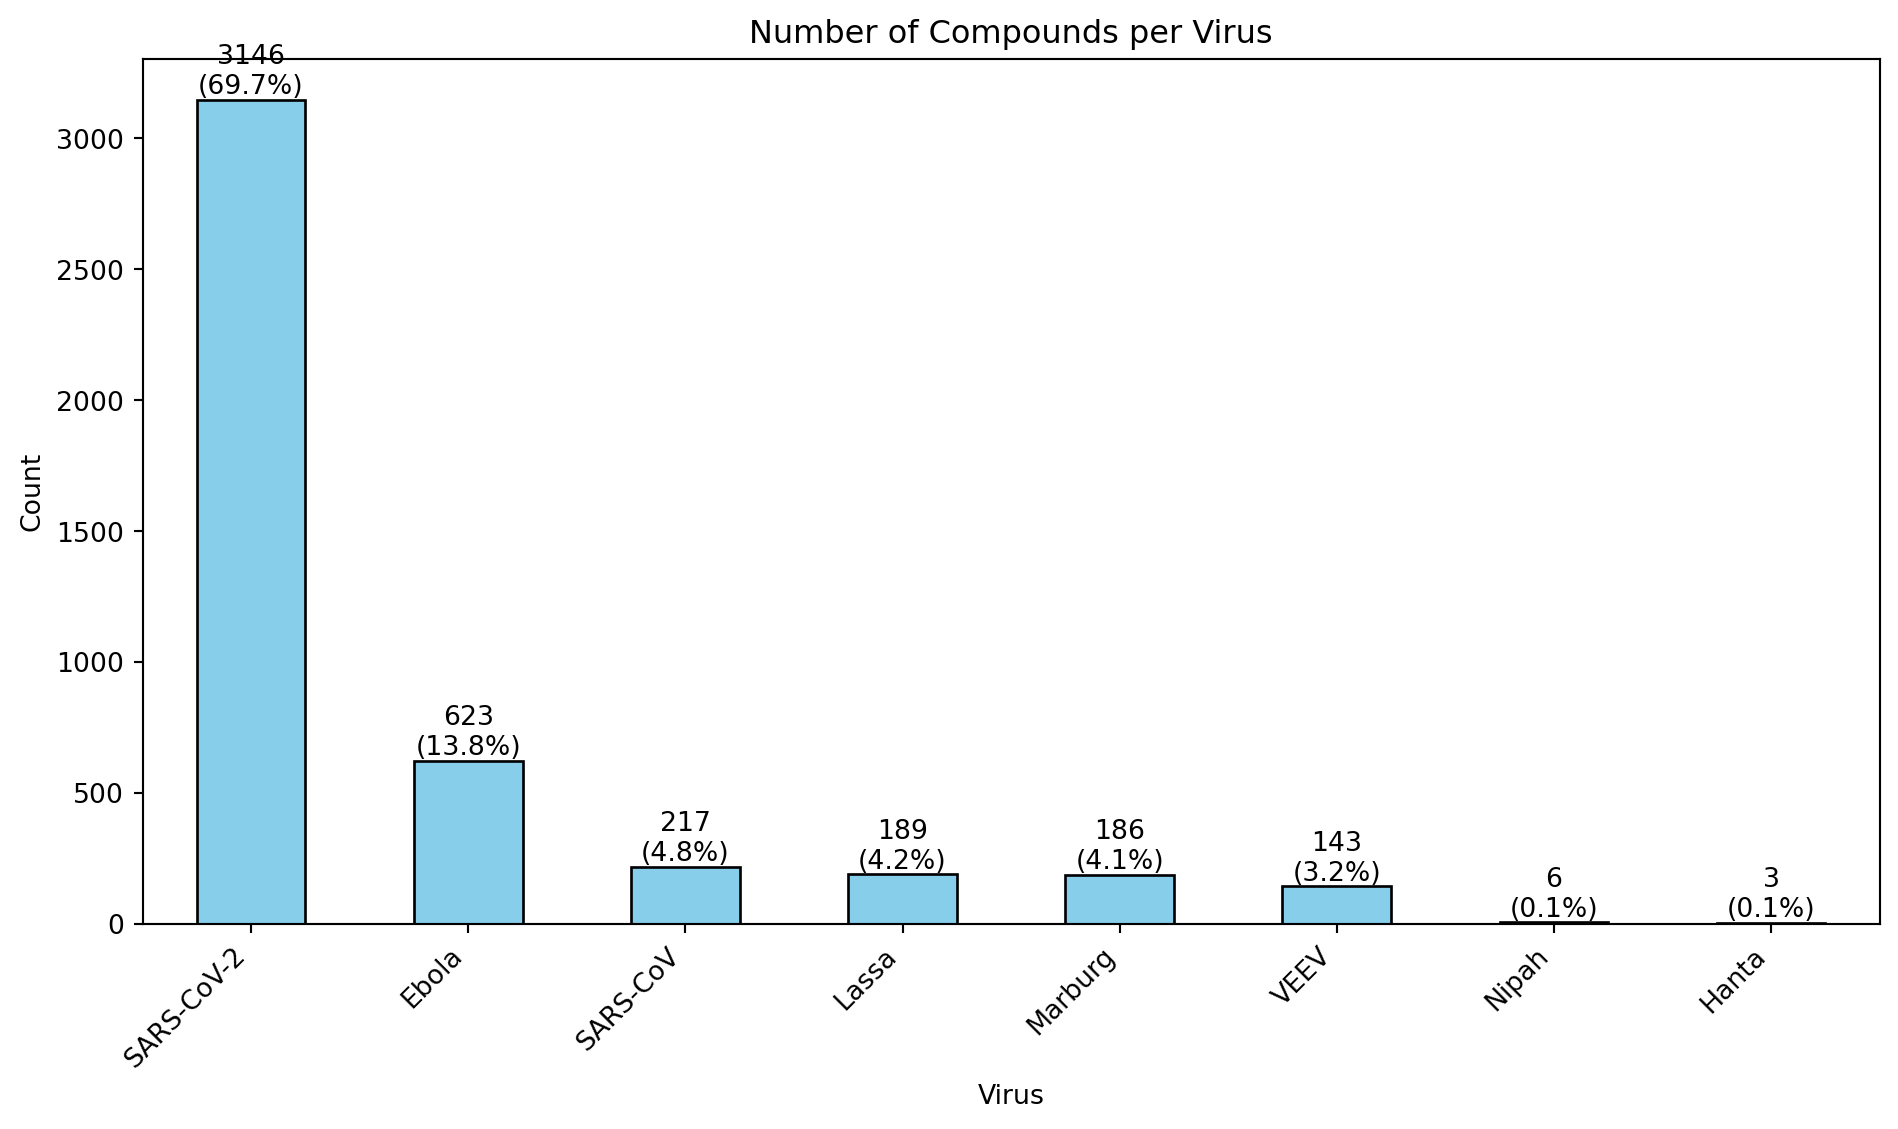

In [17]:
# Get counts and percentages
counts = allVirusData_chEMBL['VirusClassifier'].value_counts()
percentages = counts / counts.sum() * 100

# Create bar plot
plt.figure(figsize=(10, 6))
bars = counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Number of Compounds per Virus')
plt.xlabel('Virus')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

# Annotate each bar with count and %
for i, (count, pct) in enumerate(zip(counts, percentages)):
    plt.text(
        i, count + 1,                 # position (x, y)
        f'{count}\n({pct:.1f}%)',     # label: count + percentage
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()

In [18]:
allVirusData_chEMBL.to_csv(os.path.join(modelBuildingDataDir, "allVirusData_chEMBL_MLready.csv"), index=False)

### Arrange Virus alphabetically

In [19]:
allVirusData_chEMBL_ordered = allVirusData_chEMBL.sort_values(by='VirusClassifier')
allVirusData_chEMBL_ordered.head()

,ID,compound_id,Smiles,pPotency,VirusClassifier
13222,13070,CHEMBL4212614,O=S(=O)(c1cc(Cl)cc(Cl)c1)N1CCCC2=C[C@H]3C[C@H]...,4.974694,Ebola
13554,13389,CHEMBL5290974,COC(=O)[C@H]1C[C@H](OCCN)[C@@H](O[C@H]2O[C@H](...,3.207608,Ebola
13555,13390,CHEMBL5287023,CCN(CC)Cc1cc(Nc2c(Oc3ccccc3)cnc3cc(Cl)ccc23)ccc1O,6.136677,Ebola
13556,13391,CHEMBL809,CN[C@H]1CC[C@@H](c2ccc(Cl)c(Cl)c2)c2ccccc21,5.504456,Ebola
13557,13392,CHEMBL809,CN[C@H]1CC[C@@H](c2ccc(Cl)c(Cl)c2)c2ccccc21,5.841638,Ebola


### pPotency value distribution across each Virus

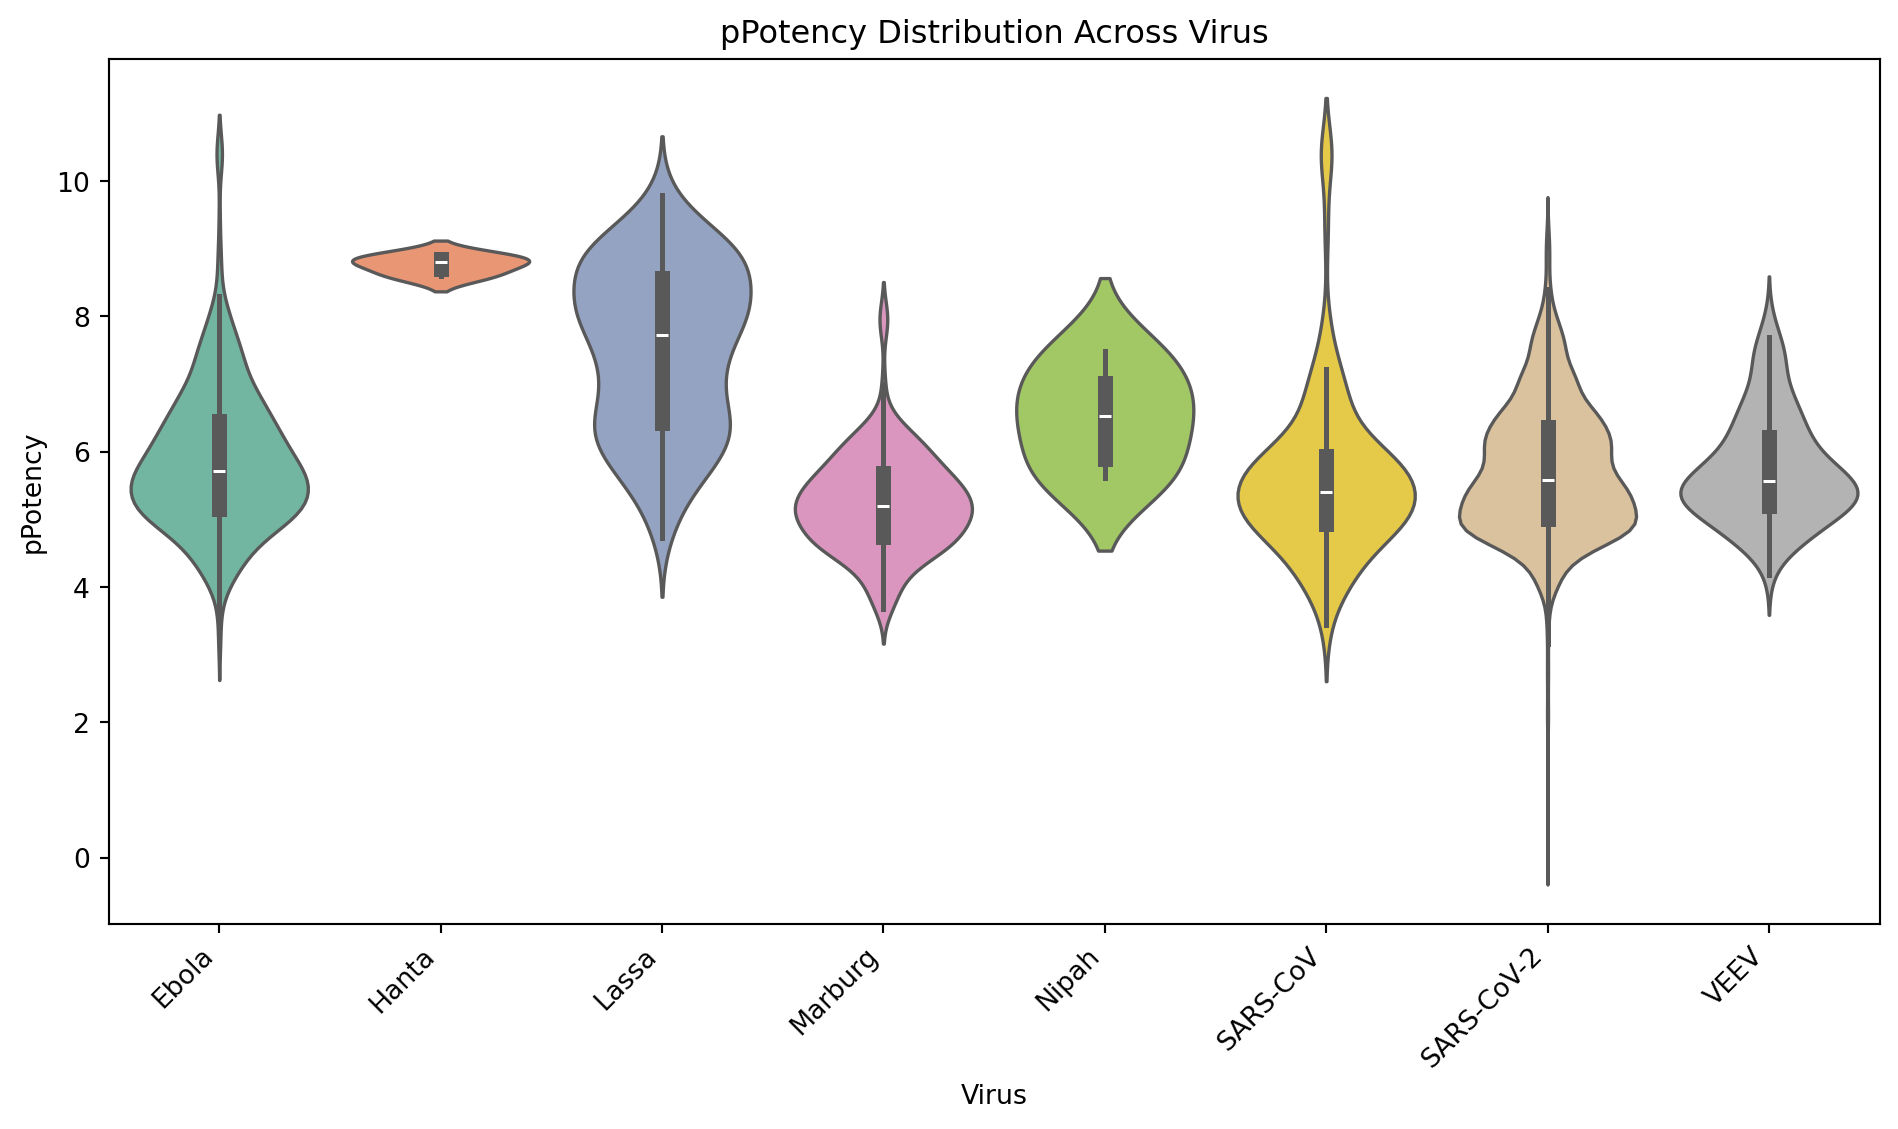

In [20]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=allVirusData_chEMBL_ordered,
    x='VirusClassifier',
    y='pPotency',
    palette='Set2',
    inner='box'
)

plt.xticks(rotation=45, ha='right')
plt.title('pPotency Distribution Across Virus')
plt.xlabel('Virus')
plt.ylabel('pPotency')
plt.tight_layout()
plt.show()

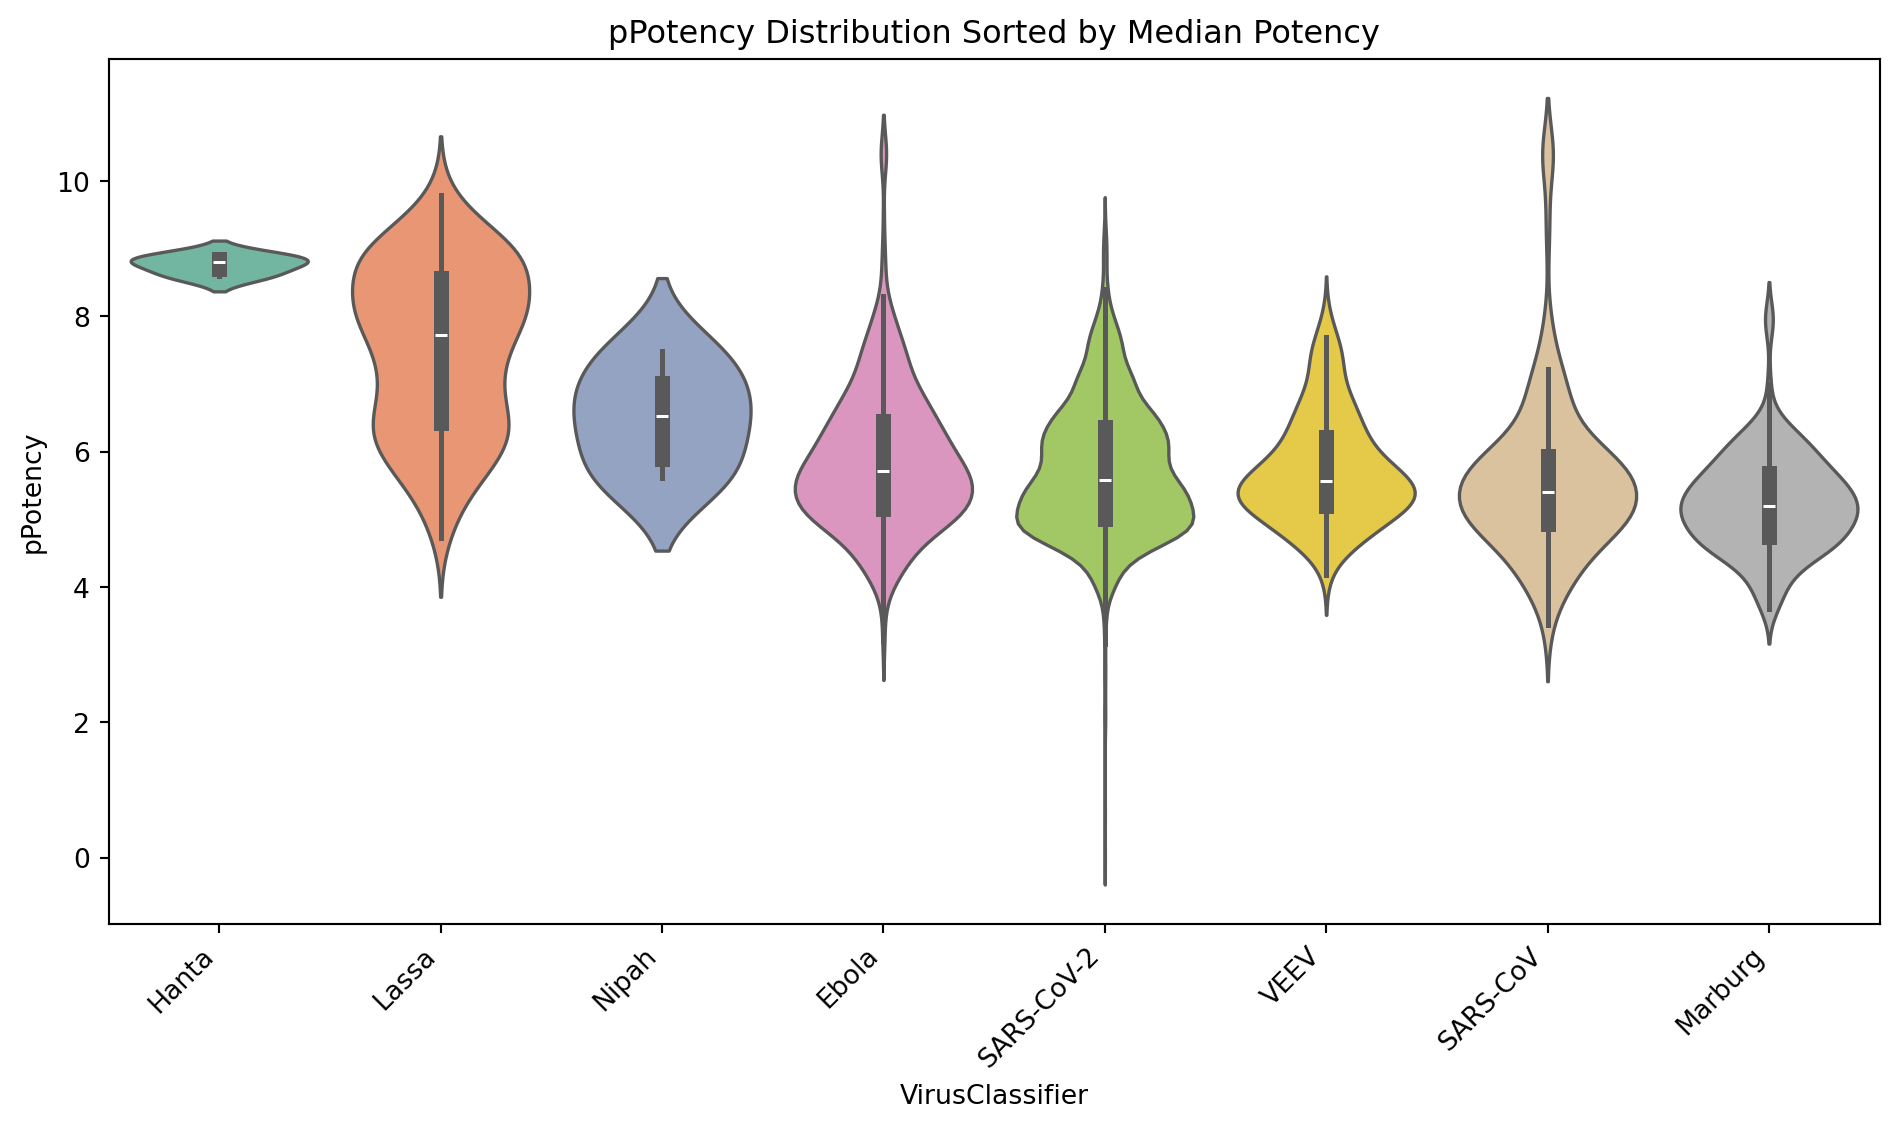

In [21]:
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=allVirusData_chEMBL_ordered,
    x='VirusClassifier',
    y='pPotency',
    palette='Set2',
    order=(
        allVirusData_chEMBL_ordered
        .groupby('VirusClassifier')['pPotency']
        .median()
        .sort_values(ascending=False)
        .index
    )
)
plt.xticks(rotation=45, ha='right')
plt.title('pPotency Distribution Sorted by Median Potency')
plt.tight_layout()
plt.show()

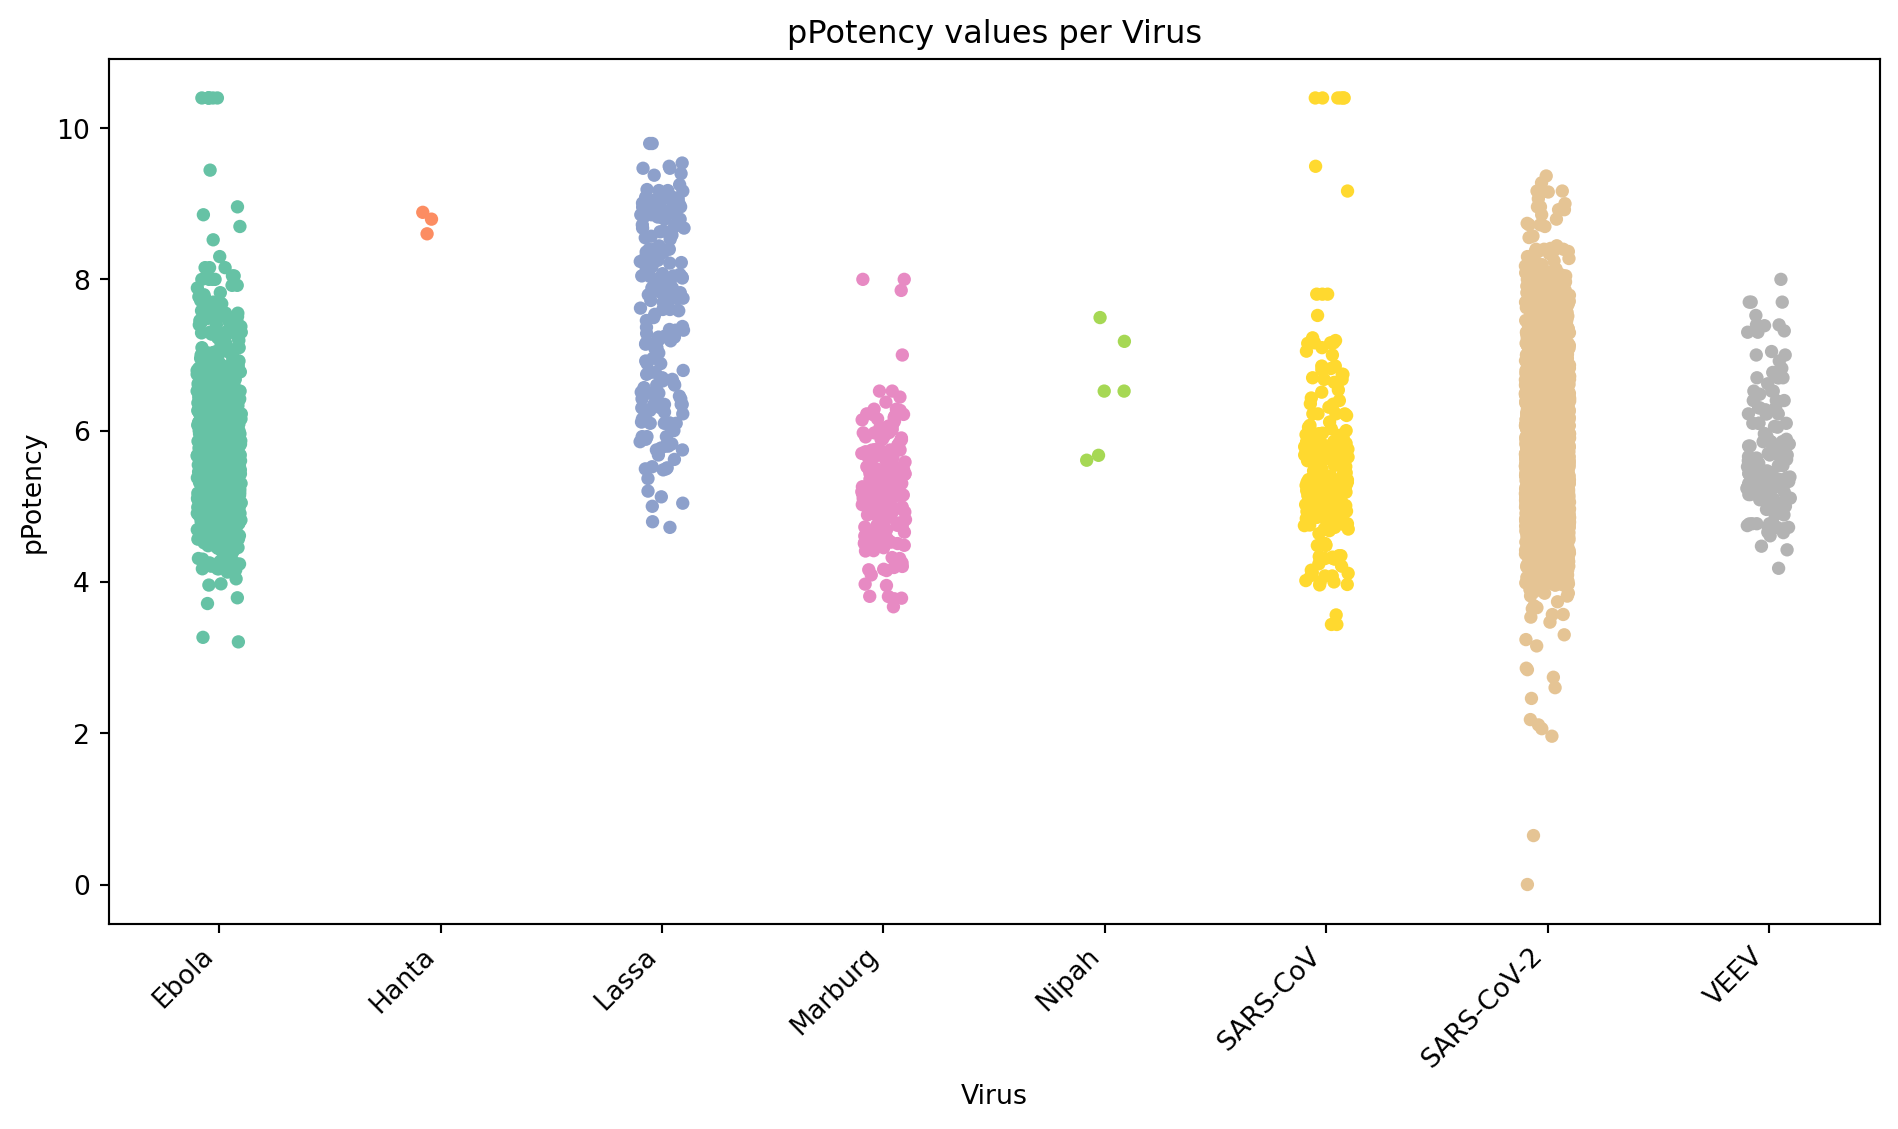

In [22]:
plt.figure(figsize=(10, 6))
sns.stripplot(
    data=allVirusData_chEMBL_ordered,
    x='VirusClassifier',
    y='pPotency',
    jitter=True,          # spreads the dots to avoid overlap
    palette='Set2',
    alpha=1
)
plt.xticks(rotation=45, ha='right')
plt.title('pPotency values per Virus')
plt.xlabel('Virus')
plt.ylabel('pPotency')
plt.tight_layout()
plt.show()

### Clip first 1000 rows from the data set for fast testing

### Create MACAW embeedings to run ART

In [23]:
allVirusData_chEMBL.columns

Index(['ID', 'compound_id', 'Smiles', 'pPotency', 'VirusClassifier'], dtype='object')

MACAW settings (coarse):

mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=200, 
    random_state=42
)


MACAW settings (fine):
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=45, 
    n_landmarks=2000, 
    random_state=42
)

In [24]:
# ---------------------------
# 1. FIT MACAW AND GENERATE EMBEDDINGS
# ---------------------------
# Initialize MACAW
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=200, 
    random_state=42
)

# Fit MACAW on SMILES and pPotency
mcw.fit(allVirusData_chEMBL['Smiles'], allVirusData_chEMBL['pPotency'])

# Save MACAW transformer
macaw_save_path = os.path.join(modelBuildingDataDir, "allVirusData_chEMBL_MACAW_transformer.joblib")
with open(macaw_save_path, 'wb') as f:
    pickle.dump(mcw, f)
print(f"MACAW transformer saved to: {macaw_save_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(allVirusData_chEMBL['Smiles'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")

# ---------------------------
# 2. CREATE DATAFRAME WITH EMBEDDINGS
# ---------------------------
# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=allVirusData_chEMBL.index)

# ---------------------------
# 3. CONCATENATE WITH ORIGINAL DATAFRAME
# ---------------------------
allVirusData_chEMBL_wMACAW = pd.concat([allVirusData_chEMBL, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {allVirusData_chEMBL.shape}")
print(f"New dataframe shape: {allVirusData_chEMBL_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
allVirusData_chEMBL_wMACAW.head()

MACAW transformer saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/allVirusData_chEMBL_MACAW_transformer.joblib
MACAW embeddings shape: (4513, 15)

Original dataframe shape: (4513, 5)
New dataframe shape: (4513, 20)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15']


,ID,compound_id,Smiles,pPotency,VirusClassifier,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,MACAW_8,MACAW_9,MACAW_10,MACAW_11,MACAW_12,MACAW_13,MACAW_14,MACAW_15
2,2,CHEMBL4852507,C=CCn1ccc2c(C(=O)Oc3cncc(Cl)c3)cccc21,4.823909,SARS-CoV-2,0.217738,-0.031447,-0.044342,-0.001320,-0.075413,0.037756,-0.047275,-0.010448,-0.058355,-0.022279,0.005351,-0.088648,-0.149209,0.055279,-0.019730
3,3,CHEMBL4846056,CC(C)(C)OC(=O)N[C@@H](Cc1ccccc1)[C@@H](O)CN1CC...,4.997834,SARS-CoV-2,-0.071457,0.037183,-0.126172,0.003091,0.071098,-0.035972,-0.020770,-0.034783,0.006979,0.009339,0.042201,0.044127,-0.032492,-0.026910,0.040156
4,4,CHEMBL5419985,CC(C)(C)[C@H](NC(=O)C(F)(F)F)C(=O)N1C[C@@H]2CC...,7.193820,SARS-CoV-2,-0.179532,-0.062806,-0.065860,-0.113641,0.052536,0.039251,-0.121876,-0.169874,-0.006342,0.115027,-0.132802,0.056286,-0.166178,-0.116255,0.102158
5,5,CHEMBL46286,COC(=O)C[C@](O)(CCCC(C)(C)O)C(=O)O[C@@H]1C(OC)...,5.677781,SARS-CoV-2,-0.107027,-0.069619,-0.075954,0.044638,0.071964,-0.002109,-0.113495,0.019113,-0.025058,-0.024908,-0.000667,0.076293,0.034652,-0.015838,-0.005553
7,6,CHEMBL4802135,CC(C)(C)[C@H](NC(=O)C(F)(F)F)C(=O)N1C[C@H]2[C@...,7.127844,SARS-CoV-2,-0.164884,-0.096613,-0.039586,-0.141431,0.047791,0.053376,-0.164457,-0.188033,0.016148,0.121460,-0.175393,0.087129,-0.175492,-0.097911,0.111749


In [25]:
allVirusData_chEMBL_wMACAW.to_csv(os.path.join(modelBuildingDataDir, "allVirusData_chEMBL_wMACAW.csv"), index=False)

### canonicalize SMILES to use for REINVENT4

In [26]:
# Function to canonicalize SMILES
def canonicalize_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            return Chem.MolToSmiles(mol, canonical=True)
        else:
            return None
    except:
        return None

# Canonicalize the existing 'Smiles' column
allVirusData_chEMBL_wMACAW['Smiles'] = allVirusData_chEMBL_wMACAW['Smiles'].apply(canonicalize_smiles)

# Optional: remove rows where canonicalization failed
allVirusData_chEMBL_wMACAW = allVirusData_chEMBL_wMACAW[allVirusData_chEMBL_wMACAW['Smiles'].notna()]

# Save to CSV
allVirusData_chEMBL_wMACAW[['Smiles']].to_csv(os.path.join(modelBuildingDataDir + "allVirusData_chEMBL_SMILES.csv"), index=False)

### Train ML Model

In [507]:
# df = allVirusData_chEMBL
Y = allVirusData_chEMBL.pPotency
smiles = allVirusData_chEMBL.Smiles

In [508]:
print(len(smiles))

4513


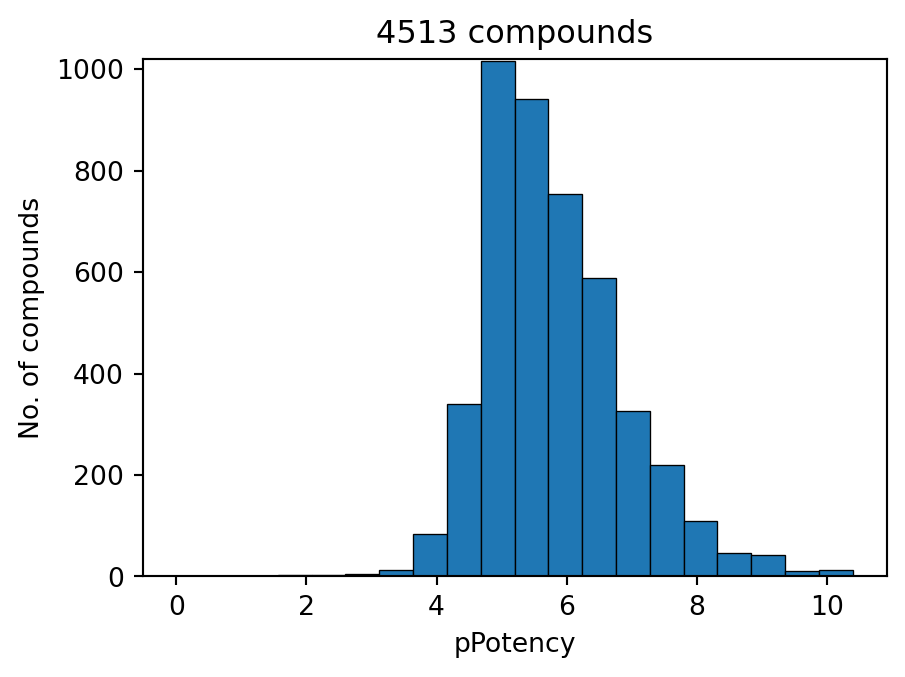

In [509]:
plot_histogram(Y, xlabel="pPotency")

Define the partitions for cross-validation.

In [510]:
num_of_partitions = 10
kf = KFold(n_splits=num_of_partitions, shuffle=True, random_state=42)

Define hyperparameters for SVR:

In [511]:
param_grid = {
    'C': [1, 5, 7, 10, 30, 50, 100, 300, 500], 
    'epsilon': [0.1, 0.3, 1, 3, 5, 10, 20],
    'kernel': ['rbf']
}

Define MACAW embedding:

In [530]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=200, 
    n_landmarks=4000, 
    random_state=42
)

After cleaning NaN values, reset the indices

In [522]:
valid_mask = Y.notna()
smiles = smiles[valid_mask].reset_index(drop=True)  
Y = Y[valid_mask].reset_index(drop=True)            

print(f"Cleaned data has: {len(smiles)} samples")
print(f"Y index: {Y.index[:10].tolist()}")  

Cleaned data has: 4513 samples
Y index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


### ML predictions with Train + Test results (SVR)

In [523]:
%%time
import numpy as np
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from joblib import Parallel, delayed
from copy import deepcopy

def process_fold(fold_id, train_index, test_index, smiles, Y, mcw, param_grid, num_partitions):
    """Process a single CV fold"""
    print(f"Partition {fold_id}/{num_partitions}")
    
    # Split data
    smi_train = smiles.iloc[train_index]
    smi_test = smiles.iloc[test_index]
    y_train = Y[train_index]
    y_test = Y[test_index]
    
    # Compute MACAW embeddings (clone to avoid conflicts)
    mcw_fold = deepcopy(mcw)
    mcw_fold.fit(smi_train, y_train)
    
    X_train = mcw_fold.transform(smi_train)
    X_test = mcw_fold.transform(smi_test)
    
    # Optimize hyperparameters
    grid = GridSearchCV(SVR(), param_grid, cv=5, refit=True)
    grid.fit(X_train, y_train)
    
    best_params = grid.best_params_
    
    # Predict on both train and test
    y_cv_pred_train = grid.predict(X_train)
    y_cv_pred_test = grid.predict(X_test)
    
    # Calculate fold metrics
    train_mae = mean_absolute_error(y_train, y_cv_pred_train)
    test_mae = mean_absolute_error(y_test, y_cv_pred_test)
    print(f"  Fold {fold_id} - Train MAE: {train_mae:.2f}, Test MAE: {test_mae:.2f}")
    
    # Return all predictions and parameters
    return {
        'train_pred': y_cv_pred_train,
        'train_obs': y_train,
        'test_pred': y_cv_pred_test,
        'test_obs': y_test,
        'best_params': best_params
    }

# Parallel execution
results = Parallel(n_jobs=4, verbose=10)(
    delayed(process_fold)(
        fold_id=i+1,
        train_index=train_idx,
        test_index=test_idx,
        smiles=smiles,
        Y=Y,
        mcw=mcw,
        param_grid=param_grid,
        num_partitions=num_of_partitions
    )
    for i, (train_idx, test_idx) in enumerate(kf.split(smiles))
)

# Combine results
Y_cv_pred_train = []
Y_obs_train = []
Y_cv_pred_test = []
Y_obs_test = []
best_params_per_fold = []

for fold_result in results:
    Y_cv_pred_train.extend(fold_result['train_pred'])
    Y_obs_train.extend(fold_result['train_obs'])
    Y_cv_pred_test.extend(fold_result['test_pred'])
    Y_obs_test.extend(fold_result['test_obs'])
    best_params_per_fold.append(fold_result['best_params'])

# Convert to numpy arrays
Y_cv_pred_train = np.array(Y_cv_pred_train)
Y_obs_train = np.array(Y_obs_train)
Y_cv_pred_test = np.array(Y_cv_pred_test)
Y_obs_test = np.array(Y_obs_test)

# ===== OVERALL METRICS =====
print("\n" + "-"*40)
print("Cross Validation Metrics")
print("-"*40)

# Train metrics
train_mae = mean_absolute_error(Y_obs_train, Y_cv_pred_train)
train_rmse = np.sqrt(mean_squared_error(Y_obs_train, Y_cv_pred_train))
train_r2 = r2_score(Y_obs_train, Y_cv_pred_train)

print(f"Train Set:")
print(f"  MAE:  {train_mae:.2f}")
print(f"  RMSE: {train_rmse:.2f}")
print(f"  R²:   {train_r2:.2f}")

# Test metrics
test_mae = mean_absolute_error(Y_obs_test, Y_cv_pred_test)
test_rmse = np.sqrt(mean_squared_error(Y_obs_test, Y_cv_pred_test))
test_r2 = r2_score(Y_obs_test, Y_cv_pred_test)

print(f"Test Set:")
print(f"  MAE:  {test_mae:.2f}")
print(f"  RMSE: {test_rmse:.2f}")
print(f"  R²:   {test_r2:.2f}")

print(f"\nBest params (sample): {best_params_per_fold[:3]}")


----------------------------------------
Cross Validation Metrics
----------------------------------------
Train Set:
  MAE:  0.30
  RMSE: 0.46
  R²:   0.82
Test Set:
  MAE:  0.47
  RMSE: 0.67
  R²:   0.61

Best params (sample): [{'C': 7, 'epsilon': 0.1, 'kernel': 'rbf'}, {'C': 7, 'epsilon': 0.1, 'kernel': 'rbf'}, {'C': 10, 'epsilon': 0.3, 'kernel': 'rbf'}]
CPU times: user 1.97 s, sys: 1.21 s, total: 3.17 s
Wall time: 5min 29s


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/AllVirus_bestMACAW/allVirus_CV_TrTs.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/AllVirus_bestMACAW/allVirus_CV_TrTs.png


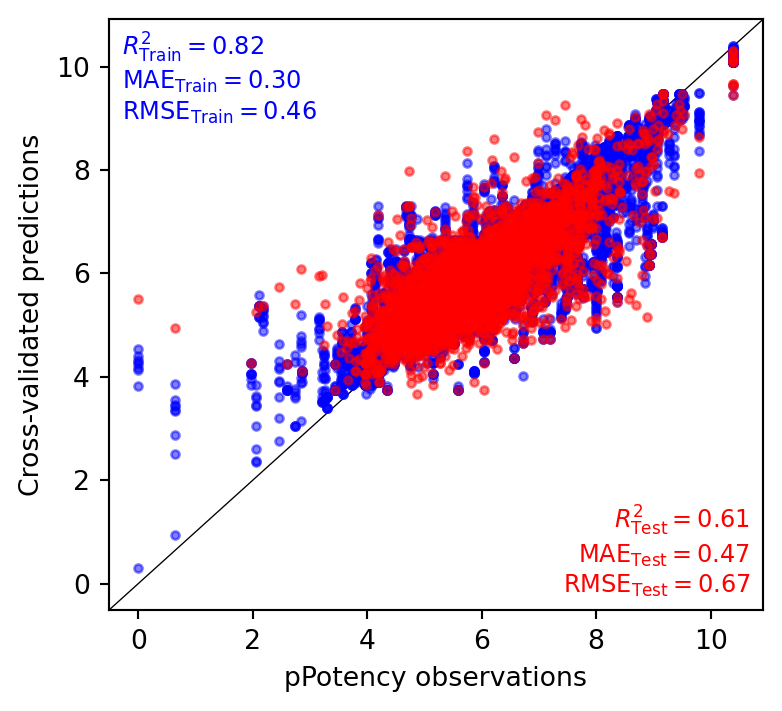

In [524]:
parity_plot(x=Y_obs_train, 
            y=Y_cv_pred_train, 
            x_test=Y_obs_test, 
            y_test=Y_cv_pred_test, 
            xlabel="pPotency observations", 
            ylabel="Cross-validated predictions",
            savetitle=saveDir + 'allVirus_CV_TrTs.svg',
            save_formats=['svg', 'png'])

Generate a model trained on the whole data set, to be used for prediction tasks

In [527]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=200, 
    n_landmarks=3500, 
    random_state=42
)
mcw.fit(smiles, Y)

In [528]:
X_all = mcw.transform(smiles)
X_all.shape

(4513, 200)

In [529]:
%%time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# ---------------------------
# 1. TRAIN-TEST SPLIT
# ---------------------------
# Since you're working with only one virus group, use regular train_test_split
X_train_smi, X_test_smi, Y_train, Y_test = train_test_split(
    smiles, Y, 
    test_size=0.2, 
    random_state=42,
    shuffle=True
)

print(f"Training samples: {len(X_train_smi)}")
print(f"Test samples: {len(X_test_smi)}")

# ---------------------------
# 2. FIT MACAW ON TRAINING DATA ONLY
# ---------------------------
mcw.fit(X_train_smi, Y_train)

# Transform both train and test
X_train = mcw.transform(X_train_smi)
X_test = mcw.transform(X_test_smi)

print(f"Feature dimensions: {X_train.shape[1]}")

# ---------------------------
# 3. GRID SEARCH ON TRAINING DATA ONLY
# ---------------------------
n_jobs = 4

regr_pred = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    cv=5,
    refit=True,
    n_jobs=n_jobs,
    verbose=0,
    scoring='neg_mean_absolute_error',
    return_train_score=True,
    pre_dispatch='2*n_jobs'
)

print(f"\nRunning GridSearchCV with {n_jobs} parallel jobs...")
regr_pred.fit(X_train, Y_train)

# ---------------------------
# 4. DISPLAY BEST HYPERPARAMETERS
# ---------------------------
print("\n" + "-"*60)
print("Best Hyperparameters:")
print("-"*60)
for param, value in regr_pred.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV MAE (on training folds): {-regr_pred.best_score_:.2f}")

# ---------------------------
# 5. PREDICTIONS AND METRICS
# ---------------------------
# Training predictions (in-sample)
y_train_pred = regr_pred.predict(X_train)

# Test predictions (held-out)
y_test_pred = regr_pred.predict(X_test)

# Calculate metrics for TRAIN
train_r2 = r2_score(Y_train, y_train_pred)
train_mae = mean_absolute_error(Y_train, y_train_pred)
train_rmse = np.sqrt(np.mean((Y_train - y_train_pred)**2))

# Calculate metrics for TEST
test_r2 = r2_score(Y_test, y_test_pred)
test_mae = mean_absolute_error(Y_test, y_test_pred)
test_rmse = np.sqrt(np.mean((Y_test - y_test_pred)**2))

# ---------------------------
# 6. DISPLAY RESULTS
# ---------------------------
print("\n" + "-"*60)
print("PERFORMANCE COMPARISON:")
print("-"*60)
print(f"{'Metric':<10} {'Training':<15} {'Test':<15} {'Difference':<15}")
print("-"*60)
print(f"{'R²':<10} {train_r2:<15.2f} {test_r2:<15.2f} {abs(train_r2-test_r2):<15.2f}")
print(f"{'MAE':<10} {train_mae:<15.2f} {test_mae:<15.2f} {abs(train_mae-test_mae):<15.2f}")
print(f"{'RMSE':<10} {train_rmse:<15.2f} {test_rmse:<15.2f} {abs(train_rmse-test_rmse):<15.2f}")
print("-"*60)

# Check for overfitting
overfit_gap = train_r2 - test_r2
if overfit_gap > 0.1:
    print("\n  WARNING: Possible overfitting detected (R² gap > 0.1)")
elif test_r2 >= 0.7:
    print("\n Good generalization performance!")

print("\n" + "="*60)

# ---------------------------
# 7. GENERATE PARITY PLOT
# ---------------------------
parity_plot(
    x=Y_train,                      # observed train
    y=y_train_pred,                 # predicted train (in-sample)
    x_test=Y_test,                  # observed test
    y_test=y_test_pred,             # predicted test (held-out)
    xlabel="pPotency observations",
    ylabel="Predictions",
    savetitle=saveDir + 'allVirus_fullData_TrTs.svg',
    save_formats=['svg', 'png']
)


Training samples: 3610
Test samples: 903
CPU times: user 4.88 ms, sys: 41 μs, total: 4.92 ms
Wall time: 4.12 ms


IndexError: list index out of range

Partition 2/10
  Fold 2 - Train MAE: 0.26, Test MAE: 0.43
Partition 5/10
  Fold 5 - Train MAE: 0.32, Test MAE: 0.44
Partition 9/10
  Fold 9 - Train MAE: 0.35, Test MAE: 0.47
Partition 3/10
  Fold 3 - Train MAE: 0.33, Test MAE: 0.49
Partition 6/10
  Fold 6 - Train MAE: 0.34, Test MAE: 0.45
Partition 10/10
  Fold 10 - Train MAE: 0.34, Test MAE: 0.48


### ML predictions with Train + Test results (Random Forest)

### Generate a model trained on the whole data set, to be used for prediction tasks (using Random Forest)

### Compare performance of different ML model

- SVR
- Random Forest
- XGBoost
- LightGBM
- CatBoost
- Neural Network

Import all necessary libraries

## 2.1 Discovery of new hits specific to all viruses (data source Enamine_antiviralsData.csv)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [535]:
EnamineAntiviralsData = pd.read_csv(dataDir + "Enamine/Enamine_Antiviral_Library_plated_3200cmpds_20251019.csv",
                                    sep=",", comment=None, skipinitialspace=True, engine="python", encoding="utf-8",          
                                    skiprows=1, skip_blank_lines=True)
print(f"Original Enamine data shape: {EnamineAntiviralsData.shape}")

smiles_train = allVirusData_chEMBL_wMACAW.Smiles

# Function to canonicalize SMILES using RDKit
def canonicalize_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            return Chem.MolToSmiles(mol, canonical=True)
        else:
            return None
    except:
        return None

# Canonicalize training SMILES and create a set for fast lookup
canonical_train = set()
for smi in smiles_train:
    canonical_smi = canonicalize_smiles(smi)
    if canonical_smi is not None:
        canonical_train.add(canonical_smi)

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to Enamine data
EnamineAntiviralsData['Canonical_SMILES'] = EnamineAntiviralsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~EnamineAntiviralsData['Canonical_SMILES'].isin(canonical_train)
EnamineAntiviralsData_filtered = EnamineAntiviralsData[mask].copy()

# Remove the helper column if you don't need it
EnamineAntiviralsData = EnamineAntiviralsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered Enamine data shape for validation: {EnamineAntiviralsData.shape}")
print(f"Removed {EnamineAntiviralsData.shape[0] - EnamineAntiviralsData_filtered.shape[0]} duplicate compounds from Enamine data set")

# Now use the filtered data
smi_lib_EnamineDataset = EnamineAntiviralsData.SMILES
print(f"Total compounds to screen: {len(smi_lib_EnamineDataset)}")
EnamineAntiviralsData.head()

Original Enamine data shape: (3200, 11)
Number of unique SMILES in training set: 2483
Filtered Enamine data shape for validation: (3200, 11)
Removed 0 duplicate compounds from Enamine data set
Total compounds to screen: 3200


,SMILES,Catalog ID,MW,MW (desalted),ClogP,logS,HBD,HBA,TPSA,RotBonds,AnalogsFromREAL
0,COCC(C)NC(=O)NC1=NN=C(S1)C2CC2,Z410227912,256.326,256.326,1.231,-2.190,2,4,76.140,5,https://real.enamine.net/public-enum-files/Z41...
1,CN1C(=O)C=CN(CC(=O)NCC2CC2)C1=O,Z383167688,237.256,237.256,-0.042,-0.692,1,3,69.720,5,https://real.enamine.net/public-enum-files/Z38...
2,CCN(CC)CCNC(=O)C1=CC=CN=C1N2CCOCC2,Z235579208,306.404,306.404,1.583,-2.082,1,5,57.700,7,NaN
3,CCC(CNC(=O)CC=1C(C)=NOC1C)N2CCCC2,Z403694008,279.379,279.379,1.156,-0.660,1,3,58.370,7,https://real.enamine.net/public-enum-files/Z40...
4,CCC(C)(CNC(=O)CN1C=CC=CC1=O)N2CCOCC2,Z384461492,307.389,307.389,1.084,-1.180,1,4,61.880,7,https://real.enamine.net/public-enum-files/Z38...


Generate predictions for the H1 receptor:

In [536]:
smi_lib_EnamineDataset_wMACAW = mcw.transform(smi_lib_EnamineDataset)

# Create column names
num_features = smi_lib_EnamineDataset_wMACAW.shape[1]
column_names = [f'MACAW_{i+1}' for i in range(num_features)]

# Create DataFrame with same index as smi_lib
SMILES_lib_EnamineDataset = pd.DataFrame(smi_lib_EnamineDataset_wMACAW, columns=column_names, index=smi_lib_EnamineDataset.index)
# Then add SMILES as first column
SMILES_lib_EnamineDataset.insert(0, 'SMILES', smi_lib_EnamineDataset)
# Save to CSV
SMILES_lib_EnamineDataset.to_csv(os.path.join(saveDir, "AllVirus_EnamineDataset_wMACAW.csv"), index=False)
SMILES_lib_EnamineDataset

,SMILES,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,MACAW_8,MACAW_9,...,MACAW_191,MACAW_192,MACAW_193,MACAW_194,MACAW_195,MACAW_196,MACAW_197,MACAW_198,MACAW_199,MACAW_200
0,COCC(C)NC(=O)NC1=NN=C(S1)C2CC2,0.090,0.095,0.022,-0.093,-4.592e-03,-0.035,-0.022,-1.856e-03,2.807e-03,...,7.679e-03,-6.982e-03,0.016,0.023,0.028,-0.023,7.458e-03,-1.257e-04,-0.018,-7.789e-03
1,CN1C(=O)C=CN(CC(=O)NCC2CC2)C1=O,0.095,0.112,-0.027,-0.039,8.129e-03,0.050,-0.021,-0.023,0.029,...,-3.643e-04,-0.013,2.772e-03,-0.018,0.020,0.014,-0.019,2.156e-03,-0.019,0.019
2,CCN(CC)CCNC(=O)C1=CC=CN=C1N2CCOCC2,0.091,0.162,-0.012,0.085,-0.022,-0.061,-0.034,-1.854e-03,0.012,...,-0.011,-0.012,-4.972e-03,1.509e-03,-0.026,0.011,-1.255e-03,-7.181e-03,-9.635e-03,0.013
3,CCC(CNC(=O)CC=1C(C)=NOC1C)N2CCCC2,0.065,0.170,-0.023,0.017,-0.017,-0.049,-0.040,-0.019,-1.797e-03,...,-2.856e-03,-3.291e-03,0.028,9.044e-03,-0.014,0.022,0.029,-9.845e-03,4.023e-05,0.013
4,CCC(C)(CNC(=O)CN1C=CC=CC1=O)N2CCOCC2,0.065,0.153,-0.050,0.046,-0.029,-3.057e-03,-9.189e-03,-0.010,0.019,...,0.012,6.443e-03,-5.022e-03,-0.034,3.886e-03,0.027,-0.013,2.839e-03,0.019,9.273e-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3195,CCOC=1N=CC=CC1NC(=O)NC2CCN3CCCCC23,0.062,0.144,-0.079,0.039,0.051,-0.035,-0.016,0.040,0.050,...,0.013,-0.014,-0.027,-0.024,-8.461e-03,9.962e-03,2.243e-03,0.011,0.012,-8.160e-03
3196,CC1=NN(CC(O)C=2C=CC=CC2)C(=O)C(C#N)=C1C,0.145,0.057,0.026,-0.108,0.016,0.013,0.013,-0.042,-0.014,...,5.304e-03,-6.186e-03,6.091e-03,5.253e-03,2.871e-03,1.148e-03,-2.547e-03,-0.016,-0.012,-0.018
3197,CCC1=NN=NN1CC(=O)NC2CCN(CC2)C(C)=O,0.056,0.143,5.256e-03,-0.017,1.841e-03,-0.046,-0.067,-0.045,-0.023,...,-8.864e-04,-0.012,3.885e-04,0.014,3.844e-03,6.264e-03,-0.016,-0.022,0.019,-0.010
3198,CC=1C=C2N=CN(CC(O)CN3CCS(=O)CC3)C2=CC1C,0.092,0.148,-2.684e-05,0.043,0.057,-0.062,-0.037,3.375e-03,0.017,...,-0.016,-0.021,-0.028,-2.452e-03,-8.157e-03,0.020,-1.522e-04,-7.362e-03,-5.992e-03,-1.467e-03


read results from ART predictions

In [327]:
EnamineAntiviralsData_predicted = pd.read_csv(saveDir + 'AllVirus_wART_EnamineDataset_predicted_all.csv')
max_val = EnamineAntiviralsData_predicted['pPotency_prediction'].max()
min_val = EnamineAntiviralsData_predicted['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

EnamineAntiviralsData_predicted

pPotency_prediction range: 4.557 → 6.352


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,COCC(C)NC(=O)NC1=NN=C(S1)C2CC2,5.119991,0.674573,3.797828,6.442153,0.000008,3.612826e-07,0.000159
1,CN1C(=O)C=CN(CC(=O)NCC2CC2)C1=O,5.409013,0.674142,4.087694,6.730331,0.000004,1.860668e-07,0.000082
2,CCN(CC)CCNC(=O)C1=CC=CN=C1N2CCOCC2,4.906726,0.674204,3.585286,6.228166,0.000012,5.913362e-07,0.000260
3,CCC(CNC(=O)CC=1C(C)=NOC1C)N2CCCC2,4.879879,0.674231,3.558385,6.201372,0.000013,6.289675e-07,0.000276
4,CCC(C)(CNC(=O)CN1C=CC=CC1=O)N2CCOCC2,5.198782,0.674140,3.877469,6.520096,0.000006,3.019287e-07,0.000133
...,...,...,...,...,...,...,...,...
3195,CCOC=1N=CC=CC1NC(=O)NC2CCN3CCCCC23,5.240053,0.674091,3.918835,6.561272,0.000006,2.746173e-07,0.000121
3196,CC1=NN(CC(O)C=2C=CC=CC2)C(=O)C(C#N)=C1C,5.835830,0.674224,4.514350,7.157309,0.000001,6.961303e-08,0.000031
3197,CCC1=NN=NN1CC(=O)NC2CCN(CC2)C(C)=O,5.072451,0.674065,3.751284,6.393619,0.000008,4.040000e-07,0.000177
3198,CC=1C=C2N=CN(CC(O)CN3CCS(=O)CC3)C2=CC1C,5.241936,0.674083,3.920735,6.563138,0.000006,2.734399e-07,0.000120


Let us represent the predictions of both models:

In [328]:
Y1_lib_pred = EnamineAntiviralsData_predicted['pPotency_prediction'].values

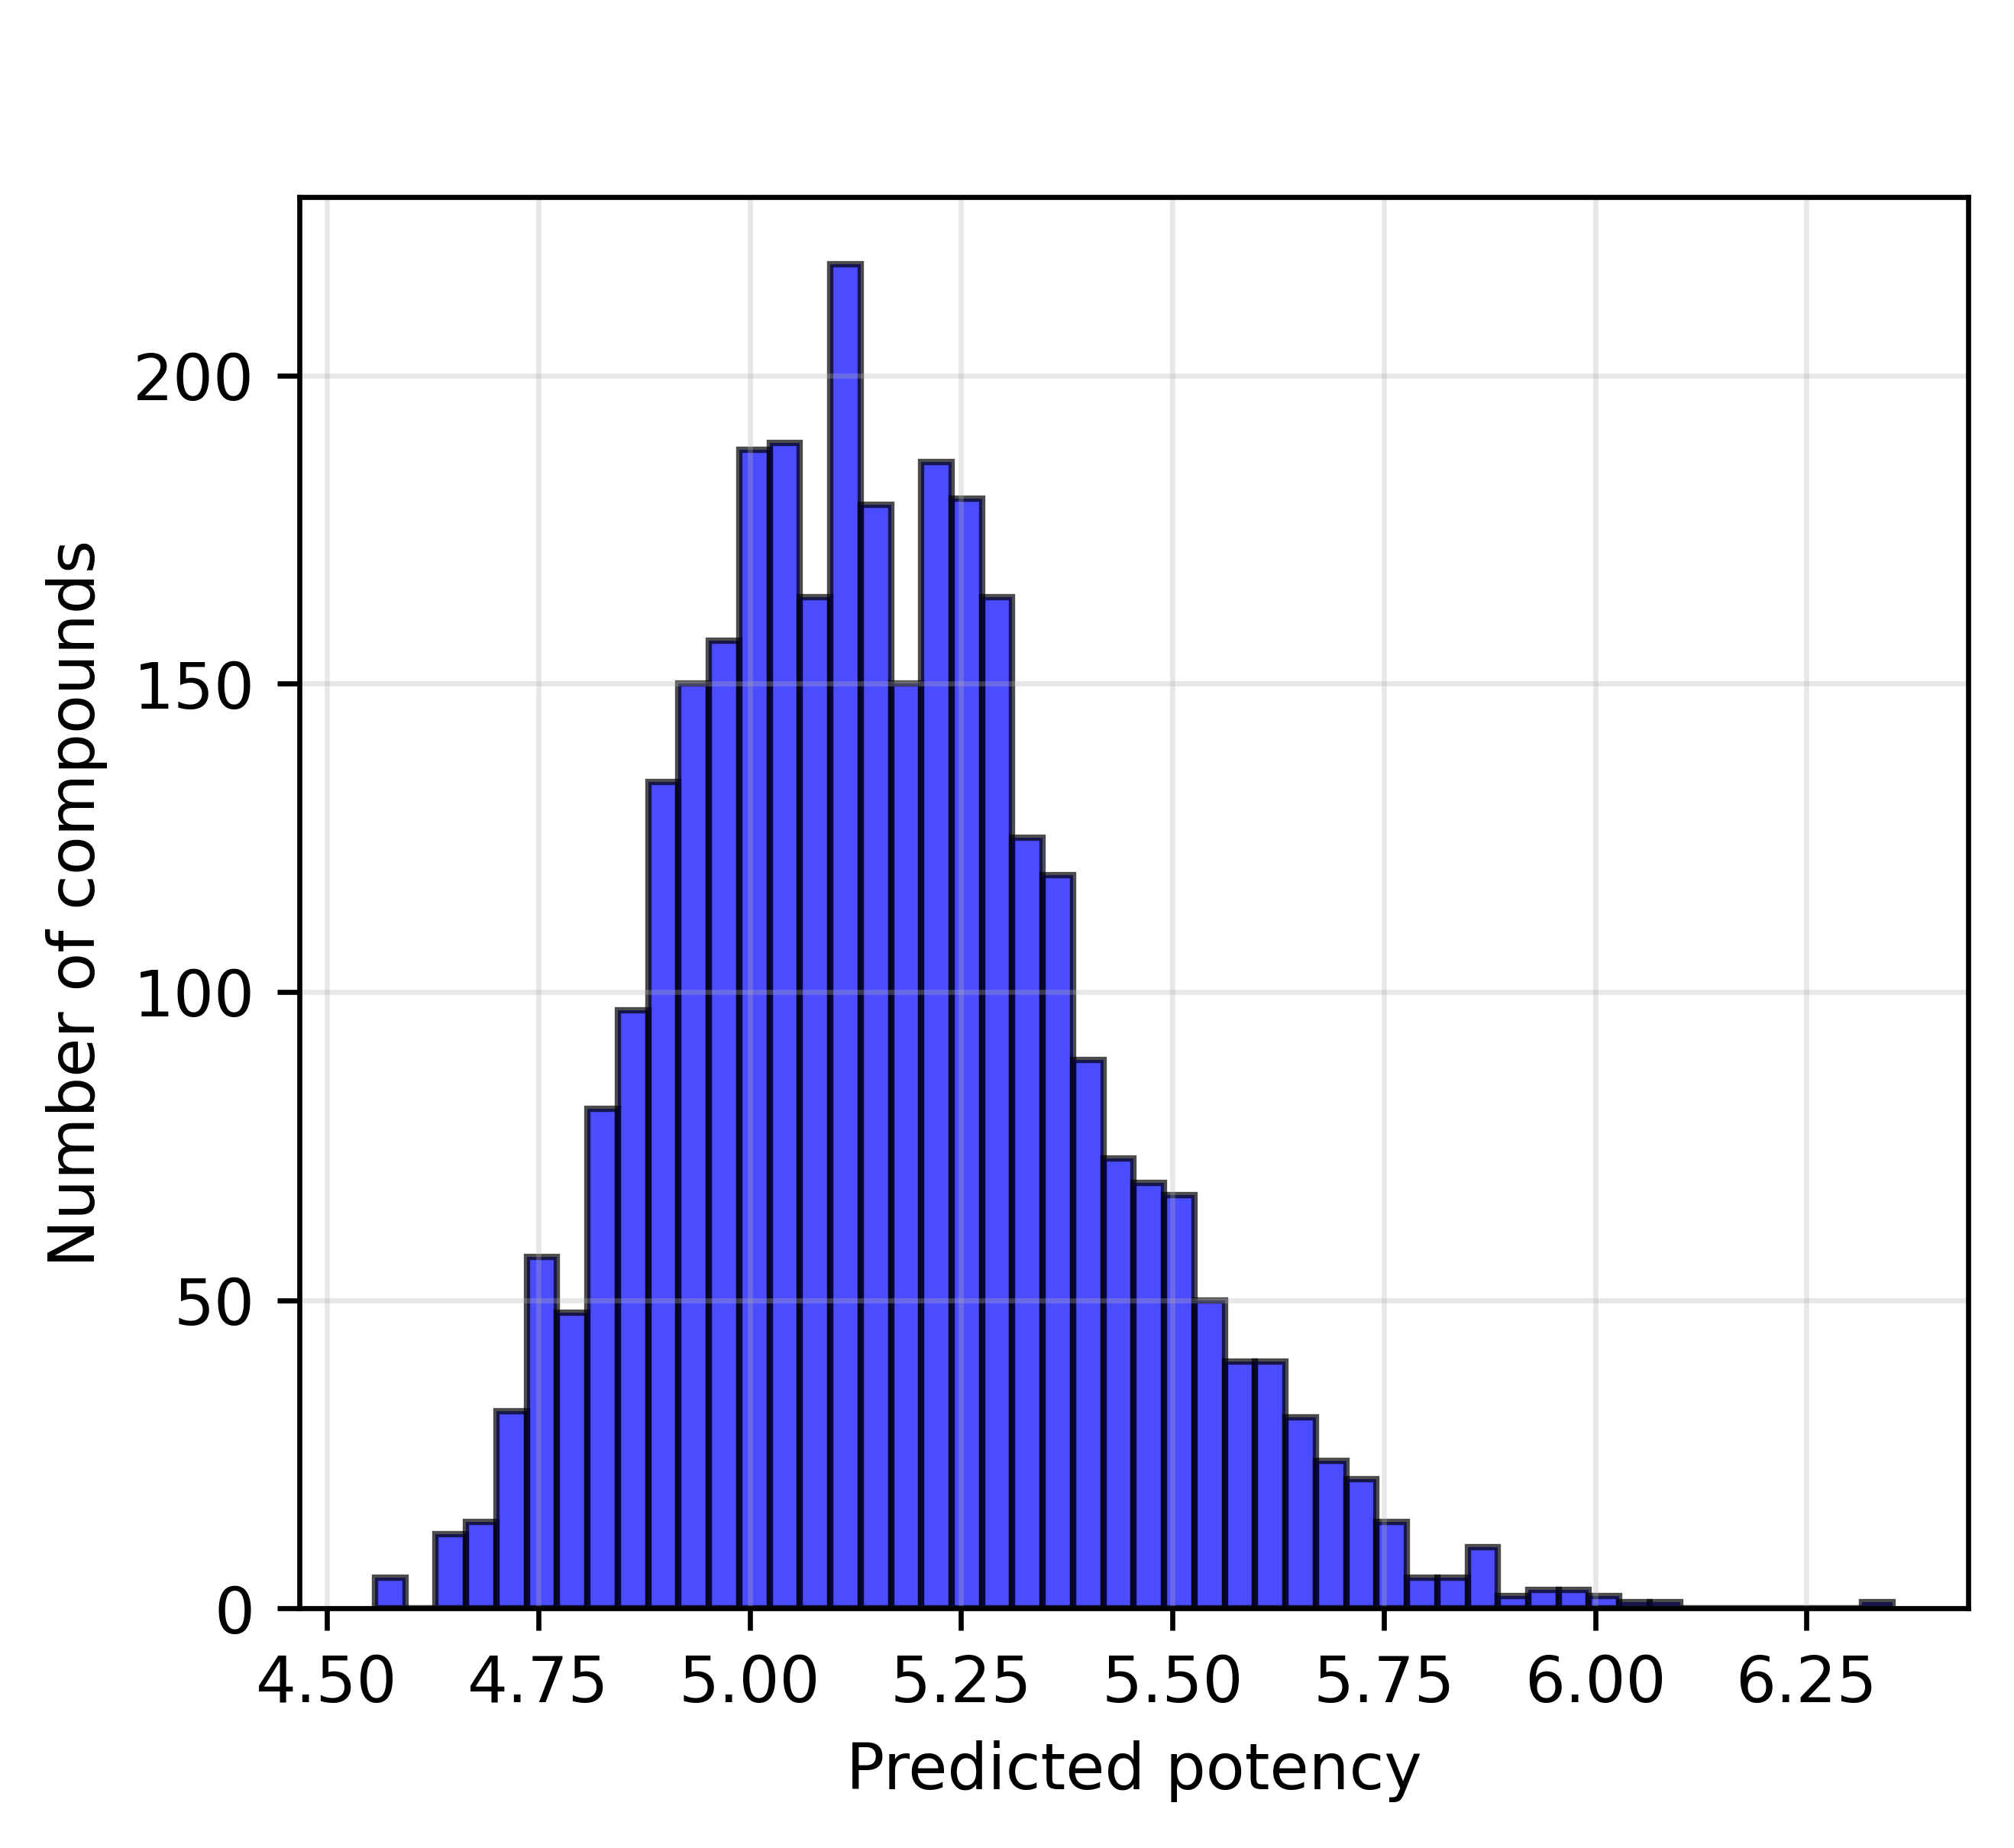

In [329]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + 'AllVirus_validation_wART.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + 'AllVirus_validation_wART.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [330]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7.0)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 0 compounds
Medium priority (6 ≤ pPotency < 7.0): 4 compounds
Low priority (5 ≤ pPotency < 6): 2346 compounds


In [331]:
EnamineAntiviralsData_final = EnamineAntiviralsData.iloc[idx].copy()
EnamineAntiviralsData_final['pPotency_prediction'] = Y1_lib_pred[idx]

EnamineAntiviralsData_final

,SMILES,Catalog ID,MW,MW (desalted),ClogP,logS,HBD,HBA,TPSA,RotBonds,AnalogsFromREAL,pPotency_prediction


### Find non toxic molecules using ADMET_ai

- `pip install --upgrade-strategy only-if-needed admet-ai --dry-run`
- `pip install --upgrade-strategy only-if-needed admet-ai`

### Top 20 compounds with higher PpPotency

In [332]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 5.86
Highest predicted pPotency: 6.35
Range of top 20: 5.86 - 6.35


In [333]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
EnamineAntiviralsData_top20 = EnamineAntiviralsData_predicted.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
EnamineAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
EnamineAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
EnamineAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
EnamineAntiviralsData_top20 = EnamineAntiviralsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (M)"]
)
EnamineAntiviralsData_top20

----------------------------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
----------------------------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    5.858
  IC50:        1.386e-06 M  (1386.44 nM)

Best Values (1st ranked compound):
  pPotency:    6.352
  IC50:        4.451e-07 M  (445.11 nM)
Range for Top 20 Compounds:
pPotency Range:  5.858 - 6.352

IC50 Range (M):  1.386e-06 - 4.451e-07


,Rank,SMILES,pPotency_prediction,pPotency_std,IC50 (M)
2632,1,CCC=1C=C(CC)N(N1)C2=NC3=C(C(=O)NC(=O)N3C)N2CCOC,6.352,0.674,4.451e-07
1456,2,[O-][N+](=O)C=1C=CC(=O)N(C1)CC(=O)NCC2CCCCC2O,6.095,0.674,8.033e-07
2111,3,O=C1C=C(N=CN1CC(O)COC=2C=CC=CC2)C3CCC3,6.039,0.674,9.149e-07
229,4,CCOCCN1C(=NC2=C1C(=O)NC(=O)N2C)N3N=C(C)C(C)=C3C,6.010,0.674,9.772e-07
3089,5,O=C(O)C(F)(F)C1=CNC(=O)NC1=O,5.998,0.675,1.004e-06
3087,6,CC1(NC(=O)NC1=O)C2=CC=CC=N2,5.981,0.674,1.045e-06
1528,7,COC=1C=CC=C(C1)C(O)CN2C=C(Cl)C(=O)NC2=O,5.980,0.674,1.047e-06
3006,8,CCOCCN1C(=NC2=C1C(=O)NC(=O)N2C)N3N=C(C)C=C3C,5.960,0.674,1.096e-06
724,9,CC1(NC(=O)NC1=O)C=2C=CN=CC2,5.947,0.675,1.129e-06
1917,10,CC1(NC(=O)NC1=O)C2=CN=CC=N2,5.940,0.674,1.148e-06


In [334]:
EnamineAntiviralsData_top20.to_csv(os.path.join(saveDir + "AllVirus_EnamineAntiviralsData_top20_wART.csv"), index=False)
EnamineAntiviralsData_top20[['SMILES']].to_csv(os.path.join(saveDir + "AllVirus_EnamineAntiviralsData_top20_SMILES_wART.csv"), index=False)

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/AllVirus/AllVirus_enamine_predictedCompounds_wART.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/AllVirus/AllVirus_enamine_predictedCompounds_wART.svg


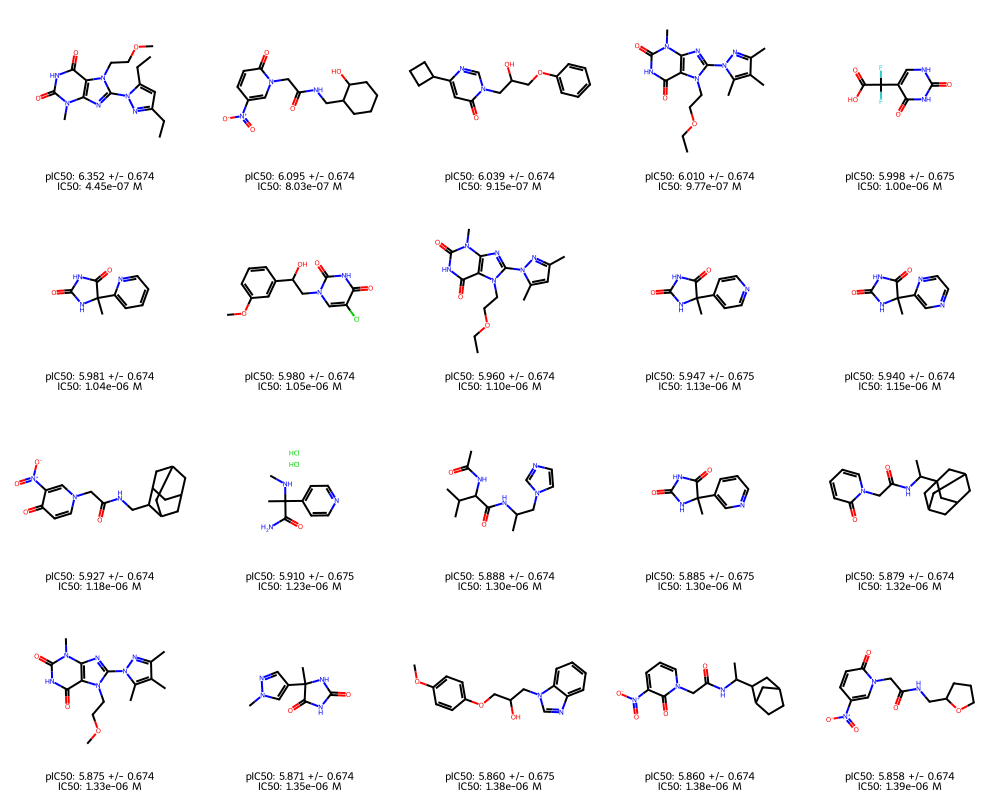

In [335]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image


# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntiviralsData_top20.SMILES[:50]]

# Create legends with standard deviation
legends = []
for idx, row in EnamineAntiviralsData_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + 'AllVirus_enamine_predictedCompounds_wART.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + 'AllVirus_enamine_predictedCompounds_wART.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

## 2.2 Discovery of new hits specific to all viruses (data source Life chemicals data set)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [537]:
# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "LifeChemicals/LC_Merged_Antiviral_Screening_Superset.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

LCAntiviralsData_superset = pd.DataFrame(records)
print(f"Original LifeChemicals data shape: {LCAntiviralsData_superset.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to LifeChemicals data (reusing canonical_train from code-1)
LCAntiviralsData_superset['Canonical_SMILES'] = LCAntiviralsData_superset['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~LCAntiviralsData_superset['Canonical_SMILES'].isin(canonical_train)
LCAntiviralsData_superset_filtered = LCAntiviralsData_superset[mask].copy()

# Remove the helper column if you don't need it
LCAntiviralsData_superset = LCAntiviralsData_superset_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered LifeChemicals data shape for validation: {LCAntiviralsData_superset.shape}")
print(f"Removed {LCAntiviralsData_superset_filtered.shape[0] - LCAntiviralsData_superset.shape[0]} duplicate compounds from LifeChemicals data set")

# Now use the filtered data
smi_lib_LCAntiviralsData = LCAntiviralsData_superset.SMILES
print(f"Total compounds to screen: {len(smi_lib_LCAntiviralsData)}")
LCAntiviralsData_superset.head()

Original LifeChemicals data shape: (45573, 17)
Number of unique SMILES in training set: 2483
Filtered LifeChemicals data shape for validation: (45564, 17)
Removed 0 duplicate compounds from LifeChemicals data set
Total compounds to screen: 45564


,IDNUMBER,Chemical_Name,CAS,PriceCoeff,MW,Description,FSP3,clogP,TPSA,Acceptor,Donor,RotBonds,HAC,Collection,Library,PPDS,SMILES
0,F6544-0534,"11-(oxan-4-yl)-7,11-diazatricyclo[7.3.1.0²,⁷]t...",2034607-75-3,1.500,274.360,solid,0.690,-0.120,32.780,2,1,1,20.000,Advanced,Anti-Hepatitis_A_B_ Screening_Library,,Cl.O=c1cccc2n1CC1CC2CN(C2CCOCC2)C1
1,F6559-5304,6-[4-(trifluoromethyl)pyrimidin-2-yl]-6-azaspi...,2034225-11-9,1.500,301.260,solid,0.620,2.030,66.320,4,1,2,21.000,Advanced,2019-nCoV_Main_Protease_Targeted_Library,+,O=C(O)C1CN(c2nccc(C(F)(F)F)n2)CC12CCC2
2,F6610-6619,"1-methyl-4-[(pyridin-4-yl)methyl]-1,4-diazepane",2320860-02-2,1.000,205.300,oil,0.580,0.890,19.370,3,3,2,15.000,General,Anti-HIV_Focused_Library,,CN1CCCN(Cc2ccncc2)CC1
3,F6559-5274,"6-(4,6-dimethylpyrimidin-2-yl)-6-azaspiro[3.4]...",2034225-08-4,1.500,261.320,oil,0.640,2.090,66.320,4,1,2,19.000,Advanced,Antiviral_Screening_Compound_Library_2D_Simila...,,Cc1cc(C)nc(N2CC(C(=O)O)C3(CCC3)C2)n1
4,F1912-1536,N-cyclopropyl-N-(piperidin-4-yl)pyrimidin-4-amine,1781768-10-2,1.500,218.290,solid,0.670,0.790,41.050,2,2,3,16.000,Advanced,Antiviral_Screening_Compound_Library_2D_Simila...,,c1cc(N(C2CCNCC2)C2CC2)ncn1


Generate predictions for the H1 receptor:

In [538]:
smi_lib_LCAntiviralsData_wMACAW = mcw.transform(smi_lib_LCAntiviralsData)

# Create column names
num_features = smi_lib_LCAntiviralsData_wMACAW.shape[1]
column_names = [f'MACAW_{i+1}' for i in range(num_features)]

# Create DataFrame with same index as smi_lib
SMILES_lib_LCAntiviralsData = pd.DataFrame(smi_lib_LCAntiviralsData_wMACAW, columns=column_names, index=smi_lib_LCAntiviralsData.index)
# Then add SMILES as first column
SMILES_lib_LCAntiviralsData.insert(0, 'SMILES', smi_lib_LCAntiviralsData)
# Save to CSV
SMILES_lib_LCAntiviralsData.to_csv(os.path.join(saveDir + "AllVirus_LCAntiviralsData_wMACAW.csv"), index=False)
SMILES_lib_LCAntiviralsData

,SMILES,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,MACAW_8,MACAW_9,...,MACAW_191,MACAW_192,MACAW_193,MACAW_194,MACAW_195,MACAW_196,MACAW_197,MACAW_198,MACAW_199,MACAW_200
0,Cl.O=c1cccc2n1CC1CC2CN(C2CCOCC2)C1,0.094,0.195,-0.036,0.047,0.065,-7.472e-03,-0.011,-0.041,0.046,...,-0.016,9.427e-04,-2.732e-03,-0.031,-8.771e-03,0.016,-0.013,1.705e-03,6.925e-03,0.014
1,O=C(O)C1CN(c2nccc(C(F)(F)F)n2)CC12CCC2,0.104,0.169,0.042,-9.927e-03,0.015,0.022,-0.090,-0.025,-0.013,...,-0.023,9.647e-03,-8.181e-03,0.039,-3.375e-03,3.002e-03,-0.042,0.017,-0.011,-4.898e-03
2,CN1CCCN(Cc2ccncc2)CC1,0.144,0.181,0.031,0.050,-0.017,-0.026,-0.040,-0.089,0.075,...,-7.376e-03,0.016,-1.817e-03,-7.692e-03,0.024,8.517e-03,-0.035,-0.016,-5.955e-03,8.793e-03
3,Cc1cc(C)nc(N2CC(C(=O)O)C3(CCC3)C2)n1,0.106,0.161,0.033,-0.021,-1.068e-03,-0.035,-0.056,-0.046,-9.464e-03,...,-0.026,-5.796e-03,5.269e-03,0.026,8.606e-03,0.023,-0.038,0.015,-0.022,5.615e-03
4,c1cc(N(C2CCNCC2)C2CC2)ncn1,0.107,0.172,0.026,-8.131e-04,0.038,-5.956e-03,-0.054,-0.060,0.065,...,-0.012,1.750e-03,-5.001e-03,8.685e-03,-0.020,-8.261e-03,-0.026,9.300e-03,-4.251e-03,-0.011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45568,CCN1C=C/C(=C\C=C\c2cc[n+](CC)c3ccccc23)c2ccccc...,0.190,-0.064,-0.016,0.054,-0.046,-0.037,0.022,-0.068,0.038,...,-6.762e-03,0.028,9.041e-04,-8.608e-03,4.787e-03,0.013,2.509e-03,0.019,-0.019,-9.988e-04
45569,CCCN1/C(=C/C=C/c2sc3ccccc3[n+]2CCC)Sc2ccccc21....,0.125,7.490e-03,-0.017,0.074,-0.046,-0.019,0.031,-0.048,0.027,...,-0.017,-6.387e-03,-0.024,0.018,-0.017,-9.331e-03,-0.010,-8.750e-03,-0.025,-8.960e-03
45570,COC(=O)c1ccccc1-c1c2ccc(=N)cc-2oc2cc(N)ccc12.Cl,0.192,-0.029,0.057,-0.078,-0.080,0.068,0.107,-5.720e-03,-0.031,...,-0.018,-0.053,-0.030,6.182e-03,0.012,0.020,7.316e-04,9.244e-03,3.059e-03,-7.644e-03
45571,CCN1/C(=C/C=C2\CCC(/C=C/c3sc4ccc(Cl)cc4[n+]3CC...,-2.187e-03,-0.102,0.033,0.111,-0.018,-9.609e-03,-6.981e-04,-0.065,-0.017,...,-0.028,0.013,-0.019,-0.013,0.011,0.021,-0.014,0.029,-9.286e-03,-8.794e-03


In [ ]:
LCAntiviralsData_predicted = pd.read_csv(saveDir + 'AllVirus_wART_LCAntiviralsData_predicted_all.csv')
max_val = LCAntiviralsData_predicted['pPotency_prediction'].max()
min_val = LCAntiviralsData_predicted['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
LCAntiviralsData_predicted

Let us represent the predictions of both models:

In [ ]:
Y1_lib_pred = LCAntiviralsData_predicted['pPotency_prediction'].values

In [ ]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + 'AllVirus_validation_LCDatasets_wART.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + 'AllVirus_validation_LCDatasets_wART.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [ ]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7.0)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

### Top 20 compounds with higher PpPotency

In [ ]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

In [ ]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
LCAntiviralsData_top20 = LCAntiviralsData_predicted.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
LCAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
LCAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
LCAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
LCAntiviralsData_top20 = LCAntiviralsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (M)"]
)
LCAntiviralsData_top20

In [ ]:
LCAntiviralsData_top20.to_csv(os.path.join(saveDir + "AllVirus_LCAntiviralsData_top20_wART.csv"), index=False)
LCAntiviralsData_top20[['SMILES']].to_csv(os.path.join(saveDir + "AllVirus_LCAntiviralsData_top20_SMILES_wART.csv"), index=False)

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image


# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in LCAntiviralsData_top20.SMILES[:50]]

# Create legends with standard deviation
legends = []
for idx, row in LCAntiviralsData_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + 'AllVirus_predictedCompounds_LCDataset_wART.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + 'AllVirus_predictedCompounds_LCDataset_wART.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

# 2.3 Discovery of new hits specific to all viruses (data source chemDiv data set)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models regr above, which use 15-D MACAW embeddings as their input. The custom library compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [539]:
# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "ChemDiv/ChemDiv_Antiviral-Library-64958.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

ChemDivAntiviralsData = pd.DataFrame(records)
print(f"Original ChemDiv data shape: {ChemDivAntiviralsData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to ChemDiv data (reusing canonical_train from previous code)
ChemDivAntiviralsData['Canonical_SMILES'] = ChemDivAntiviralsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~ChemDivAntiviralsData['Canonical_SMILES'].isin(canonical_train)
ChemDivAntiviralsData_filtered = ChemDivAntiviralsData[mask].copy()

# Remove the helper column if you don't need it
ChemDivAntiviralsData = ChemDivAntiviralsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered ChemDiv data shape for validation: {ChemDivAntiviralsData.shape}")
print(f"Removed {ChemDivAntiviralsData_filtered.shape[0] - ChemDivAntiviralsData.shape[0]} duplicate compounds from ChemDiv data set")

# Now use the filtered data
smi_lib_ChemDivAntiviralsData = ChemDivAntiviralsData.SMILES
print(f"Total compounds to screen: {len(smi_lib_ChemDivAntiviralsData)}")
ChemDivAntiviralsData

Original ChemDiv data shape: (64958, 28)
Number of unique SMILES in training set: 2483
Filtered ChemDiv data shape for validation: (64955, 28)
Removed 0 duplicate compounds from ChemDiv data set
Total compounds to screen: 64955


,IDNUMBER,available,H_acceptor,H_donor,B_rotN,N_O,logP,logD,logSw,PSA,...,InChI Key,PERCENTSP3,Link,CLNUMBER,Saltdata,Saltdata_MW,STEREO,State,SMILES,CAS
0,E676-1193,55,6,0,10,6.000,4.584,3.825,-4.736,44.193,...,CADSCKHSUSMLDE-UHFFFAOYSA-N,33.300,https://www.chemdiv.com/catalog/screening-comp...,CL4971B,HCl,36.461,ACHIRAL,Solid,CCOc1cccc2sc(N(CCN(C)C)C(=O)COc3ccc(Cl)cc3)nc12,NaN
1,E676-4289,2,8,0,9,7.000,2.084,1.279,-2.867,59.381,...,GBCBRISSOXAFMF-UHFFFAOYSA-N,47.400,https://www.chemdiv.com/catalog/screening-comp...,CL4971B,HCl,36.461,ACHIRAL,Solid,CCN(CC)CCN(C(=O)CN1C(=O)CCC1=O)c1nc2c(Cl)cccc2s1,NaN
2,E676-2516,15,7,0,7,7.000,4.274,3.444,-4.355,53.078,...,LSLRIDUYGBBIBR-SFHVURJKSA-N,36.400,https://www.chemdiv.com/catalog/screening-comp...,CL4971B,HCl,36.461,RACEMIC MIXTURE,Solid,COc1ccc(C)c2sc(N(CCN(C)C)C(=O)C3COc4ccccc4O3)nc12,NaN
3,F735-0482,21,7,2,9,7.000,3.231,3.225,-3.423,79.491,...,NBFDETMKPOQYSJ-UHFFFAOYSA-N,22.200,https://www.chemdiv.com/catalog/screening-comp...,CL8286,NaN,NaN,ACHIRAL,Solid,CCCc1nnc(C(=O)Nc2ccc(C(=O)NCc3ccco3)cc2)s1,NaN
4,G211-0195,304,5,1,5,5.000,5.054,5.054,-5.469,49.877,...,DRPXIGZHBISZAU-UHFFFAOYSA-N,32.000,https://www.chemdiv.com/catalog/screening-comp...,CL6036,NaN,NaN,ACHIRAL,Solid,O=C(NCc1cccc(Cl)c1)c1c2c(nc3ccccc13)C(=O)N(C1C...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64953,8010-2606,54,8,1,9,8.000,6.685,3.100,-6.678,70.818,...,ZQXAXHNEVALOJP-UHFFFAOYSA-N,30.800,https://www.chemdiv.com/catalog/screening-comp...,CL1650,NaN,NaN,ACHIRAL,Solid,CCOC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(OC...,NaN
64954,2774-1508,1,7,1,8,7.000,6.551,3.884,-5.738,62.323,...,KDXCUTJRVPCZKK-UHFFFAOYSA-N,25.000,https://www.chemdiv.com/catalog/screening-comp...,CL1652,NaN,NaN,ACHIRAL,Solid,CCOC(=O)c1c(NC(=O)c2cc3nc(-c4ccc(Br)cc4)cc(C(F...,NaN
64955,K061-0539,124,7,1,7,7.000,6.014,2.429,-5.464,64.713,...,XEIANUQFWJNADZ-UHFFFAOYSA-N,27.300,https://www.chemdiv.com/catalog/screening-comp...,CL1647,NaN,NaN,ACHIRAL,Solid,COC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4cccs4)n...,NaN
64956,K061-0894,165,6,1,7,7.000,6.905,6.387,-6.761,57.369,...,IBXAKUXFQPUZBE-UHFFFAOYSA-N,13.600,https://www.chemdiv.com/catalog/screening-comp...,CL1650,NaN,NaN,ACHIRAL,Solid,COc1cc(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(Br)cc4)...,NaN


In [540]:
smi_lib_ChemDivAntiviralsData_wMACAW = mcw.transform(smi_lib_ChemDivAntiviralsData)

# Create column names
num_features = smi_lib_ChemDivAntiviralsData_wMACAW.shape[1]
column_names = [f'MACAW_{i+1}' for i in range(num_features)]

# Create DataFrame with same index as smi_lib
SMILES_lib_ChemDivAntiviralsData = pd.DataFrame(smi_lib_ChemDivAntiviralsData_wMACAW, columns=column_names, index=smi_lib_ChemDivAntiviralsData.index)
# Then add SMILES as first column
SMILES_lib_ChemDivAntiviralsData.insert(0, 'SMILES', smi_lib_ChemDivAntiviralsData)
# Save to CSV
SMILES_lib_ChemDivAntiviralsData.to_csv(os.path.join(saveDir + "AllVirus_ChemDivAntiviralsData_wMACAW.csv"), index=False)
SMILES_lib_ChemDivAntiviralsData

50000


,SMILES,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,MACAW_8,MACAW_9,...,MACAW_191,MACAW_192,MACAW_193,MACAW_194,MACAW_195,MACAW_196,MACAW_197,MACAW_198,MACAW_199,MACAW_200
0,CCOc1cccc2sc(N(CCN(C)C)C(=O)COc3ccc(Cl)cc3)nc12,0.092,-0.034,-0.036,0.070,-0.028,-0.072,0.025,-0.039,-0.067,...,-2.333e-03,0.021,-6.312e-04,0.032,7.781e-04,-9.608e-03,-0.026,-5.024e-03,-8.942e-03,-3.111e-03
1,CCN(CC)CCN(C(=O)CN1C(=O)CCC1=O)c1nc2c(Cl)cccc2s1,0.055,0.079,-0.031,0.094,-0.047,-0.022,-0.081,-6.683e-03,-0.044,...,6.048e-03,0.018,-2.210e-03,0.026,4.640e-03,6.618e-03,-3.728e-03,1.285e-03,-3.030e-03,-2.927e-03
2,COc1ccc(C)c2sc(N(CCN(C)C)C(=O)C3COc4ccccc4O3)nc12,0.072,-0.036,-0.045,0.040,-0.019,-0.117,0.083,-0.047,-0.055,...,0.018,0.026,0.020,-3.000e-03,-0.010,1.870e-03,-0.010,-4.946e-03,-7.273e-03,-3.875e-03
3,CCCc1nnc(C(=O)Nc2ccc(C(=O)NCc3ccco3)cc2)s1,0.107,-0.067,-0.042,0.014,-0.020,0.013,-0.028,0.047,-0.059,...,1.709e-03,0.016,-0.024,0.023,0.012,6.015e-03,0.024,-6.093e-03,0.018,0.012
4,O=C(NCc1cccc(Cl)c1)c1c2c(nc3ccccc13)C(=O)N(C1C...,0.079,-0.032,-0.103,0.140,0.050,0.036,-0.064,0.011,-0.045,...,2.918e-03,-2.353e-03,-0.030,-0.010,0.019,-0.018,-2.003e-03,-0.029,1.026e-03,-0.016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64953,CCOC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(OC...,-0.012,-0.075,0.037,0.058,-0.020,-0.040,-0.061,0.049,-0.096,...,0.024,9.420e-04,0.019,0.020,-0.020,0.014,2.499e-03,0.013,-3.730e-04,0.019
64954,CCOC(=O)c1c(NC(=O)c2cc3nc(-c4ccc(Br)cc4)cc(C(F...,0.016,-0.079,0.024,0.062,2.358e-03,-0.018,-0.076,0.050,-0.107,...,0.012,0.015,0.025,0.019,-0.030,-6.674e-03,3.786e-03,6.833e-03,4.167e-03,0.015
64955,COC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4cccs4)n...,0.014,-0.042,0.032,0.046,-0.015,-0.029,-0.068,0.063,-0.106,...,0.016,0.015,0.017,8.958e-03,-0.014,5.634e-03,0.022,-1.098e-03,3.962e-03,0.027
64956,COc1cc(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(Br)cc4)...,0.047,-0.124,0.051,-0.034,-0.040,-0.079,-0.052,-3.819e-03,-0.104,...,0.016,0.020,0.029,9.518e-03,-0.016,-1.867e-03,-0.012,7.588e-03,0.028,0.013


In [ ]:
ChemDivAntiviralsData_predicted = pd.read_csv(saveDir + 'AllVirus_wART_ChemDivAntiviralsData_predicted_all.csv')
max_val = ChemDivAntiviralsData_predicted['pPotency_prediction'].max()
min_val = ChemDivAntiviralsData_predicted['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
ChemDivAntiviralsData_predicted

In [ ]:
Y1_lib_pred = ChemDivAntiviralsData_predicted['pPotency_prediction'].values

In [ ]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + 'AllVirus_ChemDivDatasets.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + 'AllVirus_ChemDivDatasets.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [ ]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7.0)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

### Top 20 compounds with higher pPotency

In [ ]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

In [ ]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
ChemDivAntiviralsData_top20 = ChemDivAntiviralsData_predicted.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
ChemDivAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
ChemDivAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
ChemDivAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
ChemDivAntiviralsData_top20 = ChemDivAntiviralsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (M)"]
)

ChemDivAntiviralsData_top20

In [ ]:
ChemDivAntiviralsData_top20.to_csv(os.path.join(saveDir + "AllVirus_ChemDivAntiviralsData_top20_wART.csv"), index=False)
ChemDivAntiviralsData_top20[['SMILES']].to_csv(os.path.join(saveDir + "AllVirus_ChemDivAntiviralsData_top20_SMILES_wART.csv"), index=False)

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image


# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in ChemDivAntiviralsData_top20.SMILES[:50]]

# Create legends with standard deviation
legends = []
for idx, row in ChemDivAntiviralsData_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + 'AllVirus_predictedCompounds_SMACCDataset_wART.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + 'AllVirus_predictedCompounds_SMACCDataset_wART.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

### 2.4 Discovery of new hits specific to all viruses (data source SMACC Antivirals data set)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models regr above, which use 15-D MACAW embeddings as their input. In particular, we are interested in molecules with high predicted pPotency.

In [541]:
SMACCAntiviralsData = pd.read_csv(modelBuildingDataDir + "SMACCAntiviralsData_clean.csv")

# Check for duplicates
dup_check = SMACCAntiviralsData.groupby('SMILES')['pIC50'].agg(['count', 'median', 'std'])
duplicates = dup_check[dup_check['count'] > 1]
print(f"Original SMACC data shape: {SMACCAntiviralsData.shape}, with Duplicate SMILES: {len(duplicates)}")

# Take median pIC50 for duplicates
SMACCAntiviralsData = SMACCAntiviralsData.groupby('SMILES').agg({
    'Molecule ChEMBL ID': 'first',
    'pIC50': 'median',  # Use median instead of mean
    'Virus': 'first'
}).reset_index()

print(f"After removing internal duplicates: {SMACCAntiviralsData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")
# Add canonical SMILES column to SMACC data (reusing canonical_train from previous code)
SMACCAntiviralsData['Canonical_SMILES'] = SMACCAntiviralsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~SMACCAntiviralsData['Canonical_SMILES'].isin(canonical_train)
SMACCAntiviralsData_filtered = SMACCAntiviralsData[mask].copy()

# Remove the helper column if you don't need it
SMACCAntiviralsData = SMACCAntiviralsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered SMACC data shape for validation: {SMACCAntiviralsData.shape}")
print(f"Removed {SMACCAntiviralsData_filtered.shape[0] - SMACCAntiviralsData.shape[0]} duplicate compounds from SMACC data set")
SMACCAntiviralsData = SMACCAntiviralsData.rename(columns={'pIC50': 'pIC50_experimental'})

smi_lib_SMACCAntiviralsData = SMACCAntiviralsData.SMILES
print(f"Total compounds to screen: {len(smi_lib_SMACCAntiviralsData)}")
SMACCAntiviralsData.head()

Original SMACC data shape: (1923, 5), with Duplicate SMILES: 197
After removing internal duplicates: (1612, 4)
Number of unique SMILES in training set: 2483
Filtered SMACC data shape for validation: (1602, 4)
Removed 0 duplicate compounds from SMACC data set
Total compounds to screen: 1602


,SMILES,Molecule ChEMBL ID,pIC50_experimental,Virus
0,Brc1ccc(NC(=O)CC2Sc3ncnn3C2=O)cc1,CHEMBL243652,5.690,SARS-CoV-2
1,Brc1ccc(Oc2ccc3NS(=O)(=O)C=C(OC(=O)c4ccccc4)c3...,CHEMBL4284511,5.328,Dengue
2,Brc1ccc(cc1)C1C2=C(NC(=S)NC2=O)OC2=C1C(=O)NC(=...,CHEMBL1402117,4.132,Dengue
3,Brc1ccc2C(=O)C(=O)C=Cc2c1,CHEMBL4303595,7.097,SARS-CoV-2
4,Brc1ccc2NC(=O)C(=C3SC(=S)N(NS(=O)(=O)c4ccccc4)...,CHEMBL1361582,4.627,Dengue


Generate predictions

In [542]:
smi_lib_SMACCAntiviralsData_wMACAW = mcw.transform(smi_lib_SMACCAntiviralsData)

# Create column names
num_features = smi_lib_SMACCAntiviralsData_wMACAW.shape[1]
column_names = [f'MACAW_{i+1}' for i in range(num_features)]

# Create DataFrame with same index as smi_lib
SMILES_lib_SMACCAntiviralsData = pd.DataFrame(smi_lib_SMACCAntiviralsData_wMACAW, columns=column_names, index=smi_lib_SMACCAntiviralsData.index)
# Then add SMILES as first column
SMILES_lib_SMACCAntiviralsData.insert(0, 'SMILES', smi_lib_SMACCAntiviralsData)
# Save to CSV
SMILES_lib_SMACCAntiviralsData.to_csv(os.path.join(saveDir + "AllVirus_SMACCAntiviralsData_wMACAW.csv"), index=False)
SMILES_lib_SMACCAntiviralsData

,SMILES,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,MACAW_8,MACAW_9,...,MACAW_191,MACAW_192,MACAW_193,MACAW_194,MACAW_195,MACAW_196,MACAW_197,MACAW_198,MACAW_199,MACAW_200
0,Brc1ccc(NC(=O)CC2Sc3ncnn3C2=O)cc1,0.145,0.014,9.807e-03,-0.082,6.390e-03,0.058,-0.037,-0.039,-0.012,...,3.302e-04,-0.015,-3.467e-03,-5.658e-03,-6.430e-03,0.022,1.693e-04,-0.012,-0.025,-0.023
1,Brc1ccc(Oc2ccc3NS(=O)(=O)C=C(OC(=O)c4ccccc4)c3...,0.148,-0.102,1.743e-03,-0.016,6.987e-03,0.098,0.042,-0.074,-0.054,...,6.412e-03,-1.096e-03,0.016,0.015,2.979e-03,1.141e-04,-6.618e-03,2.765e-04,7.882e-03,-0.022
2,Brc1ccc(cc1)C1C2=C(NC(=S)NC2=O)OC2=C1C(=O)NC(=...,0.137,8.676e-03,0.044,-0.049,-0.035,0.068,-5.517e-03,-0.018,-0.039,...,-0.016,-7.963e-03,-0.012,5.505e-03,1.836e-03,-0.014,-0.029,-0.011,3.157e-03,9.200e-03
3,Brc1ccc2C(=O)C(=O)C=Cc2c1,0.194,0.103,0.075,-0.069,-0.062,0.148,0.017,-0.016,0.048,...,0.015,0.022,0.022,-2.828e-03,-0.021,3.687e-04,0.014,5.899e-03,-0.014,0.013
4,Brc1ccc2NC(=O)C(=C3SC(=S)N(NS(=O)(=O)c4ccccc4)...,0.103,-0.076,-0.012,-0.022,-0.031,0.105,-0.043,-0.089,-0.066,...,7.425e-03,0.016,7.927e-03,-2.343e-03,-0.021,5.371e-03,-0.027,-7.575e-03,0.021,-4.918e-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1607,S=C1NN=C(Nc2ccccc2)S1,0.174,0.064,0.084,-0.093,-0.013,0.043,-0.032,-4.456e-03,0.046,...,7.759e-03,-0.016,9.722e-03,2.193e-03,4.327e-03,-0.014,-0.022,-0.016,6.470e-05,-8.253e-03
1608,S=C1Nc2ccccc2S1,0.164,0.096,0.084,-0.079,-0.011,0.059,-0.020,-0.023,0.059,...,0.011,-0.012,-1.294e-04,5.422e-03,-6.052e-03,-4.300e-03,-0.022,-0.022,-8.730e-03,5.582e-03
1609,SC(=S)N1CCCC1,0.091,0.147,0.065,-0.042,-0.023,0.028,-0.011,-0.067,6.484e-03,...,-0.014,4.145e-03,0.010,0.012,1.264e-03,-0.011,-0.015,-9.369e-03,-0.024,5.593e-03
1610,c1coc(c1)-c1nc2ccccc2nc1-c1ccco1,0.224,0.030,0.087,-0.068,-0.059,0.087,-0.010,8.541e-03,0.067,...,0.012,-0.036,7.606e-03,7.477e-03,0.012,7.987e-03,2.034e-04,3.731e-04,-8.279e-03,1.067e-03


In [ ]:
SMACCAntiviralsData_predicted = pd.read_csv(saveDir + 'AllVirus_wART_SMACCAntiviralsData_predicted_all.csv')
max_val = SMACCAntiviralsData_predicted['pPotency_prediction'].max()
min_val = SMACCAntiviralsData_predicted['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
SMACCAntiviralsData_predicted

In [ ]:
def canonicalize(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return Chem.MolToSmiles(mol, canonical=True) if mol else None

# Add canonical SMILES column to both dataframes
SMACCAntiviralsData_predicted['can_smiles'] = (
    SMACCAntiviralsData_predicted['SMILES'].apply(canonicalize)
)

SMACCAntiviralsData['can_smiles'] = (
    SMACCAntiviralsData['SMILES'].apply(canonicalize)
)

SMACCAntiviralsData_predicted_wExpt = pd.merge(
    SMACCAntiviralsData_predicted,
    SMACCAntiviralsData[['can_smiles', 'Molecule ChEMBL ID', 'pIC50_experimental', 'Virus']],
    on='can_smiles',
    how='inner'   # only keep rows where SMILES match
)

# Move Molecule ChEMBL ID to the last column
cols = [col for col in SMACCAntiviralsData_predicted_wExpt.columns if col != 'Molecule ChEMBL ID'] + ['Molecule ChEMBL ID']
SMACCAntiviralsData_predicted_wExpt = SMACCAntiviralsData_predicted_wExpt[cols]

# If you do not want the canonical column anymore
SMACCAntiviralsData_predicted_wExpt = SMACCAntiviralsData_predicted_wExpt.drop(columns=['can_smiles'])
new_order = ['SMILES', 'Virus', 'pIC50_experimental', 'pPotency_prediction', 'pPotency_std', 'pPotency_lower_95CI',
       'pPotency_upper_95CI', 'IC50(M)_prediction', 'IC50(M)_lower_95CI',
       'IC50(M)_upper_95CI', 'Molecule ChEMBL ID']
SMACCAntiviralsData_predicted_wExpt = SMACCAntiviralsData_predicted_wExpt[new_order]
SMACCAntiviralsData_predicted_wExpt

### Plot the error between `experimental_pPotency` and `predicted_pPotency`

In [ ]:
# ---------------------------------------
# 1. Compute residuals
# ---------------------------------------
SMACCAntiviralsData_predicted_wExpt['residuals'] = (
    SMACCAntiviralsData_predicted_wExpt['pPotency_prediction'] -
    SMACCAntiviralsData_predicted_wExpt['pIC50_experimental']
)

# ---------------------------------------
# 2. Print core statistics
# ---------------------------------------
res = SMACCAntiviralsData_predicted_wExpt['residuals']

print(f"Mean Residual: {res.mean():.3f}")
print(f"Std Dev of Residuals: {res.std():.3f}")
print(f"Min Residual: {res.min():.3f}")
print(f"Max Residual: {res.max():.3f}")

# ---------------------------------------
# 3. Create the two-panel residual plot
# ---------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Plot 1: Residuals vs Experimental pIC50 ----
axes[0].scatter(
    SMACCAntiviralsData_predicted_wExpt['pIC50_experimental'],
    res,
    alpha=0.6,
    s=50,
    edgecolors='black',
    linewidth=0.5
)

axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[0].set_xlabel('Experimental pIC50', fontsize=12)
axes[0].set_ylabel('Residuals (Predicted - Experimental)', fontsize=12)
axes[0].set_title('Residual Plot', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ---- Plot 2: Distribution of residuals ----
axes[1].hist(res, bins=30, edgecolor='black', alpha=0.7)

axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[1].axvline(
    x=res.mean(),
    color='blue',
    linestyle='--',
    linewidth=2,
    label=f'Mean: {res.mean():.3f}'
)

axes[1].set_xlabel('Residuals (Predicted - Experimental)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Residuals', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Plotting R2, MAE and RMSE

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Extract
x = SMACCAntiviralsData_predicted_wExpt['pIC50_experimental'].values
y = SMACCAntiviralsData_predicted_wExpt['pPotency_prediction'].values

# Metrics
r2 = r2_score(x, y)
mae = mean_absolute_error(x, y)
mse = mean_squared_error(x, y)
rmse = mse ** 0.5


# Plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.4, color='blue', marker='o', s=50, 
           edgecolors='blue', linewidth=0.8)
plt.plot([min(x), max(x)], [min(x), max(x)], 'k--', linewidth=1.2)

plt.xlabel("Experimental pIC50")
plt.ylabel("Predicted pIC50")
plt.title("Experimental vs Predicted Potency")

# Metrics box
textstr = f"R² = {r2:.2f}\nMAE = {mae:.2f}\nRMSE = {rmse:.2f}"
plt.gca().text(
    0.05, 0.95, textstr, transform=plt.gca().transAxes,
    fontsize=10, verticalalignment='top',
    
)

plt.tight_layout()
plt.show()

Let us have a look at the compounds:

In [ ]:
Y1_lib_pred = SMACCAntiviralsData_predicted['pPotency_prediction'].values

In [ ]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + 'AllVirus_validation_noDuplicates_SMACCDatasets_wART.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + 'AllVirus_validation_noDuplicates_SMACCDatasets_wART.png', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

### Top 20 compounds with higher pPotency

In [ ]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

In [ ]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
SMACCAntiviralsData_top20 = SMACCAntiviralsData_predicted.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
SMACCAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
SMACCAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
SMACCAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
SMACCAntiviralsData_top20 = SMACCAntiviralsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (M)"]
)
SMACCAntiviralsData_top20

In [ ]:
SMACCAntiviralsData_top20.to_csv(os.path.join(saveDir + "AllVirus_SMACCAntiviralsData_top20.csv"), index=False)
SMACCAntiviralsData_top20[['SMILES']].to_csv(os.path.join(saveDir + "AllVirus_SMACCAntiviralsData_top20_SMILES.csv"), index=False)

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image


# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in SMACCAntiviralsData_top20.SMILES[:50]]

# Create legends with standard deviation
legends = []
for idx, row in SMACCAntiviralsData_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + 'AllVirus_enamine_predictedCompounds_wART.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + 'AllVirus_enamine_predictedCompounds_wART.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

### 2.5 Checking drug likeliness of `Remdesivir` and `Molnupiravir`

In [543]:
Remdesivir_SMILES_file = os.path.join(dataDir + "/target_SMILES/Remdesivir_structure.mol")
Molnupiravir_SMILES_file = os.path.join(dataDir + "/target_SMILES/Molnupiravir_structure.mol")

In [544]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
import pandas as pd

# SMILES strings
Remdesivir_SMILES = 'CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](C#N)([C@H](O)[C@@H]1O)C1=CC=C2N1N=CN=C2N)OC1=CC=CC=C1'
Molnupiravir_SMILES = 'CC(C)C(=O)OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=C\C(NC1=O)=N\O'

# Dictionary of drugs and their SMILES
drugs = {
    'Remdesivir': Remdesivir_SMILES,
    'Molnupiravir': Molnupiravir_SMILES
}

# List to store results
smiles_data = []

# Process each drug
for drug_name, smiles in drugs.items():
    # Convert SMILES to molecule object
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is not None:
        smiles_data.append({
            'Drug_Name': drug_name,
            'SMILES': smiles,
            'Molecular_Formula': rdMolDescriptors.CalcMolFormula(mol),
            'Molecular_Weight': round(Descriptors.MolWt(mol), 2)
        })
        print(f" {drug_name}")
        print(f"  Formula: {rdMolDescriptors.CalcMolFormula(mol)}")
        print(f"  MW: {round(Descriptors.MolWt(mol), 2)} g/mol")
    else:
        print(f" Failed to parse SMILES for {drug_name}")

# Create DataFrame
DTRA_target_SMILES = pd.DataFrame(smiles_data)
smi_lib_DTRA_targets = DTRA_target_SMILES.SMILES
print(f"Total DTRA target compounds to screen: {len(smi_lib_DTRA_targets)}")
DTRA_target_SMILES

 Remdesivir
  Formula: C27H35N6O8P
  MW: 602.59 g/mol
 Molnupiravir
  Formula: C13H19N3O7
  MW: 329.31 g/mol
Total DTRA target compounds to screen: 2


,Drug_Name,SMILES,Molecular_Formula,Molecular_Weight
0,Remdesivir,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](...,C27H35N6O8P,602.590
1,Molnupiravir,CC(C)C(=O)OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=...,C13H19N3O7,329.310


Generate predictions

In [545]:
smi_lib = smi_lib_DTRA_targets.copy()
smi_lib_DTRA_targets_wMACAW = mcw.transform(smi_lib_DTRA_targets)

# Create column names
num_features = smi_lib_DTRA_targets_wMACAW.shape[1]
column_names = [f'MACAW_{i+1}' for i in range(num_features)]

# Create DataFrame with same index as smi_lib
smi_lib_DTRA_targets = pd.DataFrame(smi_lib_DTRA_targets_wMACAW, columns=column_names, index=smi_lib.index)
# Then add SMILES as first column
smi_lib_DTRA_targets.insert(0, 'SMILES', smi_lib)
# Save to CSV
smi_lib_DTRA_targets.to_csv(os.path.join(saveDir + "AllVirus_DTRA_smiles_wMACAW.csv"), index=False)
smi_lib_DTRA_targets

,SMILES,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,MACAW_8,MACAW_9,...,MACAW_191,MACAW_192,MACAW_193,MACAW_194,MACAW_195,MACAW_196,MACAW_197,MACAW_198,MACAW_199,MACAW_200
0,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](...,-0.173,-0.077,0.119,-0.048,0.095,-0.076,0.033,-4.193e-03,-1.784e-03,...,-5.391e-03,0.019,0.012,-1.543e-03,-1.511e-03,-0.010,-0.024,0.011,-8.019e-03,-7.409e-03
1,CC(C)C(=O)OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=...,0.051,0.086,0.067,-0.169,0.171,-0.078,0.018,-0.049,-0.027,...,-0.012,-3.220e-03,-0.047,-0.036,8.604e-03,-0.017,0.011,0.014,-4.750e-03,-0.012


### Import ART predictions

In [ ]:
DTRA_target_SMILES_predicted = pd.read_csv(saveDir + 'AllVirus_wART_DTRA_target_antivirals_predicted_all.csv')
max_val = DTRA_target_SMILES_predicted['pPotency_prediction'].max()
min_val = DTRA_target_SMILES_predicted['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

def canonical(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return Chem.MolToSmiles(mol, canonical=True) if mol else None

DTRA_target_SMILES['can_smiles'] = DTRA_target_SMILES['SMILES'].apply(canonical)
DTRA_target_SMILES_predicted['can_smiles'] = DTRA_target_SMILES_predicted['SMILES'].apply(canonical)

DTRA_target_SMILES_predicted = DTRA_target_SMILES_predicted.merge(
    DTRA_target_SMILES[['can_smiles', 'Drug_Name']],
    on='can_smiles',
    how='left')

cols = ['Drug_Name'] + [c for c in DTRA_target_SMILES_predicted.columns if c != 'Drug_Name']
DTRA_target_SMILES_predicted = DTRA_target_SMILES_predicted[cols]
DTRA_target_SMILES_predicted = DTRA_target_SMILES_predicted.drop(columns=['can_smiles'])
DTRA_target_SMILES_predicted

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image


# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in DTRA_target_SMILES_predicted.SMILES[:50]]

# Create legends with standard deviation
legends = []
for idx, row in DTRA_target_SMILES_predicted[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50(M)_prediction']:.2e} M"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50(M)_prediction']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + 'AllVirus_DTRA_target_antivirals_wART.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + 'AllVirus_DTRA_target_antivirals_wART.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

# Run the same code by removing duplicate SMILES for `all` virus

Remove duplicate compounds using Compute median potency per (Smiles, Virus) pair

In [612]:
# Print shape before removing duplicates
print("Before removing duplicates:", allVirusData_chEMBL.shape)

# Aggregate duplicates *within the same Virus*
aggDF = (
    allVirusData_chEMBL.groupby(['Smiles', 'VirusClassifier'], as_index=False)
      .agg({'pPotency': 'median'})   # or 'mean' if you prefer
)

# Merge back non-target columns (like MACAW features)
allVirusData_chEMBL_noDuplicates = (aggDF
      .merge(
          aggDF.drop(columns=['pPotency']),
          on=['Smiles', 'VirusClassifier'],
          how='left'
      )
      .drop_duplicates(subset=['Smiles', 'VirusClassifier'])
      .reset_index(drop=True)
)

# Print shape after removing duplicates
print("After removing duplicates:", allVirusData_chEMBL_noDuplicates.shape)

Before removing duplicates: (4513, 5)
After removing duplicates: (2699, 3)


In [613]:
duplicates = allVirusData_chEMBL_noDuplicates.duplicated(subset=['Smiles', 'VirusClassifier'])
print("Remaining duplicates:", duplicates.sum())

Remaining duplicates: 0


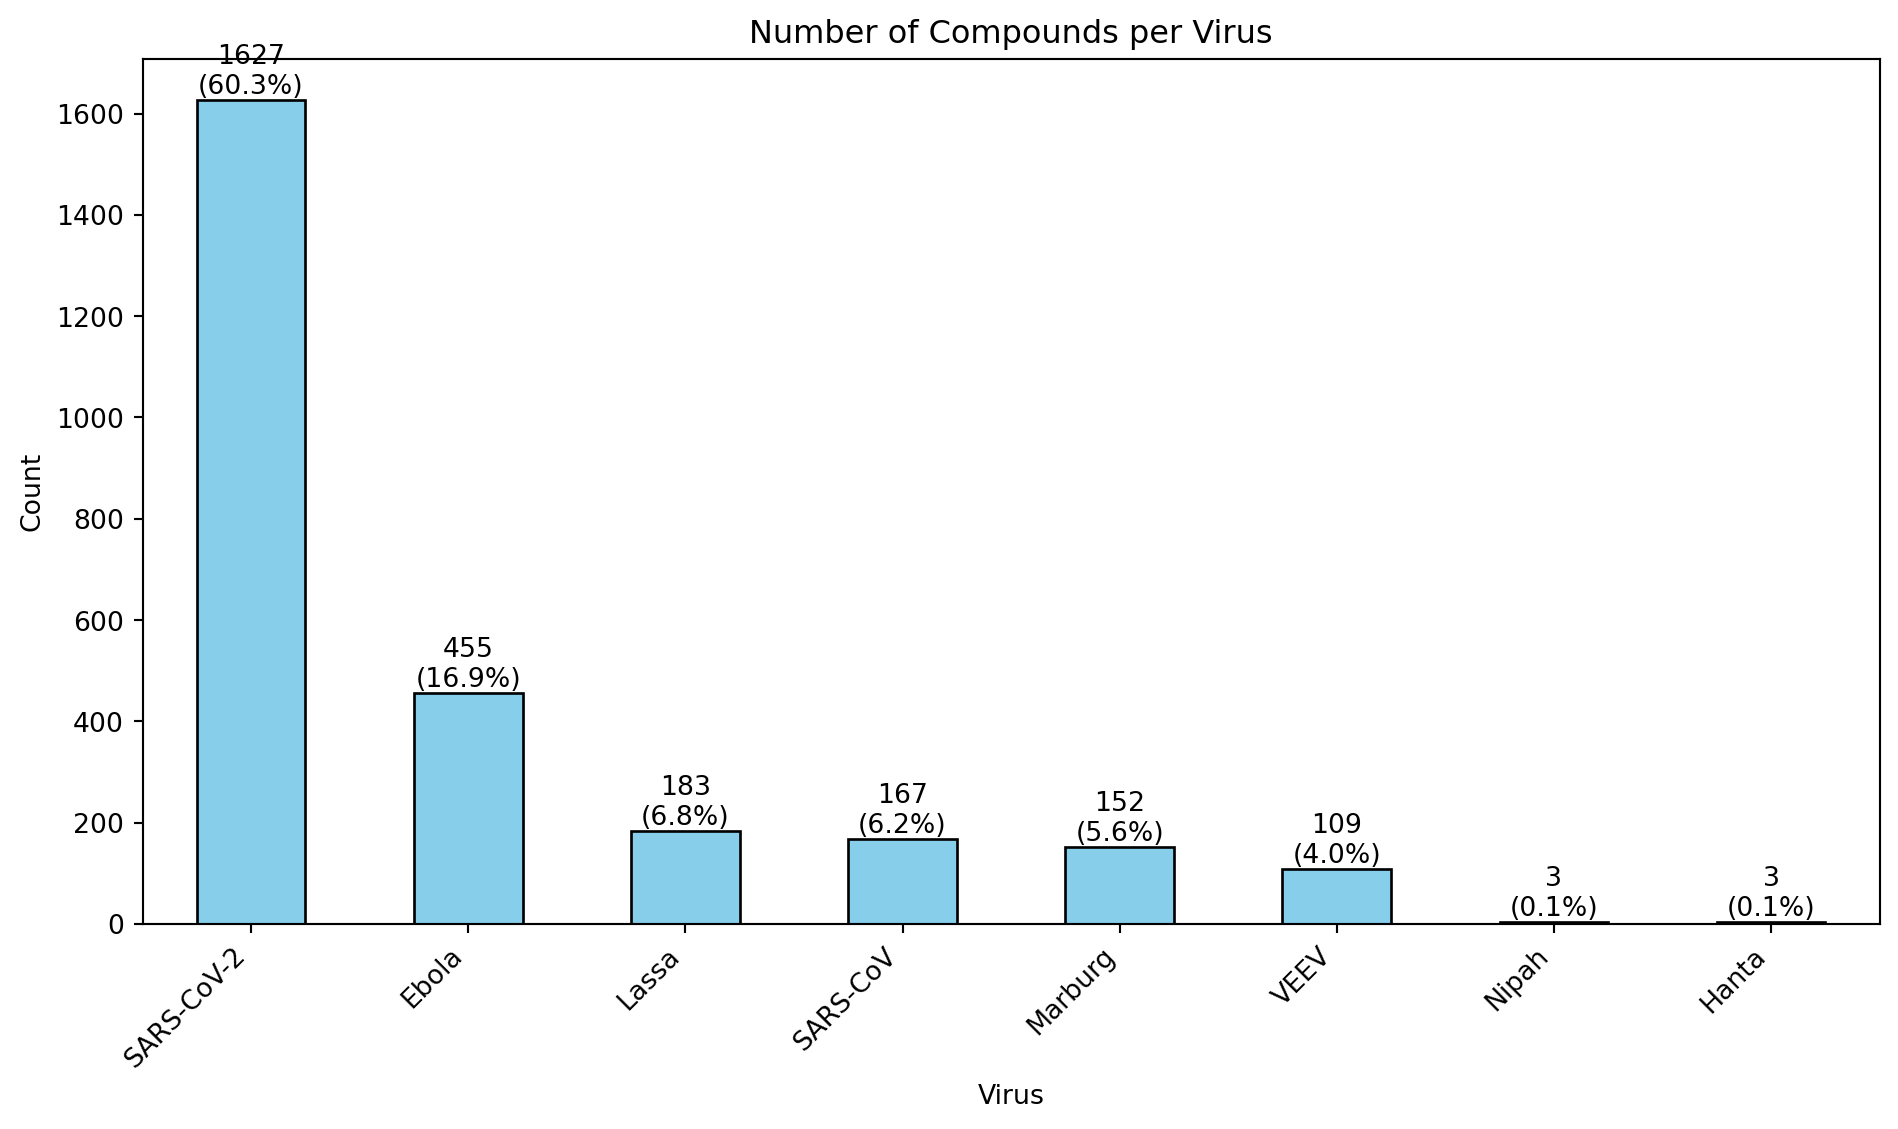

In [614]:
# Get counts and percentages
counts = allVirusData_chEMBL_noDuplicates['VirusClassifier'].value_counts()
percentages = counts / counts.sum() * 100

# Create bar plot
plt.figure(figsize=(10, 6))
bars = counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Number of Compounds per Virus')
plt.xlabel('Virus')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

# Annotate each bar with count and %
for i, (count, pct) in enumerate(zip(counts, percentages)):
    plt.text(
        i, count + 1,                 # position (x, y)
        f'{count}\n({pct:.1f}%)',     # label: count + percentage
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()

In [615]:
allVirusData_chEMBL_noDuplicates.to_csv(os.path.join(modelBuildingDataDir, "allVirusData_chEMBL_noDuplicates_MLready.csv"), index=False)

pPotency value distribution across each Virus

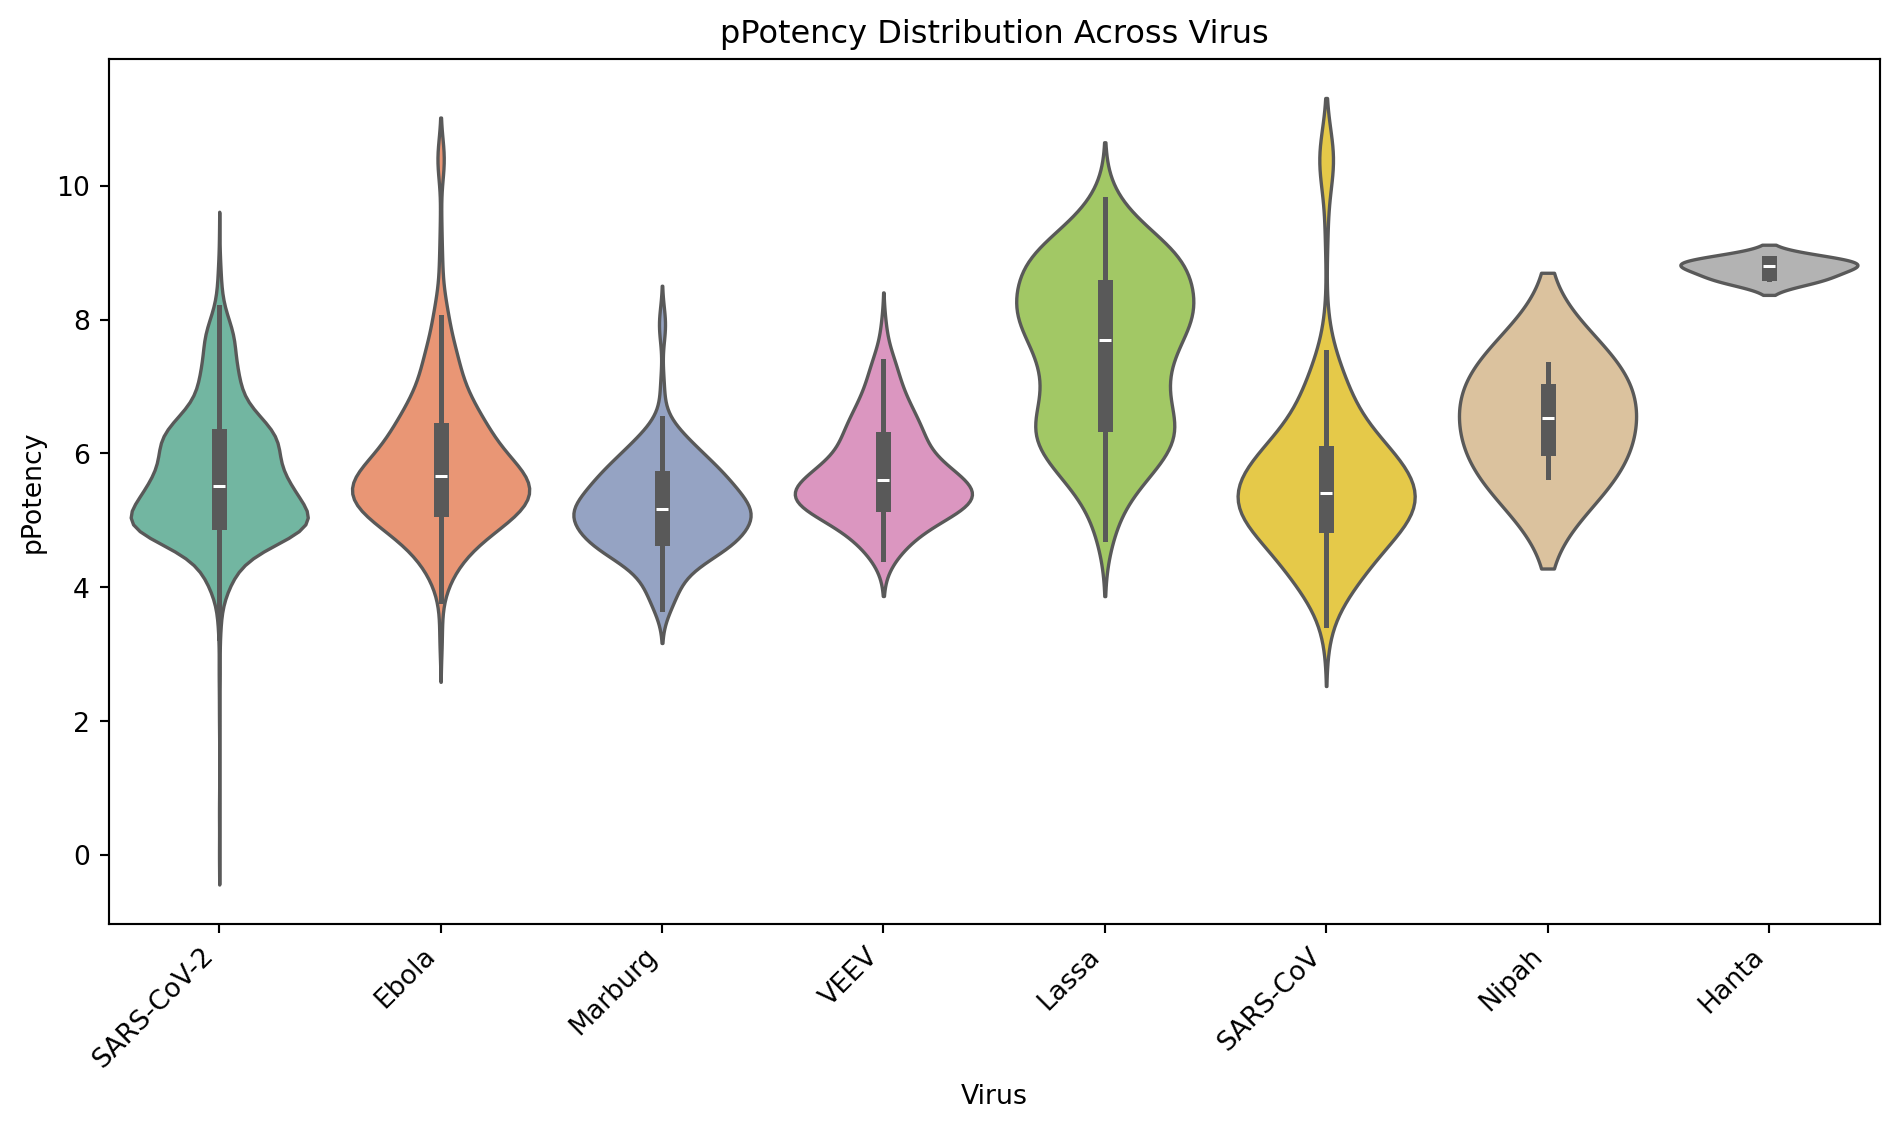

In [616]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=allVirusData_chEMBL_noDuplicates,
    x='VirusClassifier',
    y='pPotency',
    palette='Set2',
    inner='box'
)

plt.xticks(rotation=45, ha='right')
plt.title('pPotency Distribution Across Virus')
plt.xlabel('Virus')
plt.ylabel('pPotency')
plt.tight_layout()
plt.show()

### Create MACAW embeedings to run ART

MACAW settings (coarse):

mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=200, 
    random_state=42
)


MACAW settings (fine):
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=45, 
    n_landmarks=2000, 
    random_state=42
)

In [617]:
# ---------------------------
# 1. FIT MACAW AND GENERATE EMBEDDINGS
# ---------------------------
# Initialize MACAW
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=200, 
    random_state=42
)

# Fit MACAW on SMILES and pPotency
mcw.fit(allVirusData_chEMBL_noDuplicates['Smiles'], allVirusData_chEMBL_noDuplicates['pPotency'])

# Save MACAW transformer
macaw_save_path = os.path.join(modelBuildingDataDir, "allVirusData_chEMBL_noDuplicates_MACAW_transformer.joblib")
with open(macaw_save_path, 'wb') as f:
    pickle.dump(mcw, f)
print(f"MACAW transformer saved to: {macaw_save_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(allVirusData_chEMBL_noDuplicates['Smiles'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")

# ---------------------------
# 2. CREATE DATAFRAME WITH EMBEDDINGS
# ---------------------------
# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=allVirusData_chEMBL_noDuplicates.index)

# ---------------------------
# 3. CONCATENATE WITH ORIGINAL DATAFRAME
# ---------------------------
allVirusData_chEMBL_noDuplicates_wMACAW = pd.concat([allVirusData_chEMBL_noDuplicates, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {allVirusData_chEMBL_noDuplicates.shape}")
print(f"New dataframe shape: {allVirusData_chEMBL_noDuplicates_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
allVirusData_chEMBL_noDuplicates_wMACAW.head()

MACAW transformer saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/allVirusData_chEMBL_noDuplicates_MACAW_transformer.joblib
MACAW embeddings shape: (2699, 15)

Original dataframe shape: (2699, 3)
New dataframe shape: (2699, 18)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15']


,Smiles,VirusClassifier,pPotency,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,MACAW_8,MACAW_9,MACAW_10,MACAW_11,MACAW_12,MACAW_13,MACAW_14,MACAW_15
0,Br.[2H]c1cc([C@]2(C#N)O[C@H](COC(=O)C(C)C)[C@@...,SARS-CoV-2,6.523,-8.166e-03,0.074,-0.157,-0.016,0.059,9.986e-03,-9.094e-03,-0.048,0.103,0.066,-0.048,-0.038,0.010,0.014,0.044
1,C#CC(=O)N1CCN(c2ccc(Cl)c(Cl)c2)[C@H](C(=O)NCc2...,SARS-CoV-2,5.863,-3.119e-03,-0.089,0.084,-0.023,0.031,-0.021,-0.079,-0.057,0.055,-0.040,-0.106,0.042,0.023,-0.023,0.050
2,C#CCC(Cc1cnc2nc(N)nc(N)c2n1)c1ccc(C(=O)N[C@@H]...,SARS-CoV-2,7.222,-9.823e-03,-0.018,-0.020,0.047,0.071,-0.013,-0.042,-7.615e-03,0.079,-0.042,-0.035,-6.860e-03,-0.021,-0.067,-0.024
3,C#CC[C@H](NC(=O)OC(C)(C)C)C(=O)N(Cc1ccccc1)Cc1...,SARS-CoV-2,5.048,-0.027,0.067,0.030,0.039,7.888e-03,-0.032,-0.078,-0.013,0.038,0.049,-0.030,0.032,-0.015,1.176e-04,0.035
4,C#CC[C@H](NCc1ccccc1)C(=O)N[C@@H](Cc1c[nH]c2cc...,SARS-CoV-2,5.005,-0.082,0.098,0.153,-2.478e-03,4.821e-03,0.032,0.049,-0.041,0.049,-0.029,-8.288e-04,-0.063,0.021,5.890e-03,-0.029


In [618]:
allVirusData_chEMBL_noDuplicates_wMACAW.to_csv(os.path.join(modelBuildingDataDir, "allVirusData_chEMBL_noDuplicates_wMACAW.csv"), index=False)

### Train ML Model

In [119]:
Y = allVirusData_chEMBL_noDuplicates.pPotency
smiles = allVirusData_chEMBL_noDuplicates.Smiles

In [120]:
print(len(smiles))

2704


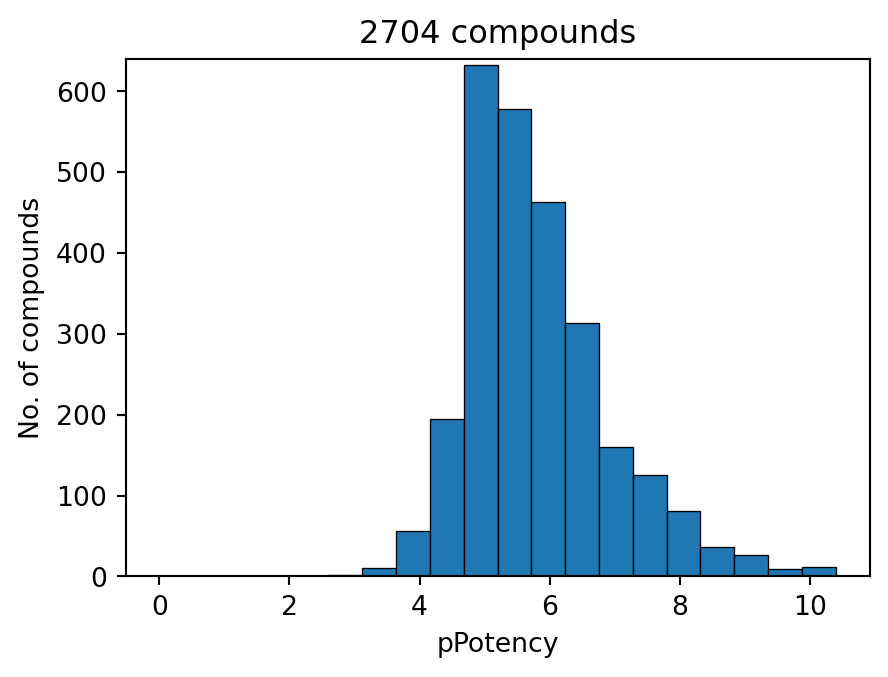

In [121]:
plot_histogram(Y, xlabel="pPotency")

Define the partitions for cross-validation.

In [122]:
num_of_partitions = 10
kf = KFold(n_splits=num_of_partitions, shuffle=True, random_state=42)

Define hyperparameters for SVR:

In [123]:
param_grid = {
    'C': [1, 5, 7, 10, 30, 50, 100, 300, 500], 
    'epsilon': [0.1, 0.3, 1, 3, 5, 10, 20],
    'kernel': ['rbf']
}

Define MACAW embedding:

In [124]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=30, 
    n_landmarks=2000, 
    random_state=42
)

After cleaning NaN values, reset the indices

In [125]:
valid_mask = Y.notna()
smiles = smiles[valid_mask].reset_index(drop=True)  
Y = Y[valid_mask].reset_index(drop=True)            

print(f"Cleaned data has: {len(smiles)} samples")
print(f"Y index: {Y.index[:10].tolist()}")  

Cleaned data has: 2704 samples
Y index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


### ML predictions with Train + Test results

In [126]:
%%time
import numpy as np
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from joblib import Parallel, delayed
from copy import deepcopy

def process_fold(fold_id, train_index, test_index, smiles, Y, mcw, param_grid, num_partitions):
    """Process a single CV fold"""
    print(f"Partition {fold_id}/{num_partitions}")
    
    # Split data
    smi_train = smiles.iloc[train_index]
    smi_test = smiles.iloc[test_index]
    y_train = Y[train_index]
    y_test = Y[test_index]
    
    # Compute MACAW embeddings (clone to avoid conflicts)
    mcw_fold = deepcopy(mcw)
    mcw_fold.fit(smi_train, y_train)
    
    X_train = mcw_fold.transform(smi_train)
    X_test = mcw_fold.transform(smi_test)
    
    # Optimize hyperparameters
    grid = GridSearchCV(SVR(), param_grid, cv=5, refit=True)
    grid.fit(X_train, y_train)
    
    best_params = grid.best_params_
    
    # Predict on both train and test
    y_cv_pred_train = grid.predict(X_train)
    y_cv_pred_test = grid.predict(X_test)
    
    # Calculate fold metrics
    train_mae = mean_absolute_error(y_train, y_cv_pred_train)
    test_mae = mean_absolute_error(y_test, y_cv_pred_test)
    print(f"  Fold {fold_id} - Train MAE: {train_mae:.2f}, Test MAE: {test_mae:.2f}")
    
    # Return all predictions and parameters
    return {
        'train_pred': y_cv_pred_train,
        'train_obs': y_train,
        'test_pred': y_cv_pred_test,
        'test_obs': y_test,
        'best_params': best_params
    }

# Parallel execution
results = Parallel(n_jobs=4, verbose=10)(
    delayed(process_fold)(
        fold_id=i+1,
        train_index=train_idx,
        test_index=test_idx,
        smiles=smiles,
        Y=Y,
        mcw=mcw,
        param_grid=param_grid,
        num_partitions=num_of_partitions
    )
    for i, (train_idx, test_idx) in enumerate(kf.split(smiles))
)

# Combine results
Y_cv_pred_train = []
Y_obs_train = []
Y_cv_pred_test = []
Y_obs_test = []
best_params_per_fold = []

for fold_result in results:
    Y_cv_pred_train.extend(fold_result['train_pred'])
    Y_obs_train.extend(fold_result['train_obs'])
    Y_cv_pred_test.extend(fold_result['test_pred'])
    Y_obs_test.extend(fold_result['test_obs'])
    best_params_per_fold.append(fold_result['best_params'])

# Convert to numpy arrays
Y_cv_pred_train = np.array(Y_cv_pred_train)
Y_obs_train = np.array(Y_obs_train)
Y_cv_pred_test = np.array(Y_cv_pred_test)
Y_obs_test = np.array(Y_obs_test)

# ===== OVERALL METRICS =====
print("\n" + "-"*40)
print("Cross Validation Metrics")
print("-"*40)

# Train metrics
train_mae = mean_absolute_error(Y_obs_train, Y_cv_pred_train)
train_rmse = np.sqrt(mean_squared_error(Y_obs_train, Y_cv_pred_train))
train_r2 = r2_score(Y_obs_train, Y_cv_pred_train)

print(f"Train Set:")
print(f"  MAE:  {train_mae:.2f}")
print(f"  RMSE: {train_rmse:.2f}")
print(f"  R²:   {train_r2:.2f}")

# Test metrics
test_mae = mean_absolute_error(Y_obs_test, Y_cv_pred_test)
test_rmse = np.sqrt(mean_squared_error(Y_obs_test, Y_cv_pred_test))
test_r2 = r2_score(Y_obs_test, Y_cv_pred_test)

print(f"Test Set:")
print(f"  MAE:  {test_mae:.2f}")
print(f"  RMSE: {test_rmse:.2f}")
print(f"  R²:   {test_r2:.2f}")

print(f"\nBest params (sample): {best_params_per_fold[:3]}")

Partition 4/10
  Fold 4 - Train MAE: 0.50, Test MAE: 0.59
Partition 3/10
  Fold 3 - Train MAE: 0.50, Test MAE: 0.55
Partition 2/10
  Fold 2 - Train MAE: 0.51, Test MAE: 0.58
Partition 1/10
  Fold 1 - Train MAE: 0.50, Test MAE: 0.64

----------------------------------------
Cross Validation Metrics
----------------------------------------
Train Set:
  MAE:  0.50
  RMSE: 0.71
  R²:   0.60
Test Set:
  MAE:  0.58
  RMSE: 0.80
  R²:   0.49

Best params (sample): [{'C': 1, 'epsilon': 0.3, 'kernel': 'rbf'}, {'C': 1, 'epsilon': 0.3, 'kernel': 'rbf'}, {'C': 1, 'epsilon': 0.3, 'kernel': 'rbf'}]
CPU times: user 967 ms, sys: 522 ms, total: 1.49 s
Wall time: 1min 48s


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/virus/allVirus_noDuplicates_CV_TrTs.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/virus/allVirus_noDuplicates_CV_TrTs.png


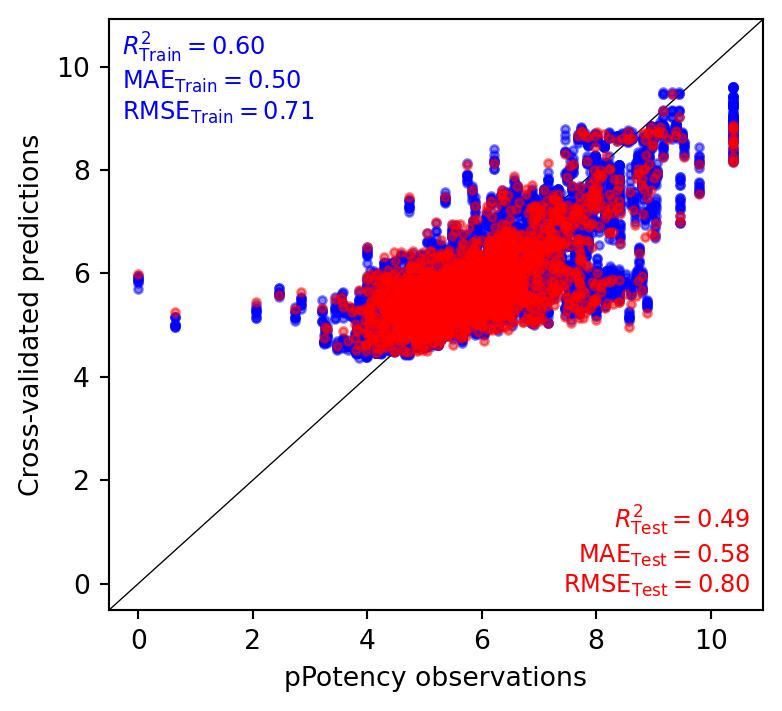

In [127]:
parity_plot(x=Y_obs_train, 
            y=Y_cv_pred_train, 
            x_test=Y_obs_test, 
            y_test=Y_cv_pred_test, 
            xlabel="pPotency observations", 
            ylabel="Cross-validated predictions",
            savetitle=saveDir + 'allVirus_noDuplicates_CV_TrTs.svg',
            save_formats=['svg', 'png'])

Generate a model trained on the whole data set, to be used for prediction tasks

In [128]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=30, 
    n_landmarks=2000, 
    random_state=42
)
mcw.fit(smiles, Y)

In [129]:
X_all = mcw.transform(smiles)
X_all.shape

(2704, 30)

Training samples: 2163
Test samples: 541
Feature dimensions: 15

Running GridSearchCV with 4 parallel jobs...

------------------------------------------------------------
Best Hyperparameters:
------------------------------------------------------------
  C: 10
  epsilon: 0.1
  kernel: rbf

Best CV MAE (on training folds): 0.58

------------------------------------------------------------
PERFORMANCE COMPARISON:
------------------------------------------------------------
Metric     Training        Test            Difference     
------------------------------------------------------------
R²         0.68            0.51            0.17           
MAE        0.40            0.64            0.24           
RMSE       0.62            0.86            0.24           
------------------------------------------------------------


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/virus/allvirusVirus_noDuplicates_fullData_TrTs.svg
Saved: /mnt/data.ese/nfs/users

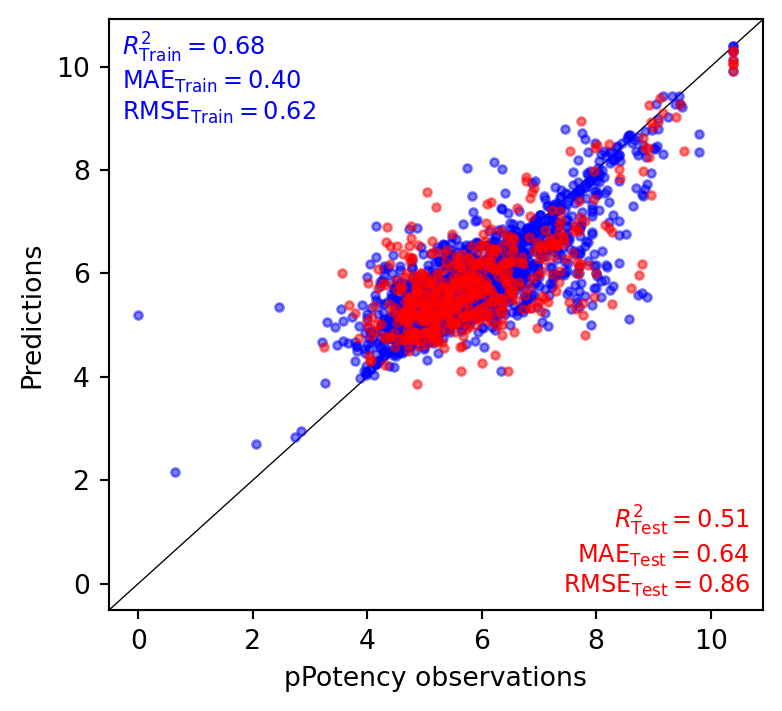

CPU times: user 2.75 s, sys: 88.5 ms, total: 2.84 s
Wall time: 16.6 s


In [130]:
%%time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# ---------------------------
# 1. TRAIN-TEST SPLIT
# ---------------------------
# Since you're working with only one virus group, use regular train_test_split
X_train_smi, X_test_smi, Y_train, Y_test = train_test_split(
    smiles, Y, 
    test_size=0.2, 
    random_state=42,
    shuffle=True
)

print(f"Training samples: {len(X_train_smi)}")
print(f"Test samples: {len(X_test_smi)}")

# ---------------------------
# 2. FIT MACAW ON TRAINING DATA ONLY
# ---------------------------
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=100, 
    random_state=39
)
mcw.fit(X_train_smi, Y_train)

# Transform both train and test
X_train = mcw.transform(X_train_smi)
X_test = mcw.transform(X_test_smi)

print(f"Feature dimensions: {X_train.shape[1]}")

# ---------------------------
# 3. GRID SEARCH ON TRAINING DATA ONLY
# ---------------------------
n_jobs = 4

regr_pred = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    cv=5,
    refit=True,
    n_jobs=n_jobs,
    verbose=0,
    scoring='neg_mean_absolute_error',
    return_train_score=True,
    pre_dispatch='2*n_jobs'
)

print(f"\nRunning GridSearchCV with {n_jobs} parallel jobs...")
regr_pred.fit(X_train, Y_train)

# ---------------------------
# 4. DISPLAY BEST HYPERPARAMETERS
# ---------------------------
print("\n" + "-"*60)
print("Best Hyperparameters:")
print("-"*60)
for param, value in regr_pred.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV MAE (on training folds): {-regr_pred.best_score_:.2f}")

# ---------------------------
# 5. PREDICTIONS AND METRICS
# ---------------------------
# Training predictions (in-sample)
y_train_pred = regr_pred.predict(X_train)

# Test predictions (held-out)
y_test_pred = regr_pred.predict(X_test)

# Calculate metrics for TRAIN
train_r2 = r2_score(Y_train, y_train_pred)
train_mae = mean_absolute_error(Y_train, y_train_pred)
train_rmse = np.sqrt(np.mean((Y_train - y_train_pred)**2))

# Calculate metrics for TEST
test_r2 = r2_score(Y_test, y_test_pred)
test_mae = mean_absolute_error(Y_test, y_test_pred)
test_rmse = np.sqrt(np.mean((Y_test - y_test_pred)**2))

# ---------------------------
# 6. DISPLAY RESULTS
# ---------------------------
print("\n" + "-"*60)
print("PERFORMANCE COMPARISON:")
print("-"*60)
print(f"{'Metric':<10} {'Training':<15} {'Test':<15} {'Difference':<15}")
print("-"*60)
print(f"{'R²':<10} {train_r2:<15.2f} {test_r2:<15.2f} {abs(train_r2-test_r2):<15.2f}")
print(f"{'MAE':<10} {train_mae:<15.2f} {test_mae:<15.2f} {abs(train_mae-test_mae):<15.2f}")
print(f"{'RMSE':<10} {train_rmse:<15.2f} {test_rmse:<15.2f} {abs(train_rmse-test_rmse):<15.2f}")
print("-"*60)

# Check for overfitting
overfit_gap = train_r2 - test_r2
if overfit_gap > 0.1:
    print("\n  WARNING: Possible overfitting detected (R² gap > 0.1)")
elif test_r2 >= 0.7:
    print("\n Good generalization performance!")

print("\n" + "="*60)

# ---------------------------
# 7. GENERATE PARITY PLOT
# ---------------------------
parity_plot(
    x=Y_train,                      # observed train
    y=y_train_pred,                 # predicted train (in-sample)
    x_test=Y_test,                  # observed test
    y_test=y_test_pred,             # predicted test (held-out)
    xlabel="pPotency observations",
    ylabel="Predictions",
    savetitle=saveDir + 'allvirusVirus_noDuplicates_fullData_TrTs.svg',
    save_formats=['svg', 'png']
)

## 2.1 Discovery of new hits specific to all viruses (data source Enamine_antiviralsData.csv)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [131]:
EnamineAntiviralsData = pd.read_csv(dataDir + "Enamine/Enamine_Antiviral_Library_plated_3200cmpds_20251019.csv",
                                    sep=",", comment=None, skipinitialspace=True, engine="python", encoding="utf-8",          
                                    skiprows=1, skip_blank_lines=True)
print(f"Original Enamine data shape: {EnamineAntiviralsData.shape}")

smiles_train = allVirusData_chEMBL.Smiles

# Function to canonicalize SMILES using RDKit
def canonicalize_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            return Chem.MolToSmiles(mol, canonical=True)
        else:
            return None
    except:
        return None

# Canonicalize training SMILES and create a set for fast lookup
canonical_train = set()
for smi in smiles_train:
    canonical_smi = canonicalize_smiles(smi)
    if canonical_smi is not None:
        canonical_train.add(canonical_smi)

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to Enamine data
EnamineAntiviralsData['Canonical_SMILES'] = EnamineAntiviralsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~EnamineAntiviralsData['Canonical_SMILES'].isin(canonical_train)
EnamineAntiviralsData_filtered = EnamineAntiviralsData[mask].copy()

# Remove the helper column if you don't need it
EnamineAntiviralsData = EnamineAntiviralsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered Enamine data shape for validation: {EnamineAntiviralsData.shape}")
print(f"Removed {EnamineAntiviralsData.shape[0] - EnamineAntiviralsData_filtered.shape[0]} duplicate compounds from Enamine data set")

# Now use the filtered data
smi_lib = EnamineAntiviralsData.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
EnamineAntiviralsData.head()

Original Enamine data shape: (3200, 11)
Number of unique SMILES in training set: 2484
Filtered Enamine data shape for validation: (3200, 11)
Removed 0 duplicate compounds from Enamine data set
Total compounds to screen: 3200


,SMILES,Catalog ID,MW,MW (desalted),ClogP,logS,HBD,HBA,TPSA,RotBonds,AnalogsFromREAL
0,COCC(C)NC(=O)NC1=NN=C(S1)C2CC2,Z410227912,256.326,256.326,1.231,-2.190,2,4,76.140,5,https://real.enamine.net/public-enum-files/Z41...
1,CN1C(=O)C=CN(CC(=O)NCC2CC2)C1=O,Z383167688,237.256,237.256,-0.042,-0.692,1,3,69.720,5,https://real.enamine.net/public-enum-files/Z38...
2,CCN(CC)CCNC(=O)C1=CC=CN=C1N2CCOCC2,Z235579208,306.404,306.404,1.583,-2.082,1,5,57.700,7,NaN
3,CCC(CNC(=O)CC=1C(C)=NOC1C)N2CCCC2,Z403694008,279.379,279.379,1.156,-0.660,1,3,58.370,7,https://real.enamine.net/public-enum-files/Z40...
4,CCC(C)(CNC(=O)CN1C=CC=CC1=O)N2CCOCC2,Z384461492,307.389,307.389,1.084,-1.180,1,4,61.880,7,https://real.enamine.net/public-enum-files/Z38...


Generate predictions for the H1 receptor:

In [132]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

In [133]:
EnamineAntiviralsData_predicted = EnamineAntiviralsData.copy()
EnamineAntiviralsData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
EnamineAntiviralsData_predicted['pPotency(M)_prediction'] = 10 ** (-EnamineAntiviralsData_predicted['pPotency_prediction'])

EnamineAntiviralsData_predicted = EnamineAntiviralsData_predicted.filter(
    items=["SMILES", "pPotency_prediction",  "pPotency(M)_prediction"]
)
EnamineAntiviralsData_predicted.to_csv(os.path.join(resultsDir + "virus/allvirus_noDuplicates_EnamineDatasets_predicted_all.csv"), index=False)
EnamineAntiviralsData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "virus/allvirus_noDuplicates_EnamineDatasets_EnamineDatasets_predicted_all_SMILES.csv"), index=False)
EnamineAntiviralsData_predicted

,SMILES,pPotency_prediction,pPotency(M)_prediction
0,COCC(C)NC(=O)NC1=NN=C(S1)C2CC2,5.105,7.855e-06
1,CN1C(=O)C=CN(CC(=O)NCC2CC2)C1=O,5.835,1.461e-06
2,CCN(CC)CCNC(=O)C1=CC=CN=C1N2CCOCC2,5.532,2.938e-06
3,CCC(CNC(=O)CC=1C(C)=NOC1C)N2CCCC2,5.298,5.040e-06
4,CCC(C)(CNC(=O)CN1C=CC=CC1=O)N2CCOCC2,5.907,1.238e-06
...,...,...,...
3195,CCOC=1N=CC=CC1NC(=O)NC2CCN3CCCCC23,5.055,8.805e-06
3196,CC1=NN(CC(O)C=2C=CC=CC2)C(=O)C(C#N)=C1C,6.122,7.545e-07
3197,CCC1=NN=NN1CC(=O)NC2CCN(CC2)C(C)=O,5.279,5.255e-06
3198,CC=1C=C2N=CN(CC(O)CN3CCS(=O)CC3)C2=CC1C,4.968,1.077e-05


Let us represent the predictions of both models:

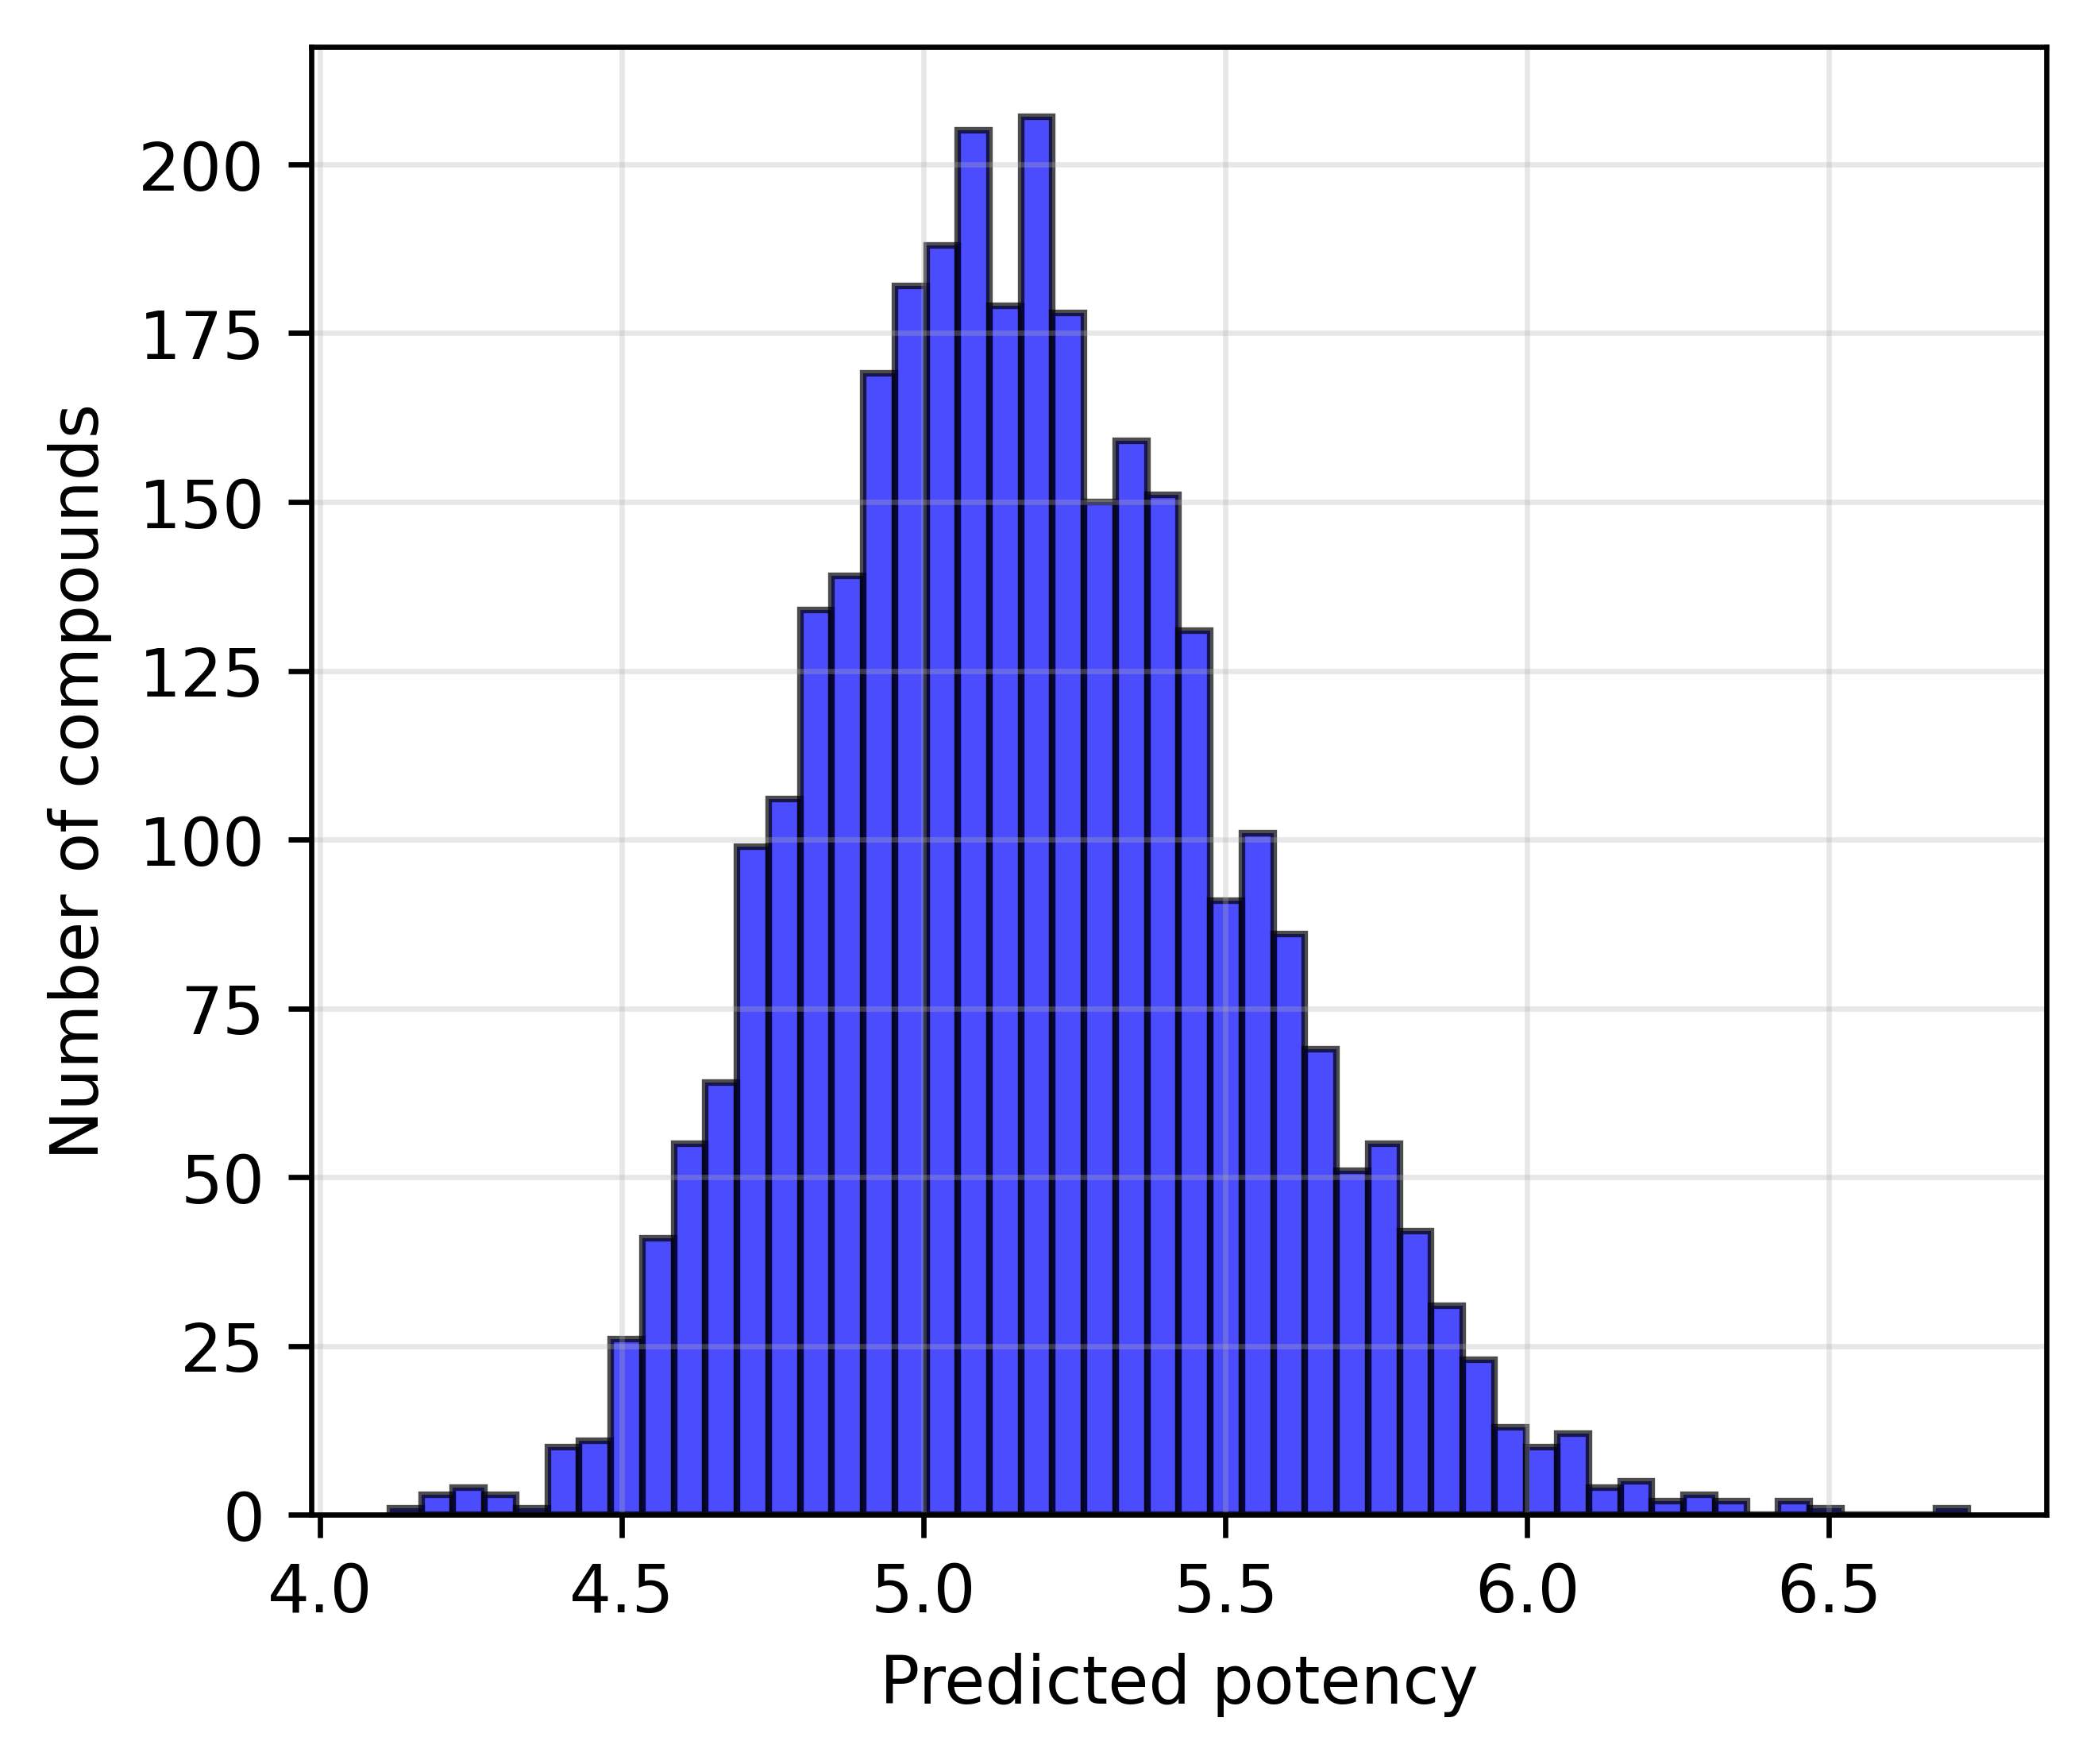

In [134]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + 'allvirus_noDuplicates_validation.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + 'allvirus_noDuplicates_validation.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [135]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 0 compounds
Medium priority (6 ≤ pPotency < 7.0): 42 compounds
Low priority (5 ≤ pPotency < 6): 2118 compounds


In [136]:
EnamineAntiviralsData_final = EnamineAntiviralsData.iloc[idx].copy()
EnamineAntiviralsData_final['pPotency_prediction'] = Y1_lib_pred[idx]

EnamineAntiviralsData_final

,SMILES,Catalog ID,MW,MW (desalted),ClogP,logS,HBD,HBA,TPSA,RotBonds,AnalogsFromREAL,pPotency_prediction


### Top 20 compounds with higher PpPotency

In [137]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 6.10
Highest predicted pPotency: 6.73
Range of top 20: 6.10 - 6.73


In [138]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
EnamineAntiviralsData_top20 = EnamineAntiviralsData.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
EnamineAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
EnamineAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
EnamineAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
EnamineAntiviralsData_top20 = EnamineAntiviralsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
EnamineAntiviralsData_top20

----------------------------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
----------------------------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    6.104
  IC50:        7.870e-07 M  (787.02 nM)

Best Values (1st ranked compound):
  pPotency:    6.730
  IC50:        1.864e-07 M  (186.41 nM)
Range for Top 20 Compounds:
pPotency Range:  6.104 - 6.730

IC50 Range (M):  7.870e-07 - 1.864e-07


,Rank,SMILES,pPotency_prediction,IC50 (M)
535,1,CC(=O)NC(C(=O)NC(C)CN1C=CN=C1)C(C)C,6.730,1.864e-07
2078,2,CNC(=O)C(C)NC(=O)C(C)N1C=NC=N1,6.471,3.381e-07
2539,3,OC(CN1C=NC=2C=CC=CC21)C=3C=CC(=CC3)OC(F)F,6.447,3.572e-07
601,4,CN1C(=O)C2=C(N=CN2CC(O)C=3C=CC=CC3)N(C)C1=O,6.423,3.776e-07
1810,5,CC1=NNC(C)=C1C(C)C(=O)NC(C)C(C)C,6.337,4.599e-07
2621,6,N#CC1=CN(C(=O)N(CC(N)=O)C1=O)C2CC2,6.335,4.629e-07
1355,7,CC1=NC=2C=CC=CC2N1CC(O)C=3C=CC(=CC3)OC(F)F,6.291,5.122e-07
3058,8,COC1(C)CC(NC(=O)CN2C=CC=CC2=O)C1(C)C,6.290,5.125e-07
980,9,OCC1=NC=2C=CC=CC2N1CC(O)C=3C=CC(=CC3)OC(F)F,6.288,5.156e-07
439,10,CN1C(=O)C2=C(N=CN2CC(O)C=3C=CC=C(F)C3)N(C)C1=O,6.240,5.748e-07


In [139]:
EnamineAntiviralsData_top20.to_csv(os.path.join(resultsDir + "virus/allvirus_noDuplicates_EnamineAntiviralsData_top20.csv"), index=False)
EnamineAntiviralsData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "virus/allvirus_noDuplicates_EnamineAntiviralsData_top20_SMILES.csv"), index=False)

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/virus/allVirus_noDuplicates_predictedCompounds.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/virus/allVirus_noDuplicates_predictedCompounds.svg


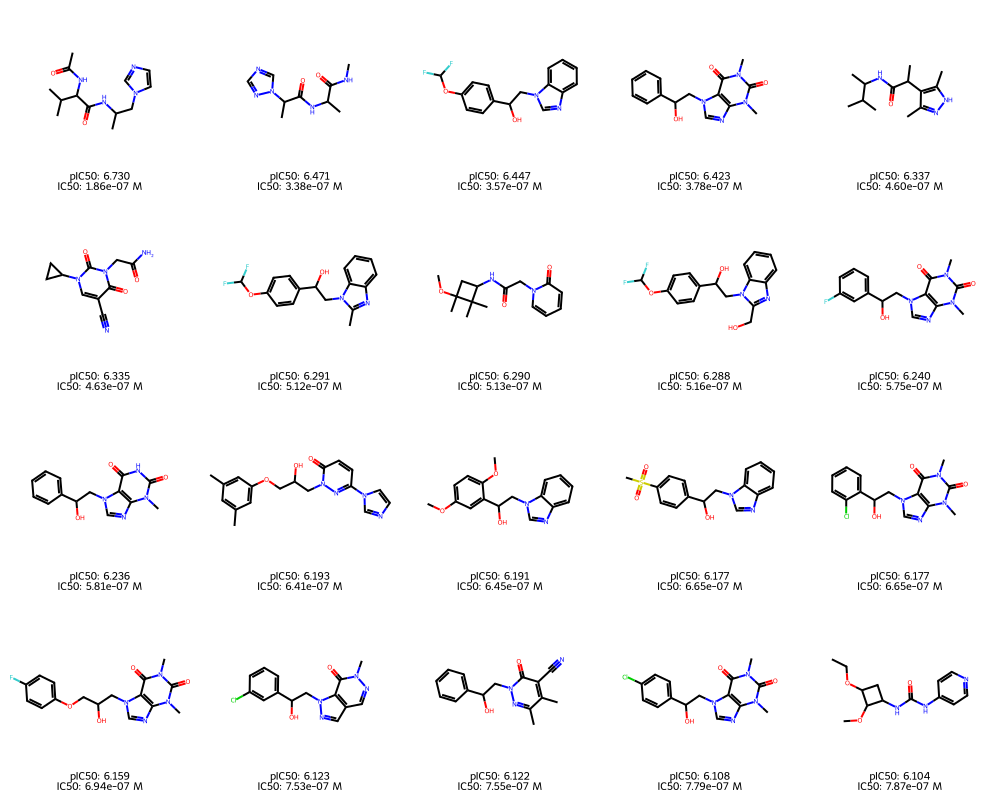

In [140]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image

# Setup paths
output_dir = saveDir + ''
os.makedirs(output_dir, exist_ok=True)

# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntiviralsData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in EnamineAntiviralsData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = output_dir + 'allVirus_noDuplicates_predictedCompounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = output_dir + 'allVirus_noDuplicates_predictedCompounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

Let us represent the predictions of both models:

### 2.2 Discovery of new hits specific to all viruses (data source Life chemicals data set)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models regr above, which use 15-D MACAW embeddings as their input. The custom library compiled from commercial catalogs by Life chemicals. In particular, we are interested in molecules with high predicted pPotency.

In [141]:
# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "LifeChemicals/LC_Merged_Antiviral_Screening_Superset.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

LCAntiviralsData_superset = pd.DataFrame(records)
print(f"Original LifeChemicals data shape: {LCAntiviralsData_superset.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to LifeChemicals data (reusing canonical_train from code-1)
LCAntiviralsData_superset['Canonical_SMILES'] = LCAntiviralsData_superset['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~LCAntiviralsData_superset['Canonical_SMILES'].isin(canonical_train)
LCAntiviralsData_superset_filtered = LCAntiviralsData_superset[mask].copy()

# Remove the helper column if you don't need it
LCAntiviralsData_superset = LCAntiviralsData_superset_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered LifeChemicals data shape for validation: {LCAntiviralsData_superset.shape}")
print(f"Removed {LCAntiviralsData_superset_filtered.shape[0] - LCAntiviralsData_superset.shape[0]} duplicate compounds from LifeChemicals data set")

# Now use the filtered data
smi_lib = LCAntiviralsData_superset.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
LCAntiviralsData_superset.head()

Original LifeChemicals data shape: (45573, 17)
Number of unique SMILES in training set: 2484
Filtered LifeChemicals data shape for validation: (45564, 17)
Removed 0 duplicate compounds from LifeChemicals data set
Total compounds to screen: 45564


,IDNUMBER,Chemical_Name,CAS,PriceCoeff,MW,Description,FSP3,clogP,TPSA,Acceptor,Donor,RotBonds,HAC,Collection,Library,PPDS,SMILES
0,F6544-0534,"11-(oxan-4-yl)-7,11-diazatricyclo[7.3.1.0²,⁷]t...",2034607-75-3,1.500,274.360,solid,0.690,-0.120,32.780,2,1,1,20.000,Advanced,Anti-Hepatitis_A_B_ Screening_Library,,Cl.O=c1cccc2n1CC1CC2CN(C2CCOCC2)C1
1,F6559-5304,6-[4-(trifluoromethyl)pyrimidin-2-yl]-6-azaspi...,2034225-11-9,1.500,301.260,solid,0.620,2.030,66.320,4,1,2,21.000,Advanced,2019-nCoV_Main_Protease_Targeted_Library,+,O=C(O)C1CN(c2nccc(C(F)(F)F)n2)CC12CCC2
2,F6610-6619,"1-methyl-4-[(pyridin-4-yl)methyl]-1,4-diazepane",2320860-02-2,1.000,205.300,oil,0.580,0.890,19.370,3,3,2,15.000,General,Anti-HIV_Focused_Library,,CN1CCCN(Cc2ccncc2)CC1
3,F6559-5274,"6-(4,6-dimethylpyrimidin-2-yl)-6-azaspiro[3.4]...",2034225-08-4,1.500,261.320,oil,0.640,2.090,66.320,4,1,2,19.000,Advanced,Antiviral_Screening_Compound_Library_2D_Simila...,,Cc1cc(C)nc(N2CC(C(=O)O)C3(CCC3)C2)n1
4,F1912-1536,N-cyclopropyl-N-(piperidin-4-yl)pyrimidin-4-amine,1781768-10-2,1.500,218.290,solid,0.670,0.790,41.050,2,2,3,16.000,Advanced,Antiviral_Screening_Compound_Library_2D_Simila...,,c1cc(N(C2CCNCC2)C2CC2)ncn1


Generate predictions for the H1 receptor:

In [142]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

In [143]:
LCAntiviralsData_predicted = LCAntiviralsData_superset.copy()
LCAntiviralsData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
LCAntiviralsData_predicted['pPotency(M)_prediction'] = 10 ** (-LCAntiviralsData_predicted['pPotency_prediction'])

LCAntiviralsData_predicted = LCAntiviralsData_predicted.filter(
    items=["SMILES", "pPotency_prediction",  "pPotency(M)_prediction"]
)
LCAntiviralsData_predicted.to_csv(os.path.join(resultsDir + "virus/allvirus_noDuplicates_LCDatasets_predicted_all.csv"), index=False)
LCAntiviralsData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "virus/allvirus_noDuplicates_LCDatasets_predicted_all_SMILES.csv"), index=False)
LCAntiviralsData_predicted

,SMILES,pPotency_prediction,pPotency(M)_prediction
0,Cl.O=c1cccc2n1CC1CC2CN(C2CCOCC2)C1,5.079,8.345e-06
1,O=C(O)C1CN(c2nccc(C(F)(F)F)n2)CC12CCC2,5.631,2.337e-06
2,CN1CCCN(Cc2ccncc2)CC1,5.689,2.046e-06
3,Cc1cc(C)nc(N2CC(C(=O)O)C3(CCC3)C2)n1,5.918,1.209e-06
4,c1cc(N(C2CCNCC2)C2CC2)ncn1,5.242,5.722e-06
...,...,...,...
45568,CCN1C=C/C(=C\C=C\c2cc[n+](CC)c3ccccc23)c2ccccc...,5.162,6.893e-06
45569,CCCN1/C(=C/C=C/c2sc3ccccc3[n+]2CCC)Sc2ccccc21....,5.348,4.490e-06
45570,COC(=O)c1ccccc1-c1c2ccc(=N)cc-2oc2cc(N)ccc12.Cl,5.864,1.368e-06
45571,CCN1/C(=C/C=C2\CCC(/C=C/c3sc4ccc(Cl)cc4[n+]3CC...,5.056,8.780e-06


Let us represent the predictions of both models:

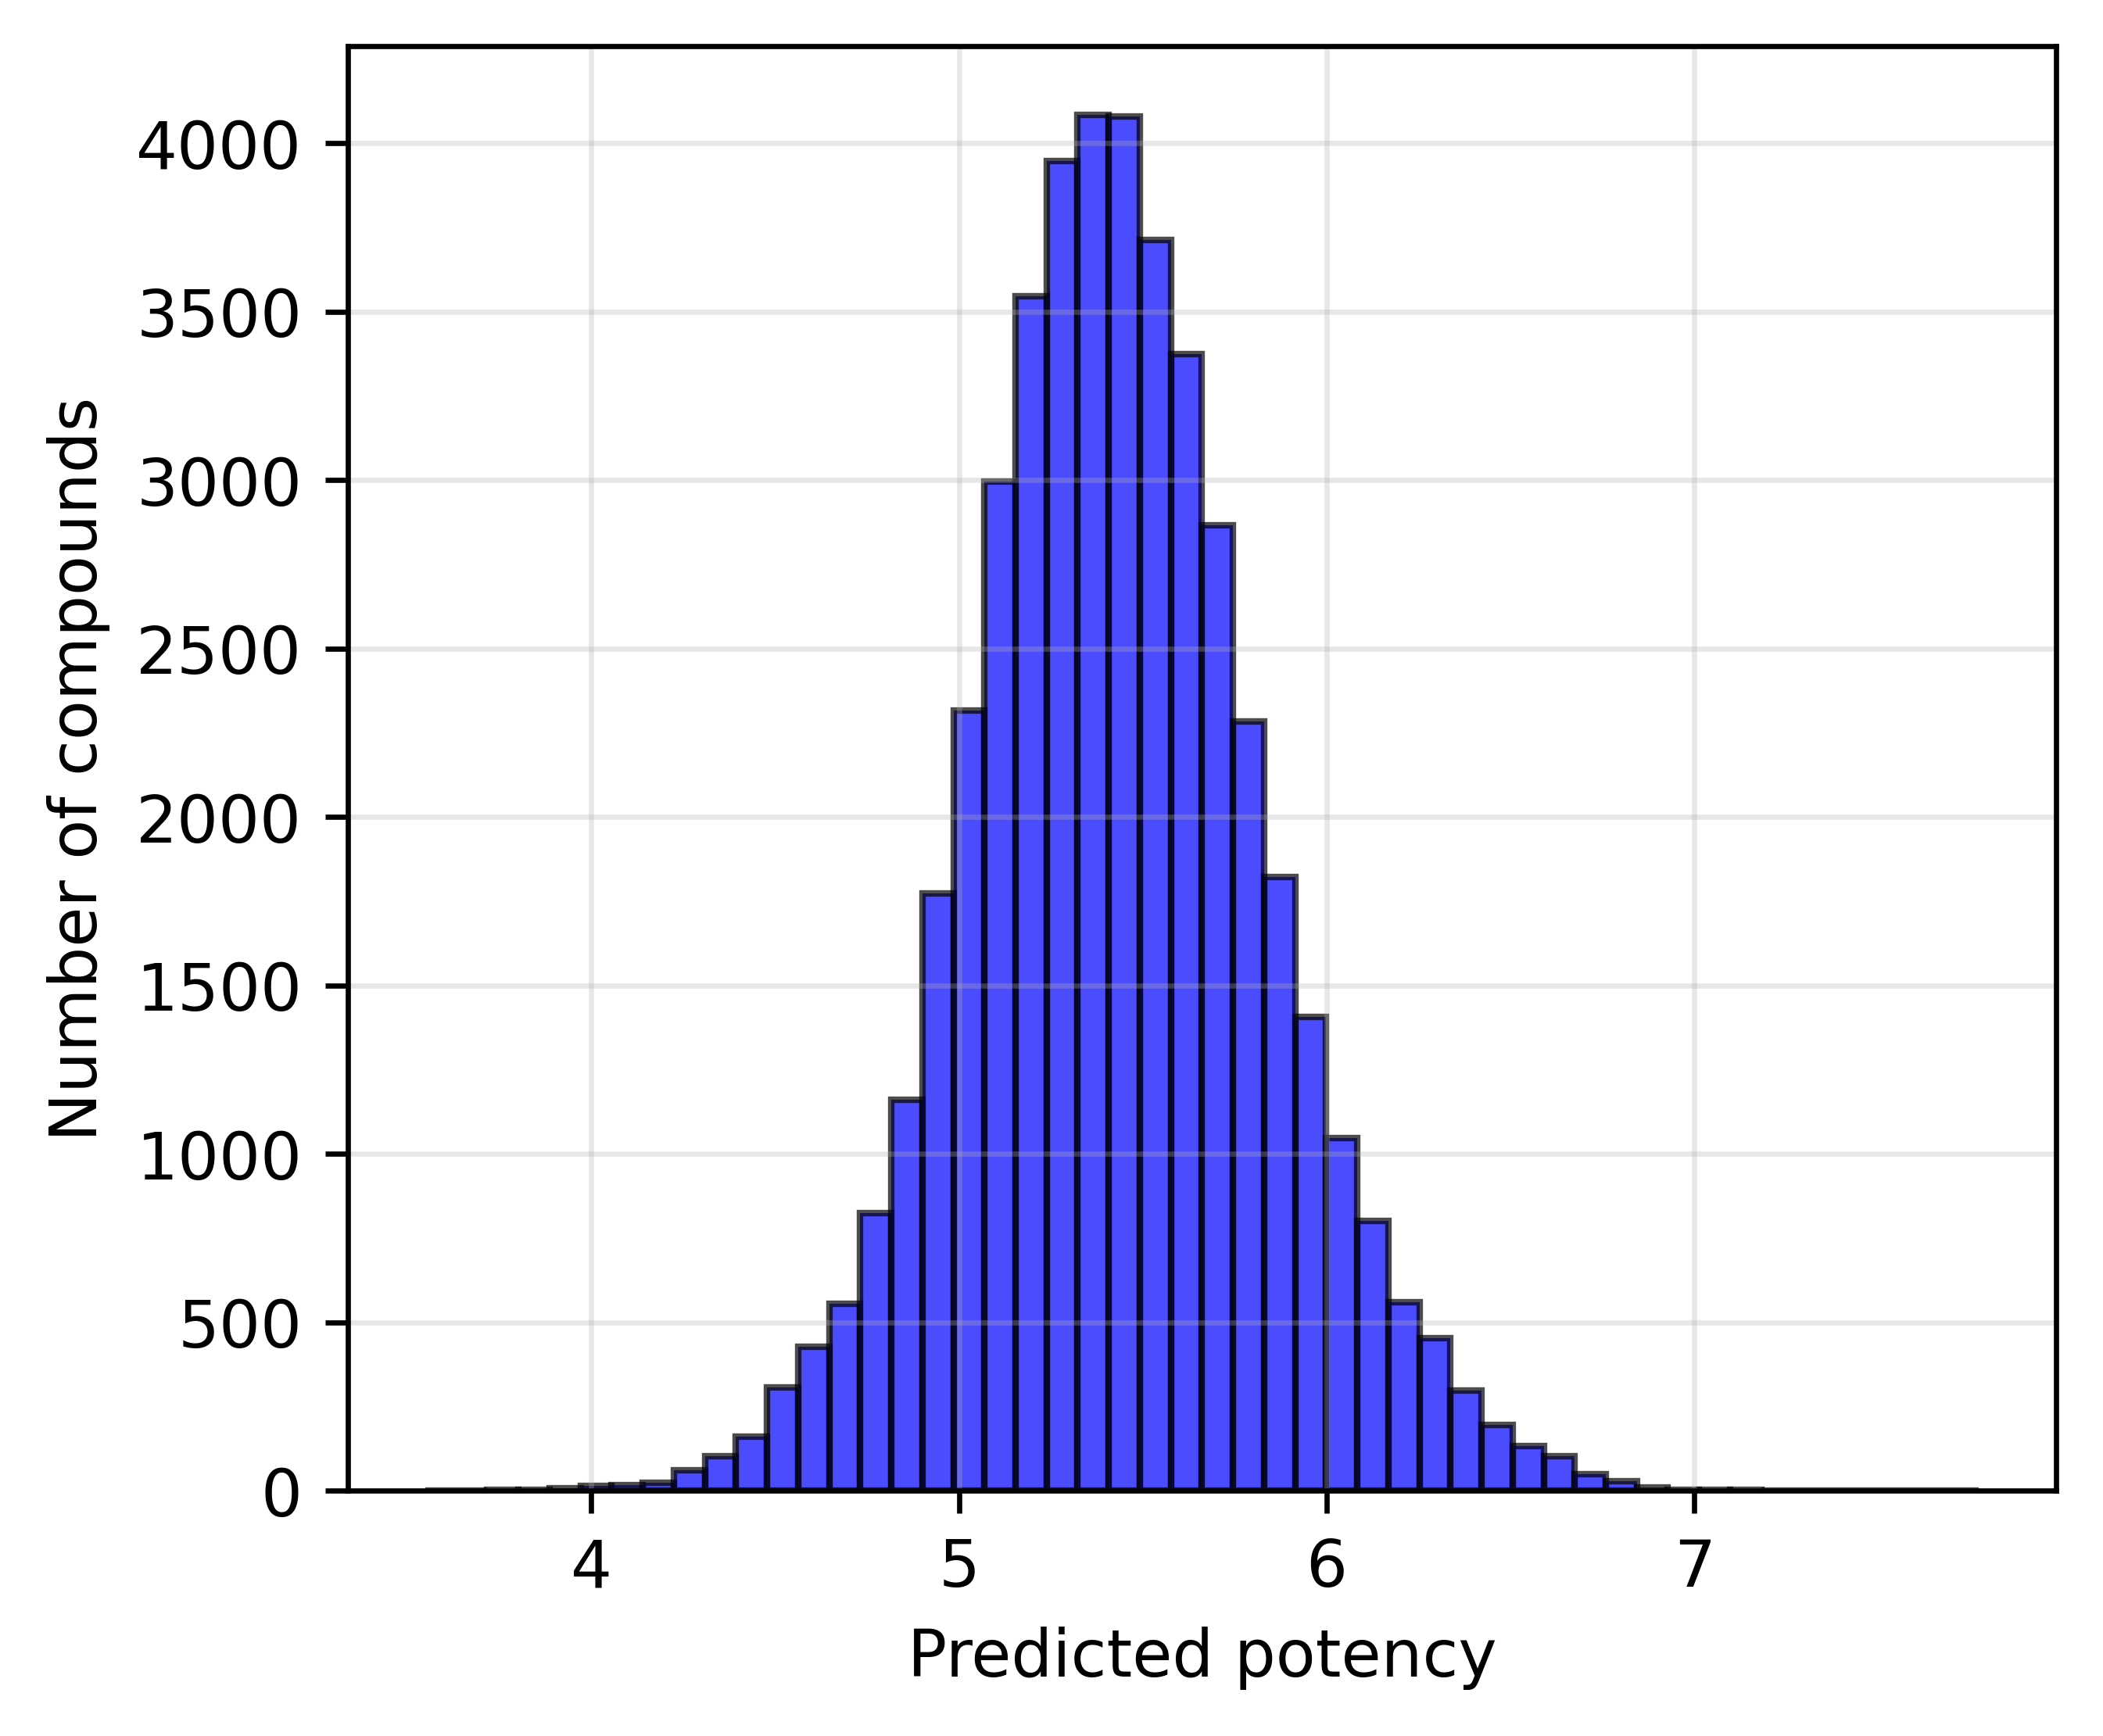

In [144]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + 'allvirus_noDuplicates_validation_LCDatasets.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + 'allvirus_noDuplicates_validation_LCDatasets.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [145]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 11 compounds
Medium priority (6 ≤ pPotency < 7.0): 3657 compounds
Low priority (5 ≤ pPotency < 6): 36110 compounds


In [146]:
LCAntiviralsData_superset_final = LCAntiviralsData_superset.iloc[idx].copy()
LCAntiviralsData_superset_final['pPotency_prediction'] = Y1_lib_pred[idx]
LCAntiviralsData_superset_final = LCAntiviralsData_superset_final.filter(
    items=["SMILES", "pPotency_prediction", "clogP"]
)
LCAntiviralsData_superset_final

,SMILES,pPotency_prediction,clogP
15572,COc1ccc(CNC(=O)Cc2cc(-c3ccc(OC)cc3)on2)cc1,7.037,2.740
17813,COc1ccc(-n2ccnc2SCC(=O)NCc2ccccc2)c(OC)c1,7.315,3.690
19520,Cc1sc2ncnc(N3CCN(c4ncnc5sc(C)c(C)c45)CC3)c2c1C,7.036,4.480
20942,COc1ccc2c(=O)c3c(oc2c1)C(=O)N(CCN(C)C)C3c1ccc(...,7.121,1.980
26648,CCOc1ccc(-n2nnnc2SC(C)C(=O)Nc2ccccc2)cc1,7.120,3.440
26856,O=C1Oc2ccccc2C2c3sc(=O)[nH]c3SC(c3ccccc3)C12,7.107,3.090
28512,COc1ccc(-n2ccnc2SCC(=O)NCc2ccc3c(c2)OCO3)c(OC)c1,7.164,3.660
29423,COC(=O)c1ccc(C2c3c(oc4ccc(Cl)cc4c3=O)C(=O)N2c2...,7.076,3.300
30201,COc1ccc(/C=C2\Oc3c(cc4c(c3C)OCN(Cc3ccco3)C4)C2...,7.001,4.890
39235,CC(C)Oc1ccc(C(Nc2ccccn2)c2ccc3cccnc3c2O)cc1,7.773,4.550


### Top 20 compounds with higher PpPotency

In [147]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 6.88
Highest predicted pPotency: 7.77
Range of top 20: 6.88 - 7.77


In [148]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
LCAntiviralsData_top20 = LCAntiviralsData_superset.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
LCAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
LCAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
LCAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
LCAntiviralsData_top20 = LCAntiviralsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
LCAntiviralsData_top20

----------------------------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
----------------------------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    6.876
  IC50:        1.332e-07 M  (133.20 nM)

Best Values (1st ranked compound):
  pPotency:    7.773
  IC50:        1.686e-08 M  (16.86 nM)
Range for Top 20 Compounds:
pPotency Range:  6.876 - 7.773

IC50 Range (M):  1.332e-07 - 1.686e-08


,Rank,SMILES,pPotency_prediction,IC50 (M)
39235,1,CC(C)Oc1ccc(C(Nc2ccccn2)c2ccc3cccnc3c2O)cc1,7.773,1.686e-08
17813,2,COc1ccc(-n2ccnc2SCC(=O)NCc2ccccc2)c(OC)c1,7.315,4.842e-08
28512,3,COc1ccc(-n2ccnc2SCC(=O)NCc2ccc3c(c2)OCO3)c(OC)c1,7.164,6.851e-08
20942,4,COc1ccc2c(=O)c3c(oc2c1)C(=O)N(CCN(C)C)C3c1ccc(...,7.121,7.565e-08
26648,5,CCOc1ccc(-n2nnnc2SC(C)C(=O)Nc2ccccc2)cc1,7.120,7.577e-08
26856,6,O=C1Oc2ccccc2C2c3sc(=O)[nH]c3SC(c3ccccc3)C12,7.107,7.822e-08
29423,7,COC(=O)c1ccc(C2c3c(oc4ccc(Cl)cc4c3=O)C(=O)N2c2...,7.076,8.395e-08
15572,8,COc1ccc(CNC(=O)Cc2cc(-c3ccc(OC)cc3)on2)cc1,7.037,9.187e-08
19520,9,Cc1sc2ncnc(N3CCN(c4ncnc5sc(C)c(C)c45)CC3)c2c1C,7.036,9.211e-08
40207,10,COc1cccc(C2c3c(oc4ccc(Cl)cc4c3=O)C(=O)N2CCc2cc...,7.018,9.596e-08


In [149]:
LCAntiviralsData_top20.to_csv(os.path.join(resultsDir + "virus/allvirus_noDuplicates_LCAntiviralsData_top20.csv"), index=False)
LCAntiviralsData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "virus/allvirus_noDuplicates_LCAntiviralsData_top20_SMILES.csv"), index=False)

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/virus/allVirus_noDuplicates_predictedCompounds_LCDataset.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/virus/allVirus_noDuplicates_predictedCompounds_LCDataset.svg


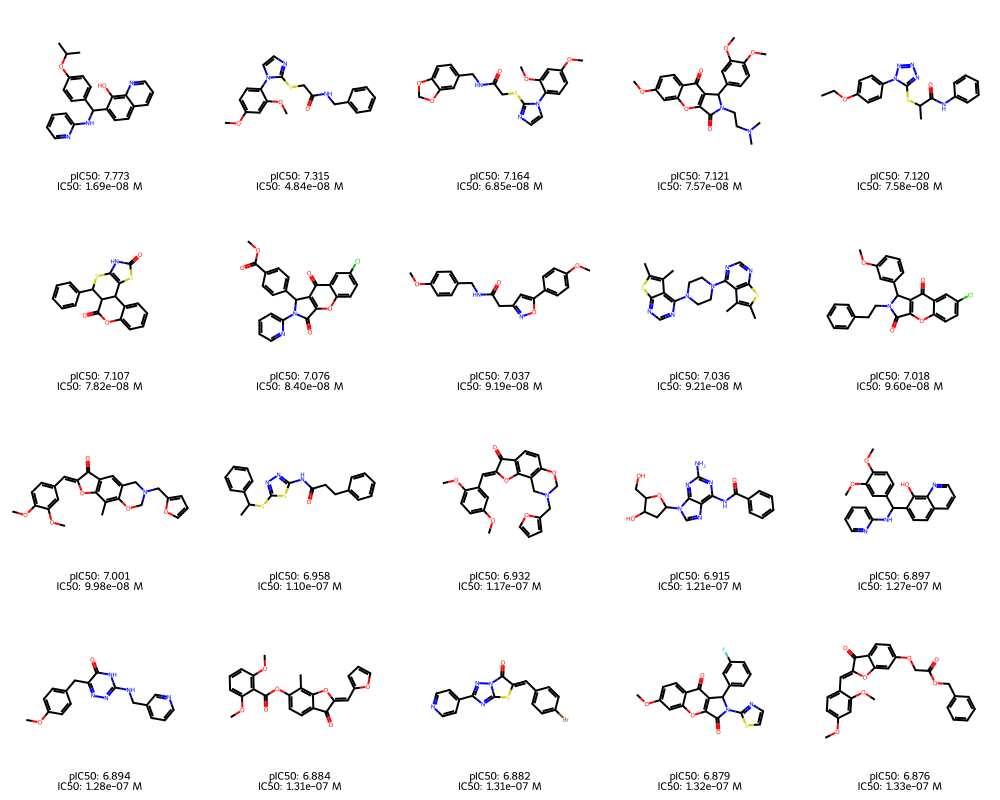

In [150]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image

# Setup paths
output_dir = saveDir + ''
os.makedirs(output_dir, exist_ok=True)

# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in LCAntiviralsData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in LCAntiviralsData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = output_dir + 'allVirus_noDuplicates_predictedCompounds_LCDataset.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = output_dir + 'allVirus_noDuplicates_predictedCompounds_LCDataset.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img) 

### 2.3 Discovery of new hits specific to all viruses (data source chemDiv data set)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models regr above, which use 15-D MACAW embeddings as their input. The custom library compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [151]:
# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "ChemDiv/ChemDiv_Antiviral-Library-64958.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

ChemDivAntiviralsData = pd.DataFrame(records)
print(f"Original ChemDiv data shape: {ChemDivAntiviralsData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to ChemDiv data (reusing canonical_train from previous code)
ChemDivAntiviralsData['Canonical_SMILES'] = ChemDivAntiviralsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~ChemDivAntiviralsData['Canonical_SMILES'].isin(canonical_train)
ChemDivAntiviralsData_filtered = ChemDivAntiviralsData[mask].copy()

# Remove the helper column if you don't need it
ChemDivAntiviralsData = ChemDivAntiviralsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered ChemDiv data shape for validation: {ChemDivAntiviralsData.shape}")
print(f"Removed {ChemDivAntiviralsData_filtered.shape[0] - ChemDivAntiviralsData.shape[0]} duplicate compounds from ChemDiv data set")

# Now use the filtered data
smi_lib = ChemDivAntiviralsData.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
ChemDivAntiviralsData

Original ChemDiv data shape: (64958, 28)
Number of unique SMILES in training set: 2484
Filtered ChemDiv data shape for validation: (64955, 28)
Removed 0 duplicate compounds from ChemDiv data set
Total compounds to screen: 64955


,IDNUMBER,available,H_acceptor,H_donor,B_rotN,N_O,logP,logD,logSw,PSA,...,InChI Key,PERCENTSP3,Link,CLNUMBER,Saltdata,Saltdata_MW,STEREO,State,SMILES,CAS
0,E676-1193,55,6,0,10,6.000,4.584,3.825,-4.736,44.193,...,CADSCKHSUSMLDE-UHFFFAOYSA-N,33.300,https://www.chemdiv.com/catalog/screening-comp...,CL4971B,HCl,36.461,ACHIRAL,Solid,CCOc1cccc2sc(N(CCN(C)C)C(=O)COc3ccc(Cl)cc3)nc12,NaN
1,E676-4289,2,8,0,9,7.000,2.084,1.279,-2.867,59.381,...,GBCBRISSOXAFMF-UHFFFAOYSA-N,47.400,https://www.chemdiv.com/catalog/screening-comp...,CL4971B,HCl,36.461,ACHIRAL,Solid,CCN(CC)CCN(C(=O)CN1C(=O)CCC1=O)c1nc2c(Cl)cccc2s1,NaN
2,E676-2516,15,7,0,7,7.000,4.274,3.444,-4.355,53.078,...,LSLRIDUYGBBIBR-SFHVURJKSA-N,36.400,https://www.chemdiv.com/catalog/screening-comp...,CL4971B,HCl,36.461,RACEMIC MIXTURE,Solid,COc1ccc(C)c2sc(N(CCN(C)C)C(=O)C3COc4ccccc4O3)nc12,NaN
3,F735-0482,21,7,2,9,7.000,3.231,3.225,-3.423,79.491,...,NBFDETMKPOQYSJ-UHFFFAOYSA-N,22.200,https://www.chemdiv.com/catalog/screening-comp...,CL8286,NaN,NaN,ACHIRAL,Solid,CCCc1nnc(C(=O)Nc2ccc(C(=O)NCc3ccco3)cc2)s1,NaN
4,G211-0195,304,5,1,5,5.000,5.054,5.054,-5.469,49.877,...,DRPXIGZHBISZAU-UHFFFAOYSA-N,32.000,https://www.chemdiv.com/catalog/screening-comp...,CL6036,NaN,NaN,ACHIRAL,Solid,O=C(NCc1cccc(Cl)c1)c1c2c(nc3ccccc13)C(=O)N(C1C...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64953,8010-2606,54,8,1,9,8.000,6.685,3.100,-6.678,70.818,...,ZQXAXHNEVALOJP-UHFFFAOYSA-N,30.800,https://www.chemdiv.com/catalog/screening-comp...,CL1650,NaN,NaN,ACHIRAL,Solid,CCOC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(OC...,NaN
64954,2774-1508,1,7,1,8,7.000,6.551,3.884,-5.738,62.323,...,KDXCUTJRVPCZKK-UHFFFAOYSA-N,25.000,https://www.chemdiv.com/catalog/screening-comp...,CL1652,NaN,NaN,ACHIRAL,Solid,CCOC(=O)c1c(NC(=O)c2cc3nc(-c4ccc(Br)cc4)cc(C(F...,NaN
64955,K061-0539,124,7,1,7,7.000,6.014,2.429,-5.464,64.713,...,XEIANUQFWJNADZ-UHFFFAOYSA-N,27.300,https://www.chemdiv.com/catalog/screening-comp...,CL1647,NaN,NaN,ACHIRAL,Solid,COC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4cccs4)n...,NaN
64956,K061-0894,165,6,1,7,7.000,6.905,6.387,-6.761,57.369,...,IBXAKUXFQPUZBE-UHFFFAOYSA-N,13.600,https://www.chemdiv.com/catalog/screening-comp...,CL1650,NaN,NaN,ACHIRAL,Solid,COc1cc(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(Br)cc4)...,NaN


In [152]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

50000


In [153]:
ChemDivAntiviralsData_predicted = ChemDivAntiviralsData.copy()
ChemDivAntiviralsData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
ChemDivAntiviralsData_predicted['pPotency(M)_prediction'] = 10 ** (-ChemDivAntiviralsData_predicted['pPotency_prediction'])

ChemDivAntiviralsData_predicted = ChemDivAntiviralsData_predicted.filter(
    items=["SMILES", "pPotency_prediction",  "pPotency(M)_prediction"]
)
ChemDivAntiviralsData_predicted.to_csv(os.path.join(resultsDir + "virus/allvirus_noDuplicates_ChemDivDatasets_predicted_all.csv"), index=False)
ChemDivAntiviralsData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "virus/allvirus_noDuplicates_ChemDivDatasets_predicted_all_SMILES.csv"), index=False)
ChemDivAntiviralsData_predicted

,SMILES,pPotency_prediction,pPotency(M)_prediction
0,CCOc1cccc2sc(N(CCN(C)C)C(=O)COc3ccc(Cl)cc3)nc12,6.080,8.314e-07
1,CCN(CC)CCN(C(=O)CN1C(=O)CCC1=O)c1nc2c(Cl)cccc2s1,5.800,1.583e-06
2,COc1ccc(C)c2sc(N(CCN(C)C)C(=O)C3COc4ccccc4O3)nc12,6.046,8.985e-07
3,CCCc1nnc(C(=O)Nc2ccc(C(=O)NCc3ccco3)cc2)s1,5.033,9.276e-06
4,O=C(NCc1cccc(Cl)c1)c1c2c(nc3ccccc13)C(=O)N(C1C...,4.927,1.183e-05
...,...,...,...
64953,CCOC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(OC...,6.544,2.857e-07
64954,CCOC(=O)c1c(NC(=O)c2cc3nc(-c4ccc(Br)cc4)cc(C(F...,6.328,4.702e-07
64955,COC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4cccs4)n...,6.097,7.996e-07
64956,COc1cc(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(Br)cc4)...,6.060,8.707e-07


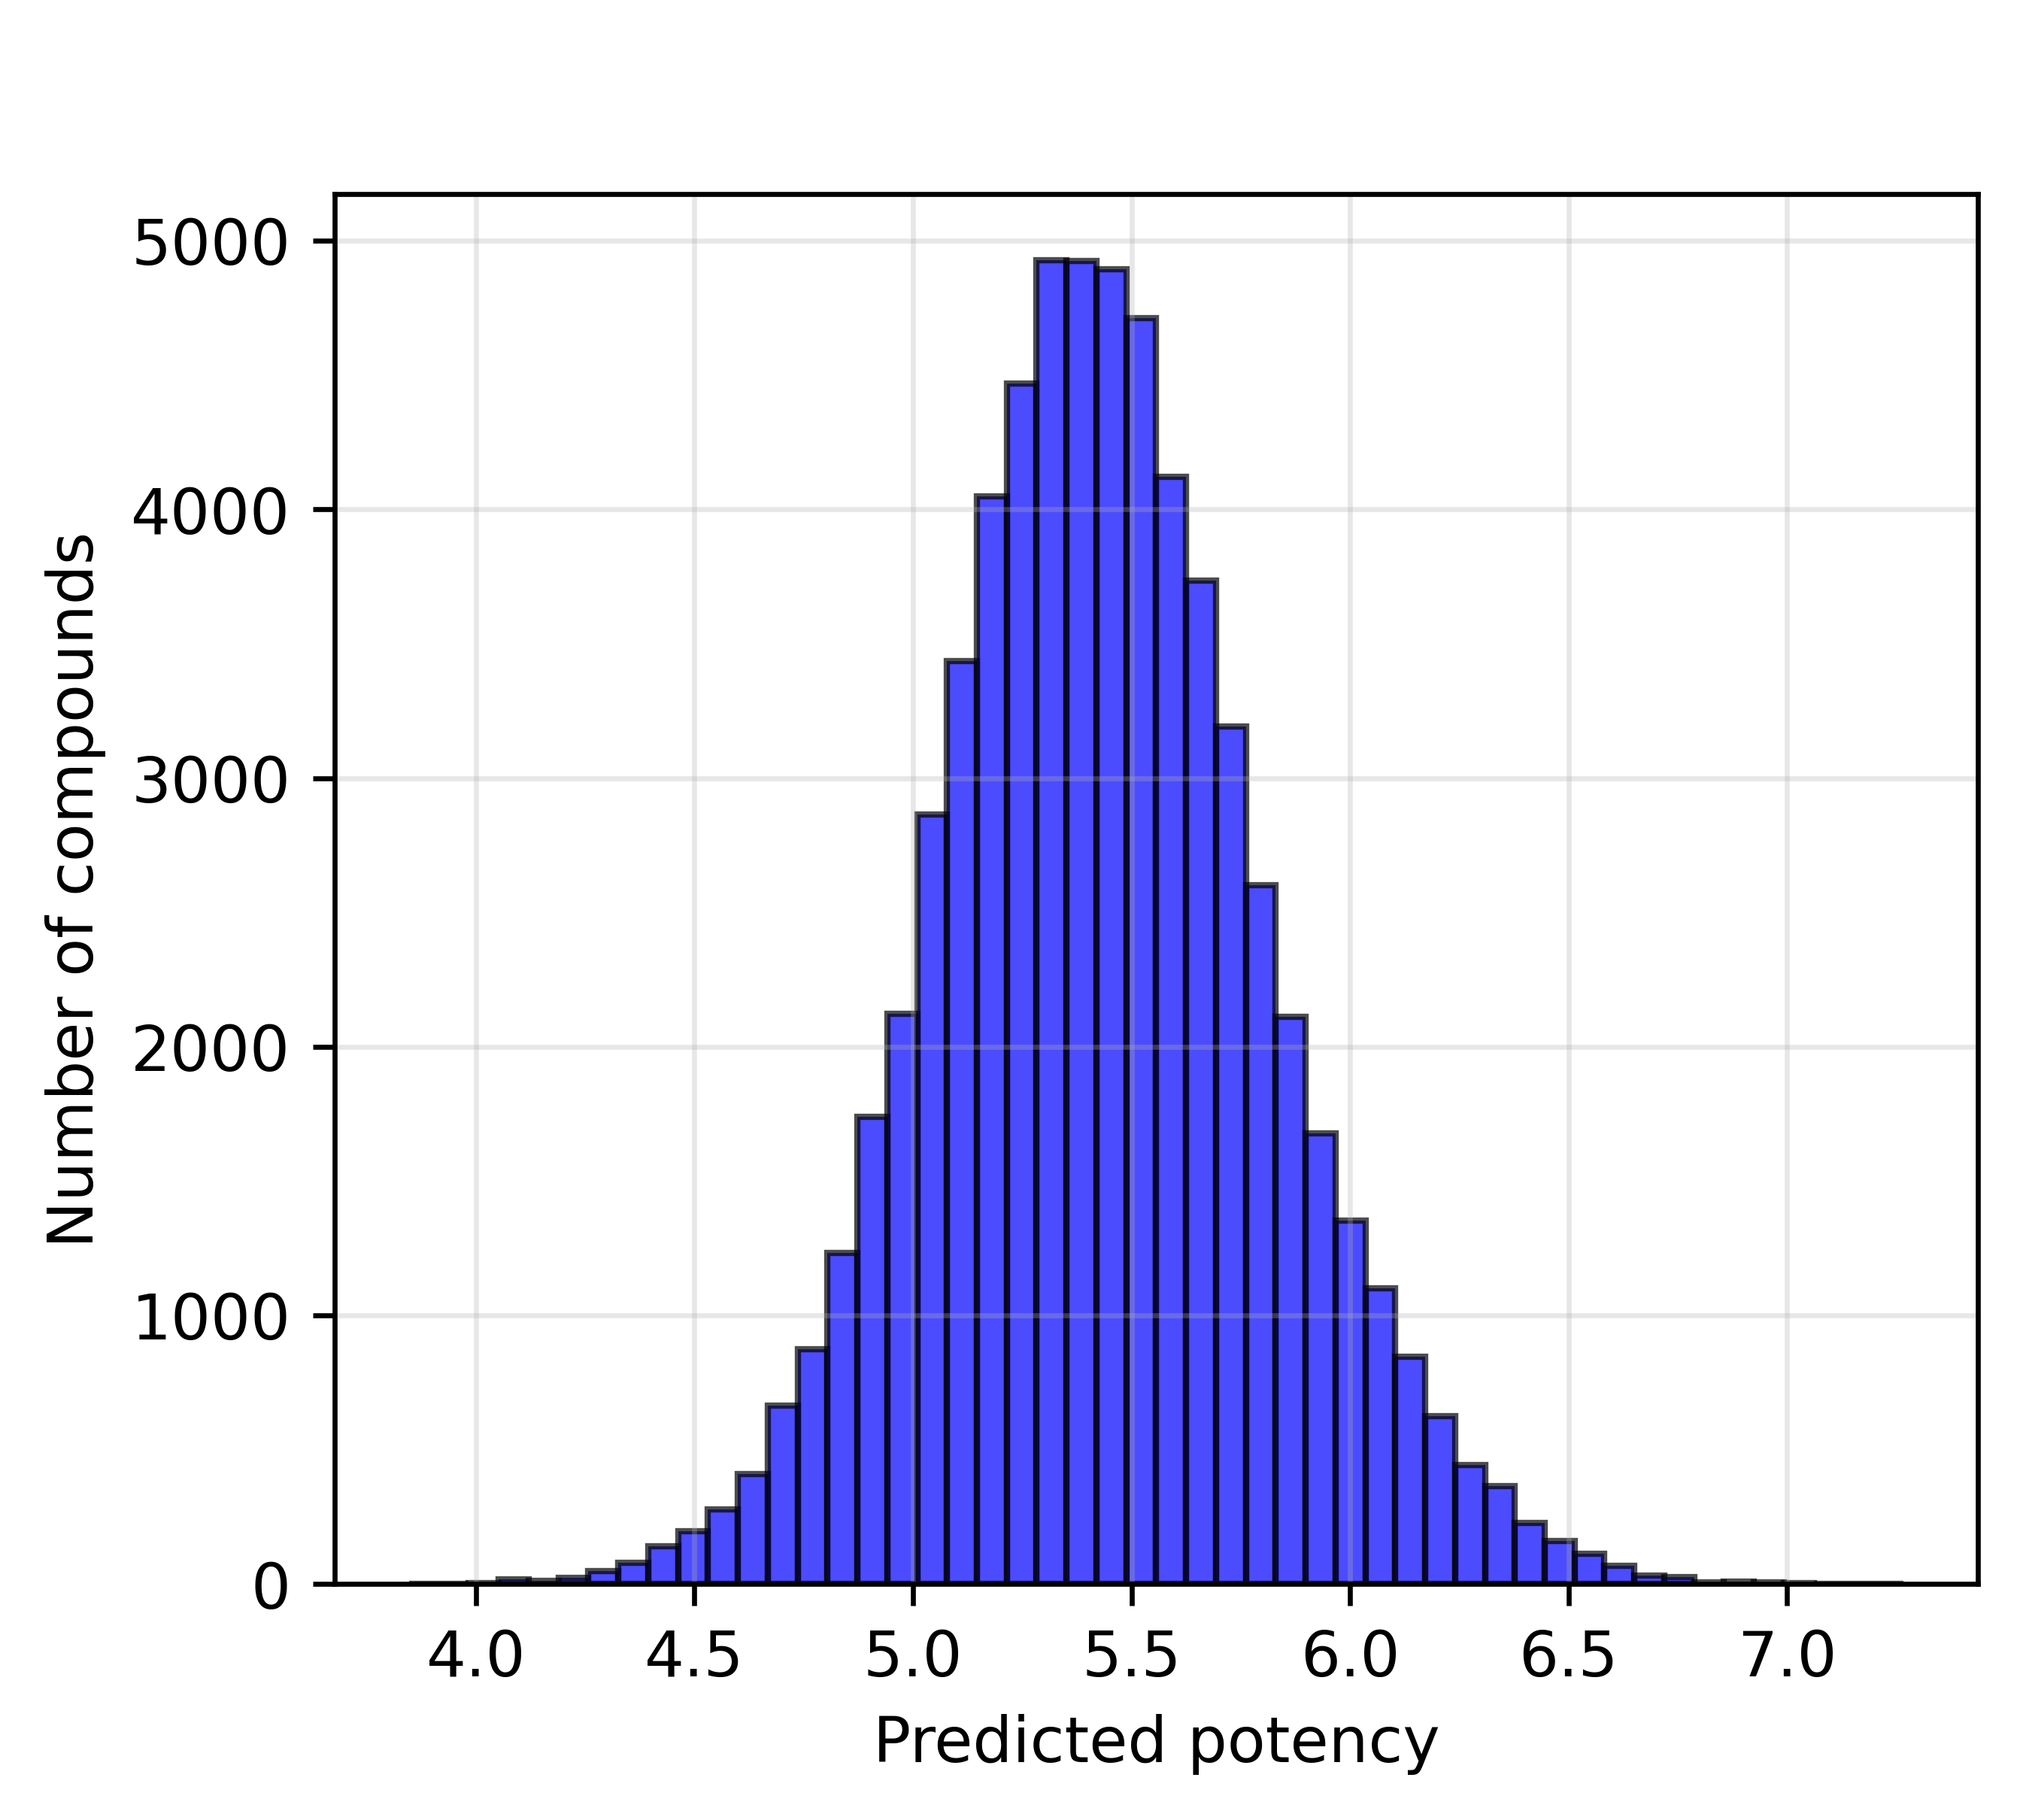

In [154]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + 'allvirus_noDuplicates_noDuplicates_validation_ChemDivDatasets.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + 'allvirus_noDuplicates_noDuplicates_validation_ChemDivDatasets.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [155]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7.0)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 6 compounds
Medium priority (6 ≤ pPotency < 7.0): 4730 compounds
Low priority (5 ≤ pPotency < 6): 52674 compounds


In [156]:
ChemDivAntiviralsData_final = ChemDivAntiviralsData.iloc[idx].copy()
ChemDivAntiviralsData_final['pPotency_prediction'] = Y1_lib_pred[idx]
ChemDivAntiviralsData_final = ChemDivAntiviralsData_final.filter(
    items=["SMILES", "pPotency_prediction", "clogP"]
)
ChemDivAntiviralsData_final

,SMILES,pPotency_prediction
8566,CCOc1ccc(CNc2ccc3c(c2)ncn3-c2ccc(C)cc2)cc1,7.018
8876,COC(=O)C1=C(N)N(c2ccc(F)cc2)C2=C(C(=O)CCC2)C1c...,7.266
8894,COC(=O)C1=C(N)N(c2ccc(Br)cc2)C2=C(C(=O)CCC2)C1...,7.015
15662,Cc1nc(Nc2ccc(OC(C)C)cc2)cc(-c2ccccc2)n1,7.131
51113,O=C1c2[nH]nc(-c3ccccc3)c2C(c2ccc(Cl)cc2)N1c1cc...,7.101
54461,COc1ccc(C2=NCC(=O)N(Cc3cc(C)ccc3C)c3sc4c(c32)C...,7.085


Top 20 compounds with higher pPotency

In [157]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 6.86
Highest predicted pPotency: 7.27
Range of top 20: 6.86 - 7.27


In [158]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
ChemDivAntiviralsData_top20 = ChemDivAntiviralsData.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
ChemDivAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
ChemDivAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
ChemDivAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
ChemDivAntiviralsData_top20 = ChemDivAntiviralsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
ChemDivAntiviralsData_top20

----------------------------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
----------------------------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    6.862
  IC50:        1.375e-07 M  (137.47 nM)

Best Values (1st ranked compound):
  pPotency:    7.266
  IC50:        5.419e-08 M  (54.19 nM)
Range for Top 20 Compounds:
pPotency Range:  6.862 - 7.266

IC50 Range (M):  1.375e-07 - 5.419e-08


,Rank,SMILES,pPotency_prediction,IC50 (M)
8876,1,COC(=O)C1=C(N)N(c2ccc(F)cc2)C2=C(C(=O)CCC2)C1c...,7.266,5.419e-08
15662,2,Cc1nc(Nc2ccc(OC(C)C)cc2)cc(-c2ccccc2)n1,7.131,7.396e-08
51113,3,O=C1c2[nH]nc(-c3ccccc3)c2C(c2ccc(Cl)cc2)N1c1cc...,7.101,7.933e-08
54461,4,COc1ccc(C2=NCC(=O)N(Cc3cc(C)ccc3C)c3sc4c(c32)C...,7.085,8.214e-08
8566,5,CCOc1ccc(CNc2ccc3c(c2)ncn3-c2ccc(C)cc2)cc1,7.018,9.587e-08
8894,6,COC(=O)C1=C(N)N(c2ccc(Br)cc2)C2=C(C(=O)CCC2)C1...,7.015,9.669e-08
8848,7,CCOC(=O)C1=C(N)N(c2ccc(C)cc2)C2=C(C(=O)CC(C)(C...,6.997,1.007e-07
8788,8,CCOC(=O)C1=C(N)N(c2ccc(Cl)cc2)C2=C(C(=O)CC(C)(...,6.988,1.028e-07
13107,9,CC(Oc1ccccc1)C(=O)Nc1nnc(S(=O)(=O)Nc2ccccc2)s1,6.975,1.059e-07
8895,10,COC(=O)C1=C(N)N(c2ccc(Cl)cc2)C2=C(C(=O)CCC2)C1...,6.965,1.083e-07


In [159]:
ChemDivAntiviralsData_top20.to_csv(os.path.join(resultsDir + "virus/allvirus_noDuplicates_ChemDivAntiviralsData_top20.csv"), index=False)
ChemDivAntiviralsData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "virus/allvirus_noDuplicates_ChemDivAntiviralsData_top20_SMILES.csv"), index=False)

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/virus/allVirus_noDuplicates_predictedCompounds_ChemDivDataset.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/virus/allVirus_noDuplicates_predictedCompounds_ChemDivDataset.svg


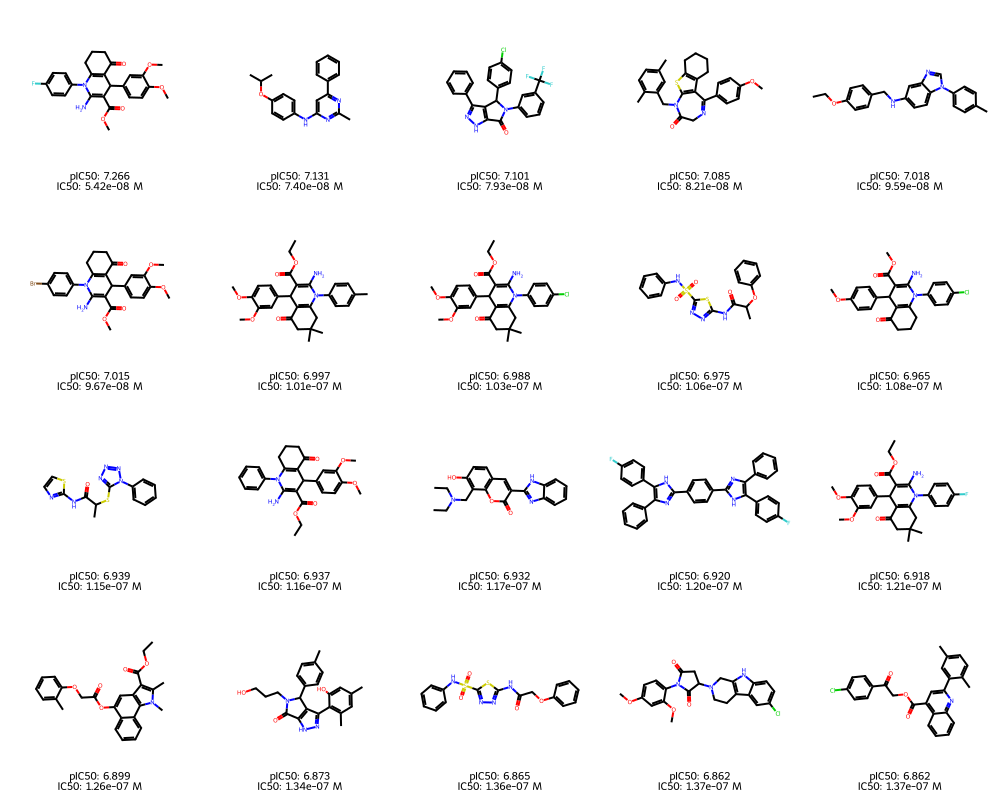

In [160]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image

# Setup paths
output_dir = saveDir + ''
os.makedirs(output_dir, exist_ok=True)

# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in ChemDivAntiviralsData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in ChemDivAntiviralsData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = output_dir + 'allVirus_noDuplicates_predictedCompounds_ChemDivDataset.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = output_dir + 'allVirus_noDuplicates_predictedCompounds_ChemDivDataset.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

### 2.4 Discovery of new hits specific to all viruses (data source SMACC Antivirals data set)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library compiled from commercial catalogs by Life chemicals. In particular, we are interested in molecules with high predicted pPotency.

In [161]:
SMACCAntiviralsData = pd.read_csv(modelBuildingDataDir + "SMACCAntiviralsData_clean.csv")

# Check for duplicates
dup_check = SMACCAntiviralsData.groupby('SMILES')['pIC50'].agg(['count', 'median', 'std'])
duplicates = dup_check[dup_check['count'] > 1]
print(f"Original SMACC data shape: {SMACCAntiviralsData.shape}, with Duplicate SMILES: {len(duplicates)}")

# Take median pIC50 for duplicates
SMACCAntiviralsData = SMACCAntiviralsData.groupby('SMILES').agg({
    'Molecule ChEMBL ID': 'first',
    'pIC50': 'median',  # Use median instead of mean
    'Virus': 'first'
}).reset_index()

print(f"After removing internal duplicates: {SMACCAntiviralsData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")
# Add canonical SMILES column to SMACC data (reusing canonical_train from previous code)
SMACCAntiviralsData['Canonical_SMILES'] = SMACCAntiviralsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~SMACCAntiviralsData['Canonical_SMILES'].isin(canonical_train)
SMACCAntiviralsData_filtered = SMACCAntiviralsData[mask].copy()

# Remove the helper column if you don't need it
SMACCAntiviralsData = SMACCAntiviralsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered SMACC data shape for validation: {SMACCAntiviralsData.shape}")
print(f"Removed {SMACCAntiviralsData_filtered.shape[0] - SMACCAntiviralsData.shape[0]} duplicate compounds from SMACC data set")
SMACCAntiviralsData = SMACCAntiviralsData.rename(columns={'pIC50': 'pIC50_experimental'})

smi_lib = SMACCAntiviralsData.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
SMACCAntiviralsData.head()

Original SMACC data shape: (1923, 5), with Duplicate SMILES: 197
After removing internal duplicates: (1612, 4)
Number of unique SMILES in training set: 2484
Filtered SMACC data shape for validation: (1602, 4)
Removed 0 duplicate compounds from SMACC data set
Total compounds to screen: 1602


,SMILES,Molecule ChEMBL ID,pIC50_experimental,Virus
0,Brc1ccc(NC(=O)CC2Sc3ncnn3C2=O)cc1,CHEMBL243652,5.690,SARS-CoV-2
1,Brc1ccc(Oc2ccc3NS(=O)(=O)C=C(OC(=O)c4ccccc4)c3...,CHEMBL4284511,5.328,Dengue
2,Brc1ccc(cc1)C1C2=C(NC(=S)NC2=O)OC2=C1C(=O)NC(=...,CHEMBL1402117,4.132,Dengue
3,Brc1ccc2C(=O)C(=O)C=Cc2c1,CHEMBL4303595,7.097,SARS-CoV-2
4,Brc1ccc2NC(=O)C(=C3SC(=S)N(NS(=O)(=O)c4ccccc4)...,CHEMBL1361582,4.627,Dengue


In [162]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

In [163]:
SMACCAntiviralsData_predicted = SMACCAntiviralsData.copy()
SMACCAntiviralsData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
SMACCAntiviralsData_predicted['IC50(M)_experimental'] = 10 ** (-SMACCAntiviralsData_predicted['pIC50_experimental'])
SMACCAntiviralsData_predicted['pPotency(M)_prediction'] = 10 ** (-SMACCAntiviralsData_predicted['pPotency_prediction'])

SMACCAntiviralsData_predicted = SMACCAntiviralsData_predicted.filter(
    items=["SMILES", "Virus", "pIC50_experimental", "pPotency_prediction",  "IC50(M)_experimental", "pPotency(M)_prediction"]
)
SMACCAntiviralsData_predicted

,SMILES,Virus,pIC50_experimental,pPotency_prediction,IC50(M)_experimental,pPotency(M)_prediction
0,Brc1ccc(NC(=O)CC2Sc3ncnn3C2=O)cc1,SARS-CoV-2,5.690,5.923,2.040e-06,1.195e-06
1,Brc1ccc(Oc2ccc3NS(=O)(=O)C=C(OC(=O)c4ccccc4)c3...,Dengue,5.328,5.592,4.700e-06,2.559e-06
2,Brc1ccc(cc1)C1C2=C(NC(=S)NC2=O)OC2=C1C(=O)NC(=...,Dengue,4.132,6.170,7.371e-05,6.761e-07
3,Brc1ccc2C(=O)C(=O)C=Cc2c1,SARS-CoV-2,7.097,4.435,8.000e-08,3.671e-05
4,Brc1ccc2NC(=O)C(=C3SC(=S)N(NS(=O)(=O)c4ccccc4)...,Dengue,4.627,4.955,2.359e-05,1.110e-05
...,...,...,...,...,...,...
1607,S=C1NN=C(Nc2ccccc2)S1,SARS-CoV-2,6.409,5.333,3.900e-07,4.644e-06
1608,S=C1Nc2ccccc2S1,SARS-CoV-2,5.759,4.603,1.740e-06,2.494e-05
1609,SC(=S)N1CCCC1,SARS-CoV-2,6.678,5.702,2.100e-07,1.985e-06
1610,c1coc(c1)-c1nc2ccccc2nc1-c1ccco1,Dengue,4.000,5.208,1.000e-04,6.192e-06


In [164]:
SMACCAntiviralsData_predicted.to_csv(os.path.join(resultsDir + "virus/Ebolavirus_SMACCAntiviralsData_predicted_all.csv"), index=False)
SMACCAntiviralsData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "virus/Ebolavirus_SMACCAntiviralsData_predicted_all_SMILES.csv"), index=False)

### Plot the error between `experimental_pPotency` and `predicted_pPotency`

Mean Residual: 0.596
Std Dev of Residuals: 1.121
Min Residual: -4.609
Max Residual: 3.000


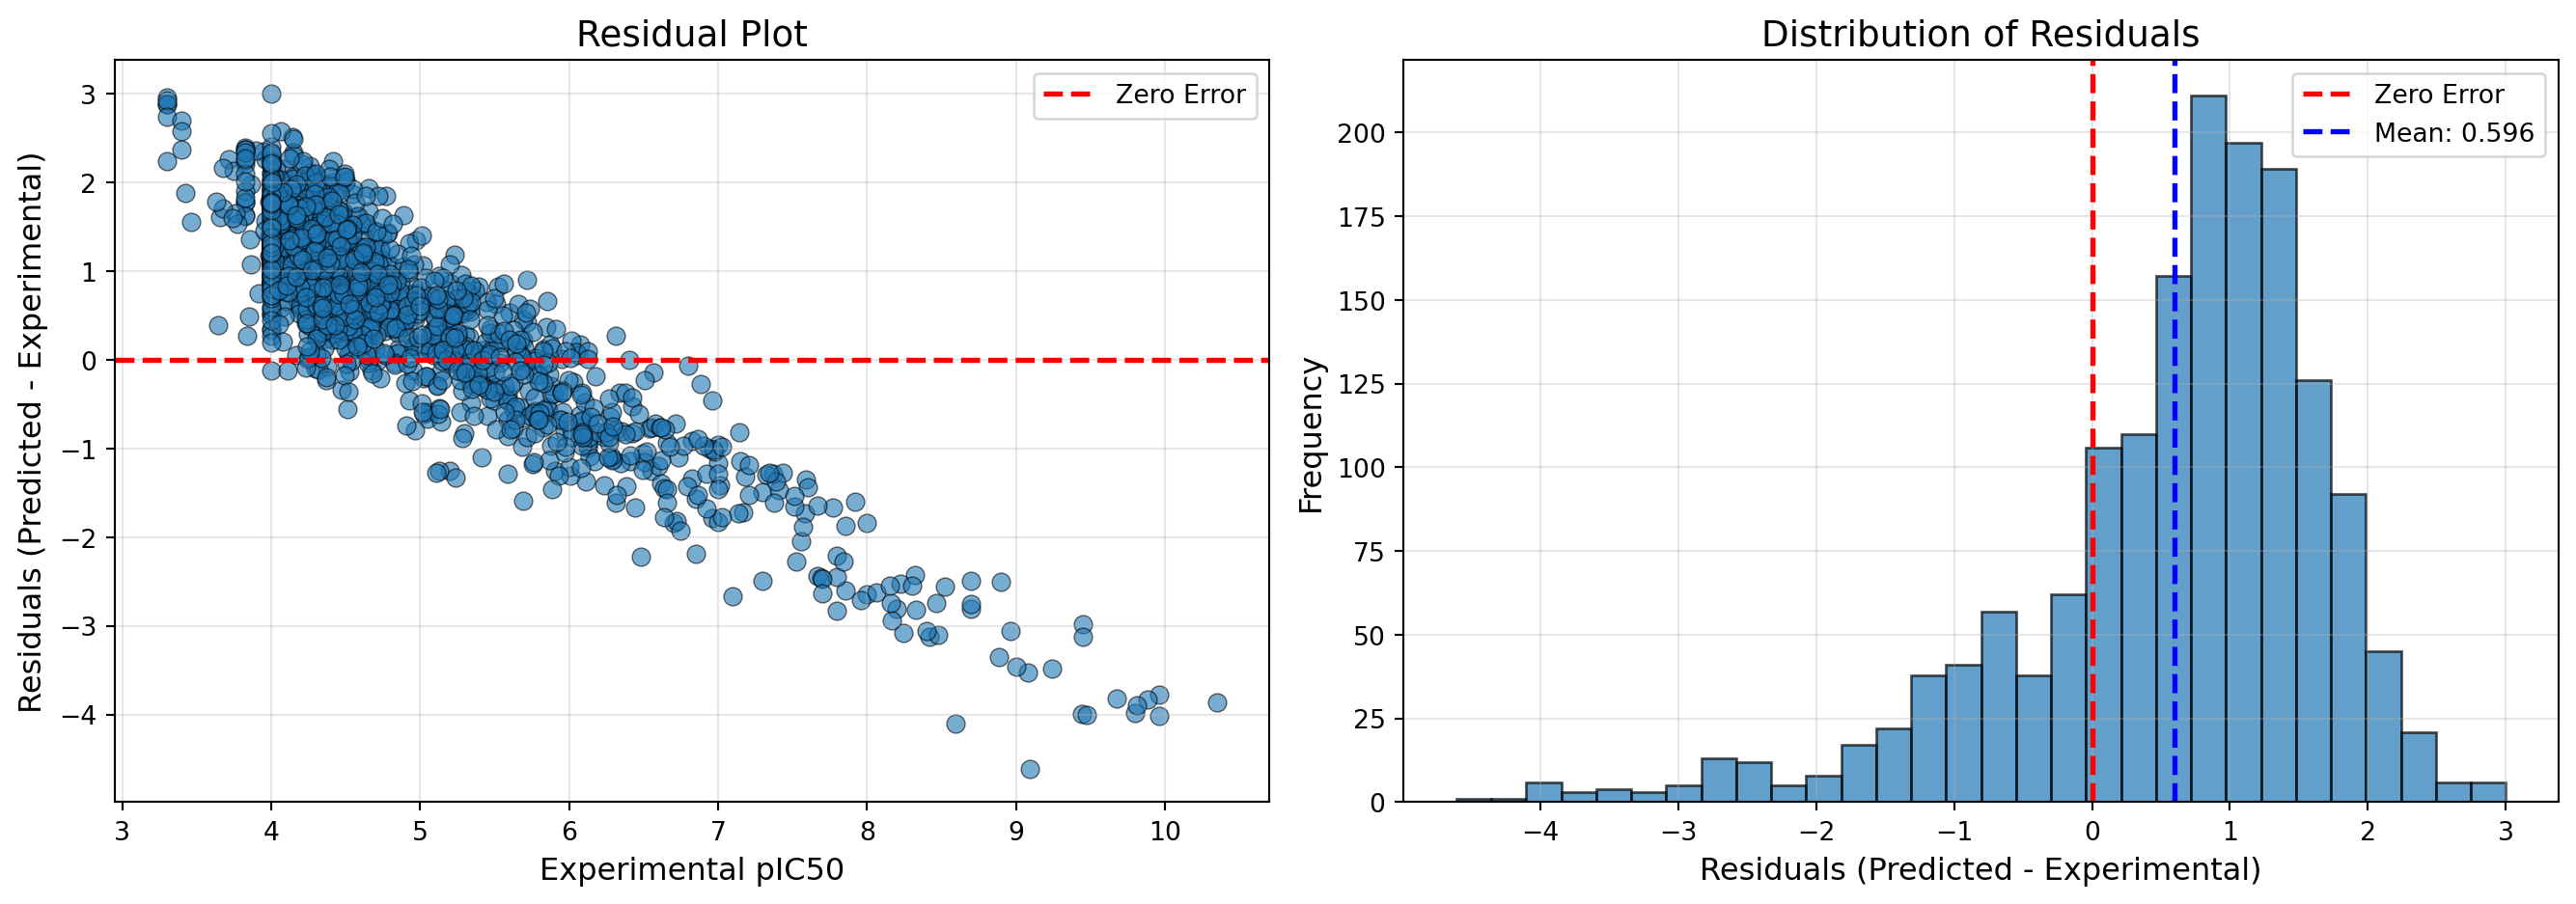

In [165]:
# Calculate residuals (difference)
SMACCAntiviralsData_predicted['residuals'] = (
    SMACCAntiviralsData_predicted['pPotency_prediction'] - 
    SMACCAntiviralsData_predicted['pIC50_experimental']
)

# Print statistics
print(f"Mean Residual: {SMACCAntiviralsData_predicted['residuals'].mean():.3f}")
print(f"Std Dev of Residuals: {SMACCAntiviralsData_predicted['residuals'].std():.3f}")
print(f"Min Residual: {SMACCAntiviralsData_predicted['residuals'].min():.3f}")
print(f"Max Residual: {SMACCAntiviralsData_predicted['residuals'].max():.3f}")

# Create residual plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Residuals vs Experimental values
axes[0].scatter(SMACCAntiviralsData_predicted['pIC50_experimental'], 
                SMACCAntiviralsData_predicted['residuals'], 
                alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[0].set_xlabel('Experimental pIC50', fontsize=12)
axes[0].set_ylabel('Residuals (Predicted - Experimental)', fontsize=12)
axes[0].set_title('Residual Plot', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Distribution of residuals
axes[1].hist(SMACCAntiviralsData_predicted['residuals'], bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[1].axvline(x=SMACCAntiviralsData_predicted['residuals'].mean(), 
                color='blue', linestyle='--', linewidth=2, 
                label=f'Mean: {SMACCAntiviralsData_predicted["residuals"].mean():.3f}')
axes[1].set_xlabel('Residuals (Predicted - Experimental)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Residuals', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Residual Plot Analysis

In [166]:
print(f"Mean residual: {SMACCAntiviralsData_predicted['residuals'].mean():.3f} (Close to 0 indicates no systematic bias)")
print(f"Std deviation: {SMACCAntiviralsData_predicted['residuals'].std():.3f} (typical prediction error)")
print(f"95% of predictions are within ±{1.96 * SMACCAntiviralsData_predicted['residuals'].std():.3f} pIC50 units")

Mean residual: 0.596 (Close to 0 indicates no systematic bias)
Std deviation: 1.121 (typical prediction error)
95% of predictions are within ±2.197 pIC50 units


Let us have a look at the compounds:

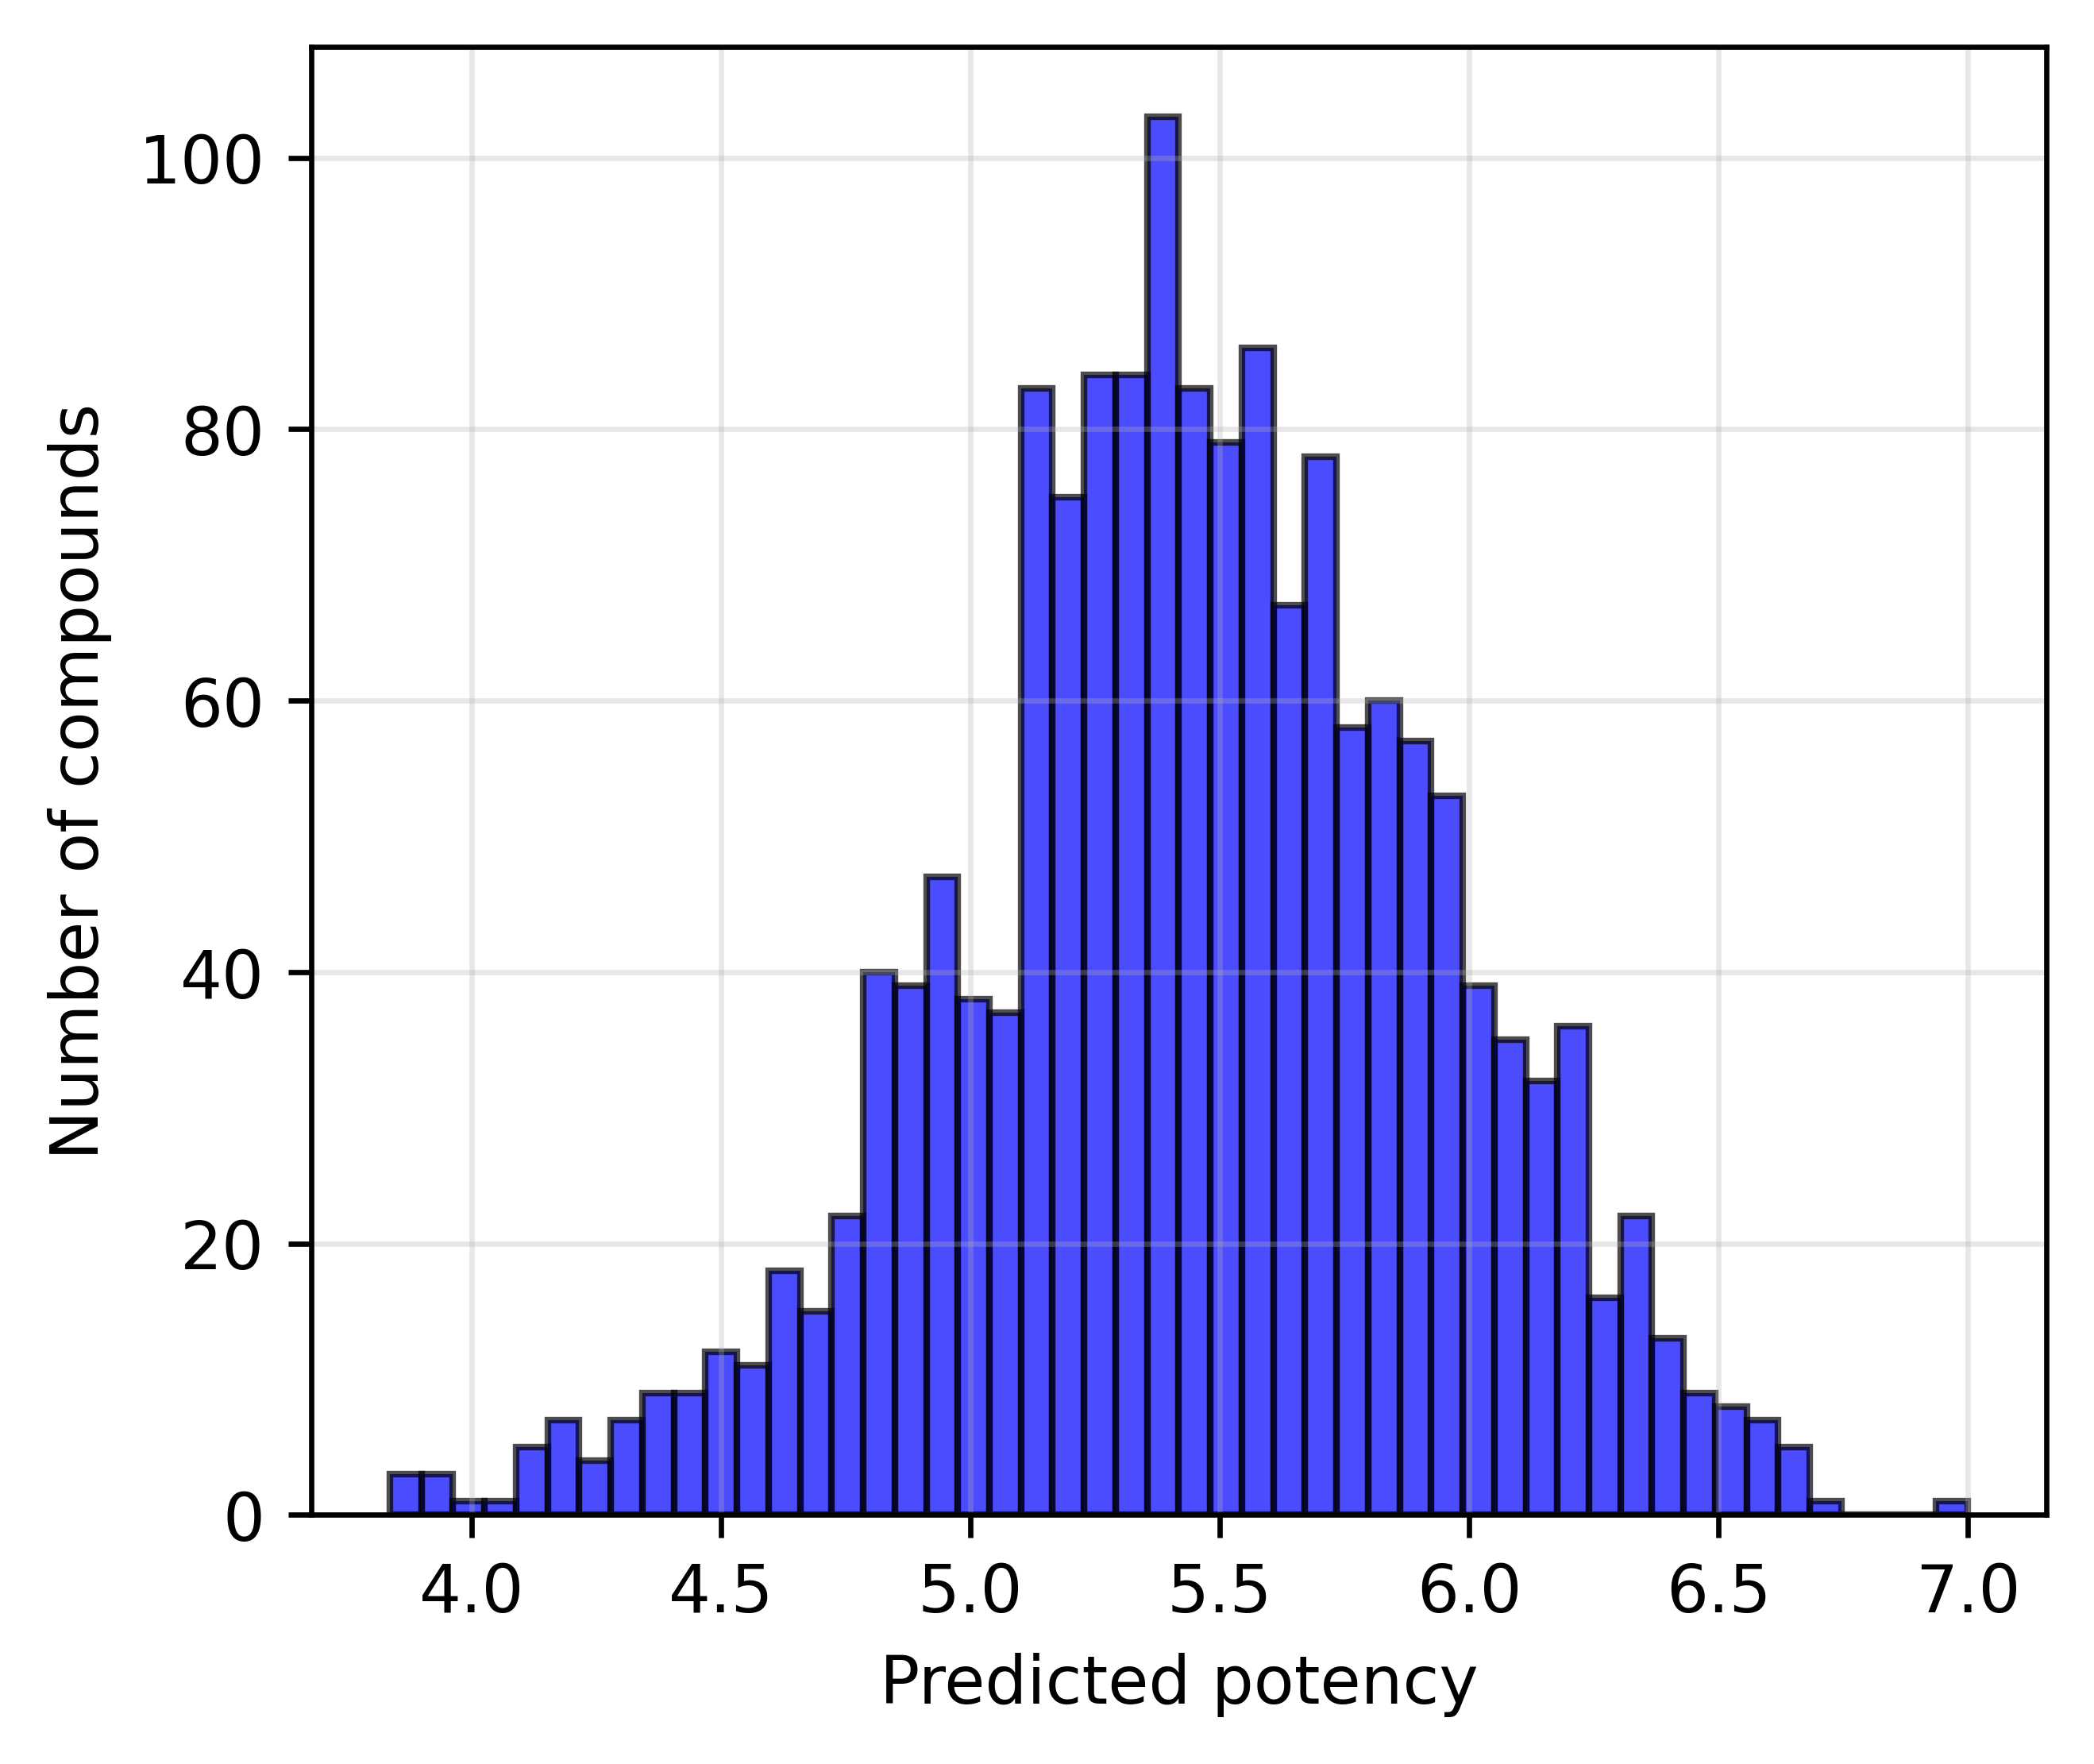

In [167]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + 'allvirus_noDuplicates_validation_SMACCDatasets.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + 'allvirus_noDuplicates_validation_SMACCDatasets.png', bbox_inches='tight', dpi=300)
plt.show()

In [168]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 0 compounds
Medium priority (6 ≤ pPotency < 7.0): 217 compounds
Low priority (5 ≤ pPotency < 6): 1121 compounds


Top 20 compounds with higher pPotency

In [169]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 6.51
Highest predicted pPotency: 7.00
Range of top 20: 6.51 - 7.00


In [170]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
SMACCAntiviralsData_top20 = SMACCAntiviralsData_predicted.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
SMACCAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
SMACCAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
SMACCAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'


SMACCAntiviralsData_top20

----------------------------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
----------------------------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    6.512
  IC50:        3.075e-07 M  (307.53 nM)

Best Values (1st ranked compound):
  pPotency:    7.000
  IC50:        1.001e-07 M  (100.06 nM)
Range for Top 20 Compounds:
pPotency Range:  6.512 - 7.000

IC50 Range (M):  3.075e-07 - 1.001e-07


,Rank,SMILES,Virus,pIC50_experimental,pPotency_prediction,IC50(M)_experimental,pPotency(M)_prediction,residuals,IC50 (M)
1380,1,OC(=O)c1cc(c(Sc2nc3ccccc3[nH]2)c(c1)N(=O)=O)N(...,Dengue,4.000,7.000,1.000e-04,1.001e-07,3.000,1.001e-07
1606,2,S(Sc1nc2ccccc2s1)c1nc2ccccc2s1,SARS-CoV-2,6.796,6.733,1.600e-07,1.849e-07,-0.063,1.849e-07
83,3,CC(C)CC(NC(=O)CC1=C(C)c2cc3c(C)c(C)oc3c(C)c2OC...,Dengue,4.139,6.650,7.259e-05,2.238e-07,2.511,2.238e-07
711,4,COc1cccc(C(C2=C(C)NN(C2=O)c2ccccc2)C2=C(C)NN(C...,Dengue,4.411,6.648,3.883e-05,2.249e-07,2.237,2.249e-07
1187,5,Nc1c(sc2nc(cc(-c3ccc(Cl)cc3)c12)-c1ccccc1)C(O)=O,Dengue,4.150,6.645,7.075e-05,2.263e-07,2.495,2.263e-07
170,6,CC1=C(C(C(C#N)C#N)c2ccccc2N(=O)=O)C(=O)N(N1)c1...,Dengue,4.063,6.642,8.641e-05,2.282e-07,2.578,2.282e-07
98,7,CC(C)OC(=O)C(C)NP(=O)(OCC1OC(N2C=CC(=O)NC2=O)C...,Zika,5.715,6.623,1.926e-06,2.381e-07,0.908,2.381e-07
600,8,COc1cc(Cl)cc(C(c2c([nH]c3ccccc23)C(O)=O)c2c([n...,Dengue,4.771,6.620,1.693e-05,2.400e-07,1.848,2.400e-07
1119,9,NCCCCC(NC(=O)C(CCCCN)NC(=O)Cc1ccc(Cl)c(Cl)c1)C...,West_Nile,6.886,6.612,1.300e-07,2.443e-07,-0.274,2.443e-07
1277,10,O=C1ON=C(C1=Cc1ccc(OS(=O)(=O)c2ccccc2)cc1)c1cc...,Dengue,4.491,6.593,3.228e-05,2.555e-07,2.102,2.555e-07


In [171]:
SMACCAntiviralsData_top20.to_csv(os.path.join(resultsDir + "virus/allvirus_noDuplicatesvirus_SMACCAntiviralsData_top20.csv"), index=False)
SMACCAntiviralsData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "virus/allvirus_noDuplicatesvirus_SMACCAntiviralsData_top20_SMILES.csv"), index=False)

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/virus/allVirus_noDuplicates_predictedCompounds_SMACCDataset.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/virus/allVirus_noDuplicates_predictedCompounds_SMACCDataset.svg


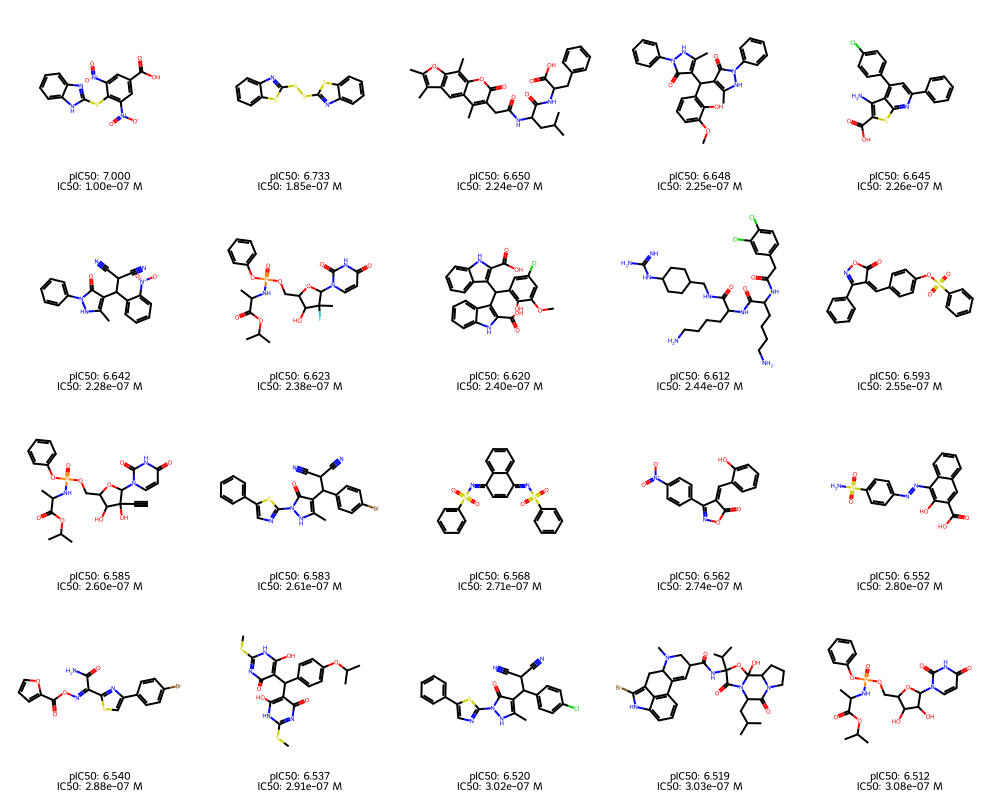

In [172]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image

# Setup paths
output_dir = saveDir + ''
os.makedirs(output_dir, exist_ok=True)

# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in SMACCAntiviralsData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in SMACCAntiviralsData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = output_dir + 'allVirus_noDuplicates_predictedCompounds_SMACCDataset.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = output_dir + 'allVirus_noDuplicates_predictedCompounds_SMACCDataset.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

### Checking drug likeliness of `Remdesivir` and `Molnupiravir`

In [175]:
Remdesivir_SMILES_file = os.path.join(dataDir + "/target_SMILES/Remdesivir_structure.mol")
Molnupiravir_SMILES_file = os.path.join(dataDir + "/target_SMILES/Molnupiravir_structure.mol")

In [182]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
import pandas as pd

# SMILES strings
Remdesivir_SMILES = 'CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](C#N)([C@H](O)[C@@H]1O)C1=CC=C2N1N=CN=C2N)OC1=CC=CC=C1'
Molnupiravir_SMILES = 'CC(C)C(=O)OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=C\C(NC1=O)=N\O'

# Dictionary of drugs and their SMILES
drugs = {
    'Remdesivir': Remdesivir_SMILES,
    'Molnupiravir': Molnupiravir_SMILES
}

# List to store results
smiles_data = []

# Process each drug
for drug_name, smiles in drugs.items():
    # Convert SMILES to molecule object
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is not None:
        smiles_data.append({
            'Drug_Name': drug_name,
            'SMILES': smiles,
            'Molecular_Formula': rdMolDescriptors.CalcMolFormula(mol),
            'Molecular_Weight': round(Descriptors.MolWt(mol), 2)
        })
        print(f" {drug_name}")
        print(f"  Formula: {rdMolDescriptors.CalcMolFormula(mol)}")
        print(f"  MW: {round(Descriptors.MolWt(mol), 2)} g/mol")
    else:
        print(f" Failed to parse SMILES for {drug_name}")

# Create DataFrame
DTRA_target_SMILES = pd.DataFrame(smiles_data)
DTRA_target_SMILES

 Remdesivir
  Formula: C27H35N6O8P
  MW: 602.59 g/mol
 Molnupiravir
  Formula: C13H19N3O7
  MW: 329.31 g/mol


,Drug_Name,SMILES,Molecular_Formula,Molecular_Weight
0,Remdesivir,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](...,C27H35N6O8P,602.590
1,Molnupiravir,CC(C)C(=O)OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=...,C13H19N3O7,329.310


In [183]:
# Canonicalize training SMILES and create a set for fast lookup
canonical_train = set()
for smi in smiles_train:
    canonical_smi = canonicalize_smiles(smi)
    if canonical_smi is not None:
        canonical_train.add(canonical_smi)

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to DTRA target data
DTRA_target_SMILES['Canonical_SMILES'] = DTRA_target_SMILES['SMILES'].apply(canonicalize_smiles)

# ADDED: Save original count BEFORE filtering
original_count = DTRA_target_SMILES.shape[0]

# Filter out duplicates - keep only those NOT in training set
mask = ~DTRA_target_SMILES['Canonical_SMILES'].isin(canonical_train)
DTRA_target_SMILES_filtered = DTRA_target_SMILES[mask].copy()

# Remove the helper column if you don't need it
DTRA_target_SMILES = DTRA_target_SMILES_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered DTRA target data shape for validation: {DTRA_target_SMILES.shape}")
print(f"Removed {original_count - DTRA_target_SMILES.shape[0]} duplicate compounds from DTRA target data set")  # FIXED

# Now use the filtered data
smi_lib = DTRA_target_SMILES.SMILES
print(f"Total DTRA target compounds to screen: {len(smi_lib)}")

# Display the filtered data
DTRA_target_SMILES

Number of unique SMILES in training set: 2484
Filtered DTRA target data shape for validation: (1, 4)
Removed 1 duplicate compounds from DTRA target data set
Total DTRA target compounds to screen: 1


,Drug_Name,SMILES,Molecular_Formula,Molecular_Weight
1,Molnupiravir,CC(C)C(=O)OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=...,C13H19N3O7,329.310


Generate predictions

In [184]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

In [185]:
DTRA_target_SMILES_predicted = DTRA_target_SMILES.copy()
DTRA_target_SMILES_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
DTRA_target_SMILES_predicted['pPotency(M)_prediction'] = 10 ** (-DTRA_target_SMILES_predicted['pPotency_prediction'])

DTRA_target_SMILES_predicted = DTRA_target_SMILES_predicted.filter(
    items=["SMILES", "pPotency_prediction",  "pPotency(M)_prediction"]
)
DTRA_target_SMILES_predicted.to_csv(os.path.join(resultsDir + "virus/allvirus_noDuplicates_DTRAtargets_predicted_all.csv"), index=False)
DTRA_target_SMILES_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "virus/allvirus_noDuplicates_DTRAtargets_predicted_all_SMILES.csv"), index=False)
DTRA_target_SMILES_predicted

,SMILES,pPotency_prediction,pPotency(M)_prediction
1,CC(C)C(=O)OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=...,5.241,5.736e-06


### Checking efficiency of `Remdesivir` as a antiviral, it present in training data set

In [202]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
import pandas as pd

# SMILES strings
Remdesivir_SMILES = 'CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](C#N)([C@H](O)[C@@H]1O)C1=CC=C2N1N=CN=C2N)OC1=CC=CC=C1'

# Dictionary of drugs and their SMILES
drugs = {
    'Remdesivir': Remdesivir_SMILES,
}

# List to store results
smiles_data = []

# Process each drug
for drug_name, smiles in drugs.items():
    # Convert SMILES to molecule object
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is not None:
        smiles_data.append({
            'Drug_Name': drug_name,
            'SMILES': smiles,
            'Molecular_Formula': rdMolDescriptors.CalcMolFormula(mol),
            'Molecular_Weight': round(Descriptors.MolWt(mol), 2)
        })
        print(f" {drug_name}")
        print(f"  Formula: {rdMolDescriptors.CalcMolFormula(mol)}")
        print(f"  MW: {round(Descriptors.MolWt(mol), 2)} g/mol")
    else:
        print(f" Failed to parse SMILES for {drug_name}")

# Create DataFrame
DTRA_target_SMILES = pd.DataFrame(smiles_data)
DTRA_target_SMILES

 Remdesivir
  Formula: C27H35N6O8P
  MW: 602.59 g/mol


,Drug_Name,SMILES,Molecular_Formula,Molecular_Weight
0,Remdesivir,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](...,C27H35N6O8P,602.590


Find experimental pPotency value for `Remdesivir`

In [203]:
# Function to canonicalize SMILES
def canonicalize_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        return Chem.MolToSmiles(mol, canonical=True) if mol else None
    except:
        return None

# Create mappings from allVirusData (without modifying it)
canonical_smiles = allVirusData_chEMBL['Smiles'].apply(canonicalize_smiles)
smiles_to_pPotency = dict(zip(canonical_smiles, allVirusData_chEMBL['pPotency']))
smiles_to_virus = dict(zip(canonical_smiles, allVirusData_chEMBL['VirusClassifier']))

# Add columns to DTRA_target_SMILES
DTRA_target_SMILES['pIC50_experimental'] = DTRA_target_SMILES['SMILES'].apply(
    lambda x: smiles_to_pPotency.get(canonicalize_smiles(x), None)
)
DTRA_target_SMILES['VirusClassifier'] = DTRA_target_SMILES['SMILES'].apply(
    lambda x: smiles_to_virus.get(canonicalize_smiles(x), None)
)

# Display
print(f"Compounds with experimental data: {DTRA_target_SMILES['pIC50_experimental'].notna().sum()}")
DTRA_target_SMILES

Compounds with experimental data: 1


,Drug_Name,SMILES,Molecular_Formula,Molecular_Weight,pIC50_experimental,VirusClassifier
0,Remdesivir,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](...,C27H35N6O8P,602.590,7.161,SARS-CoV


In [204]:
# Now use the filtered data
smi_lib = DTRA_target_SMILES.SMILES
print(f"Total DTRA target compounds to screen: {len(smi_lib)}")

Total DTRA target compounds to screen: 1


Generate predictions

In [205]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

In [207]:
DTRA_target_SMILES_predicted = DTRA_target_SMILES.copy()
DTRA_target_SMILES_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
DTRA_target_SMILES_predicted['IC50(M)_experimental'] = 10 ** (-DTRA_target_SMILES_predicted['pIC50_experimental'])
DTRA_target_SMILES_predicted['pPotency(M)_prediction'] = 10 ** (-DTRA_target_SMILES_predicted['pPotency_prediction'])

DTRA_target_SMILES_predicted = DTRA_target_SMILES_predicted.filter(
    items=["SMILES", "VirusClassifier", "pIC50_experimental", "pPotency_prediction",  "IC50(M)_experimental", "pPotency(M)_prediction"]
)
DTRA_target_SMILES_predicted

,SMILES,VirusClassifier,pIC50_experimental,pPotency_prediction,IC50(M)_experimental,pPotency(M)_prediction
0,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](...,SARS-CoV,7.161,6.479,6.900e-08,3.321e-07


# Build feature matrix X and targets (regression + classification)

Train/valid split

Define the partitions for cross-validation.

Define hyperparameters for SVR:

Define MACAW embedding

Regression

### Evaluate cross validation performance

### Generate a model trained on the whole data set, to be used for prediction tasks

# Classification: Cross Validation loop

In [60]:
smiles = allVirusData_chEMBL["Smiles"].astype(str).reset_index(drop=True)
Y = allVirusData_chEMBL["pPotency"].to_numpy(dtype=np.float32)

# Ensure smiles is a pandas Series
if isinstance(smiles, np.ndarray):
    smiles = pd.Series(smiles)
if isinstance(Y, np.ndarray):
    Y = pd.Series(Y)

# Drop NaN or missing targets
validMaskY = Y.notna() & ~Y.isnull()
smiles = smiles[validMaskY].reset_index(drop=True)
Y = Y[validMaskY].reset_index(drop=True)

# Validate SMILES strings
validIdx = []
for i, s in enumerate(smiles):
    if isinstance(s, str) and len(s) > 0 and Chem.MolFromSmiles(s) is not None:
        validIdx.append(i)

smiles = smiles.iloc[validIdx].reset_index(drop=True)
Y = Y.iloc[validIdx].reset_index(drop=True)

print(f" Cleaned data has: {len(smiles)} valid samples after dropping NaN targets and invalid SMILES.")
print(f"Example indices: {Y.index[:10].tolist()}")

 Cleaned data has: 4694 valid samples after dropping NaN targets and invalid SMILES.
Example indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [61]:
num_of_partitions = 10
kf = KFold(n_splits=num_of_partitions, shuffle=True, random_state=42)

In [62]:
# For classification we use SVC with RBF; only C is tuned here (gamma='scale' default)
param_grid_cls = {
    'C': [1, 5, 7, 10, 30, 50, 100, 300, 500],
    'kernel': ['rbf']
}

### Classification with Morgan (ECFP6) + RandomForest

In [63]:
%%time

from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, balanced_accuracy_score, accuracy_score
from sklearn.preprocessing import LabelEncoder

# ---------------------------
# Helpers
# ---------------------------
def morganBits(smilesList, nBits=2048, radius=3):
    """Return (X, validMask) where X is [n_valid, nBits] uint8 array of ECFP bits."""
    fps = []
    validMask = []
    for s in smilesList:
        mol = Chem.MolFromSmiles(s) if isinstance(s, str) else None
        if mol is None:
            validMask.append(False)
            continue
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=nBits)
        arr = np.zeros((nBits,), dtype=np.uint8)
        # NOTE: RDKit DataStructs is optional here; ConvertToNumpyArray handles directly if imported.
        # To avoid extra import, we iterate bits:
        onBits = list(fp.GetOnBits())
        arr[onBits] = 1
        fps.append(arr)
        validMask.append(True)
    if len(fps) == 0:
        return np.zeros((0, nBits), dtype=np.uint8), np.array(validMask, dtype=bool)
    return np.vstack(fps), np.array(validMask, dtype=bool)

def safeInsert(df, loc, name, values):
    if name in df.columns:
        df.drop(columns=[name], inplace=True)
    df.insert(loc, name, values)

# ---------------------------
# Prepare data
# ---------------------------
DF = allVirusData_chEMBL  
assert {"Smiles", "VirusClassifier"}.issubset(DF.columns), "Expected Smiles and VirusClassifier in DF."

smilesSeries = DF["Smiles"].astype(str).reset_index(drop=True)
labelsStr = DF["VirusClassifier"].astype(str).reset_index(drop=True)

# Encode string labels to ints (for modeling), but we will report strings
labelEncoder = LabelEncoder()
yEncAll = labelEncoder.fit_transform(labelsStr)

# Compute Morgan fingerprints and filter invalids
XAllBits, validMask = morganBits(smilesSeries.tolist(), nBits=2048, radius=3)
yEncAllValid = yEncAll[validMask]
labelsStrValid = labelsStr[validMask].reset_index(drop=True)

if XAllBits.shape[0] < 10:
    raise RuntimeError(f"Too few valid molecules after featurization: {XAllBits.shape[0]}")

print(f"[Info] Valid training molecules: {XAllBits.shape[0]} / {len(smilesSeries)}")

# ---------------------------
# Nested CV (outer stratified K-fold, inner grid search)
# ---------------------------
numOfPartitions = 10
kfOuter = StratifiedKFold(n_splits=numOfPartitions, shuffle=True, random_state=42)

paramGridCls = {
    "n_estimators": [200, 400, 800],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": ["balanced"]  # handle imbalance
}

YcvPredCls, YobsCls, bestParamsPerFold = [], [], []
foldId = 1
for trainIndex, valIndex in kfOuter.split(XAllBits, yEncAllValid):
    print(f"Partition {foldId}/{kfOuter.get_n_splits()}")
    foldId += 1

    XTrain, XVal = XAllBits[trainIndex], XAllBits[valIndex]
    yTrainEnc, yValEnc = yEncAllValid[trainIndex], yEncAllValid[valIndex]
    yValStr = labelEncoder.inverse_transform(yValEnc)

    inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    gridCls = GridSearchCV(
        estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
        param_grid=paramGridCls,
        scoring="f1_macro",
        cv=inner,
        n_jobs=4,
        refit=True,
        verbose=0
    )
    gridCls.fit(XTrain, yTrainEnc)
    bestParamsPerFold.append(gridCls.best_params_)

    yPredEnc = gridCls.predict(XVal)
    yPredStr = labelEncoder.inverse_transform(yPredEnc)

    YcvPredCls.extend(yPredStr.tolist())
    YobsCls.extend(yValStr.tolist())

[Info] Valid training molecules: 4694 / 4694
Partition 1/10
Partition 2/10
Partition 3/10
Partition 4/10
Partition 5/10
Partition 6/10
Partition 7/10
Partition 8/10
Partition 9/10
Partition 10/10
CPU times: user 2min 20s, sys: 9.08 s, total: 2min 29s
Wall time: 46min 16s


### Cross Validation metrics

In [64]:
f1Cv  = f1_score(YobsCls, YcvPredCls, average="macro")
baCv  = balanced_accuracy_score(YobsCls, YcvPredCls)
accCv = accuracy_score(YobsCls, YcvPredCls)
print(f"[Nested-CV] Classification | F1-macro: {f1Cv:.3f} | Balanced Acc: {baCv:.3f} | Acc: {accCv:.3f}")
print(f"[Info] Best params (sample): {bestParamsPerFold[:3]}")

[Nested-CV] Classification | F1-macro: 0.581 | Balanced Acc: 0.723 | Acc: 0.813
[Info] Best params (sample): [{'class_weight': 'balanced', 'max_depth': 30, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 400}, {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}, {'class_weight': 'balanced', 'max_depth': 30, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 400}]


### Cross Validation Confusion Matrix

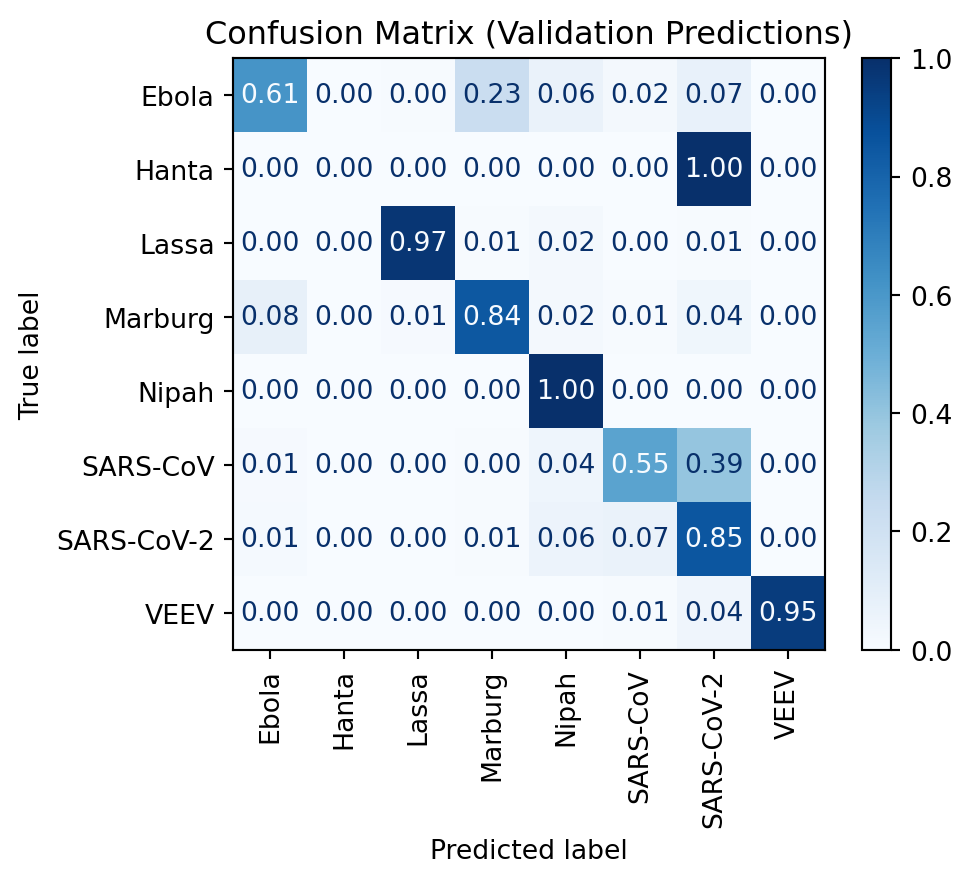

In [65]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

yTrue = YobsCls   # true labels (strings)
yPred = YcvPredCls  # predicted labels (strings)

cm = confusion_matrix(yTrue, yPred, labels=np.unique(yTrue), normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(yTrue))
disp.plot(xticks_rotation='vertical', cmap='Blues', values_format='.2f')
plt.title("Confusion Matrix (Validation Predictions)")
plt.savefig(saveDir + 'allVirus_CV_ConMat.svg', format='svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + 'allVirus_CV_ConMat.png', format='png', bbox_inches='tight', dpi=300)
plt.show()

### Cross Validation Per-class precision/recall/F1 values

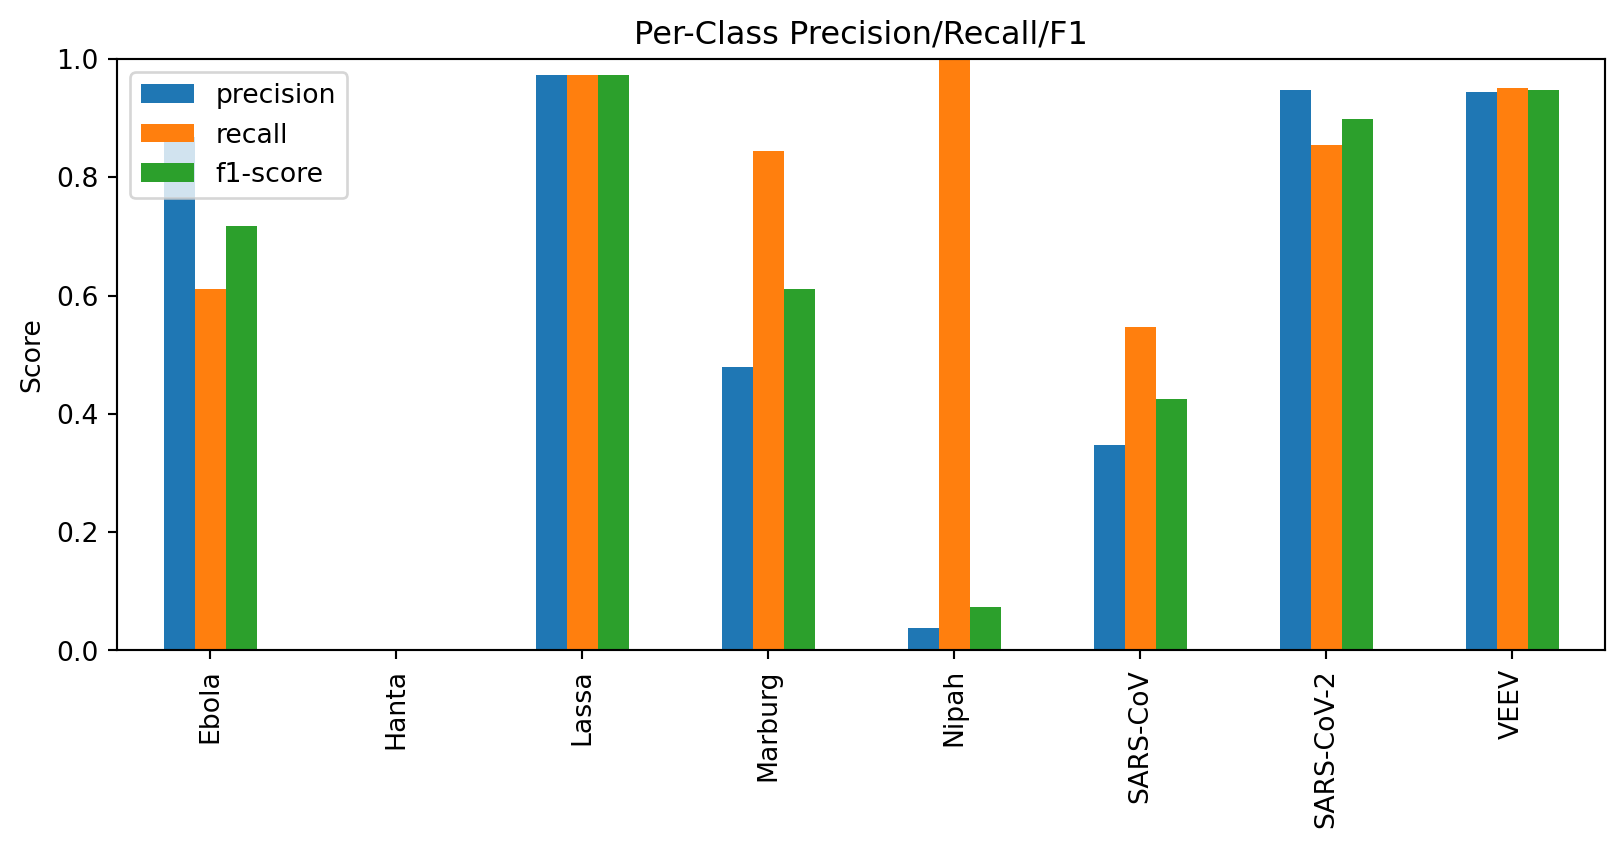

In [66]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

report = classification_report(yTrue, yPred, output_dict=True)
reportDF = pd.DataFrame(report).T.iloc[:-3]  # remove avg rows
reportDF[['precision','recall','f1-score']].plot(kind='bar', figsize=(10,4))
plt.title("Per-Class Precision/Recall/F1")
plt.ylabel("Score")
plt.ylim(0,1)
plt.savefig(saveDir + 'allVirus_CV_F1.svg', format='svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + 'allVirus_CV_F1.png', format='png', bbox_inches='tight', dpi=300)
plt.show()

### Refit on ALL valid data

In [67]:
finalGrid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=paramGridCls,
    scoring="f1_macro",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    refit=True,
    verbose=0
)
finalGrid.fit(XAllBits, yEncAllValid)
finalCls = finalGrid.best_estimator_
print(f"[Refit-All] Best params: {finalGrid.best_params_}")

[Refit-All] Best params: {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 800}


### In-sample metrics on ALL valid

In [68]:
yAllPredEnc = finalCls.predict(XAllBits)
yAllPredStr = labelEncoder.inverse_transform(yAllPredEnc)
print(f"[Refit-All] F1-macro (train): {f1_score(labelsStrValid, yAllPredStr, average='macro'):.3f}")
print(f"[Refit-All] Balanced Acc (train): {balanced_accuracy_score(labelsStrValid, yAllPredStr):.3f}")
print(f"[Refit-All] Accuracy (train): {accuracy_score(labelsStrValid, yAllPredStr):.3f}")

[Refit-All] F1-macro (train): 0.750
[Refit-All] Balanced Acc (train): 0.913
[Refit-All] Accuracy (train): 0.848


### Confusion Matrix

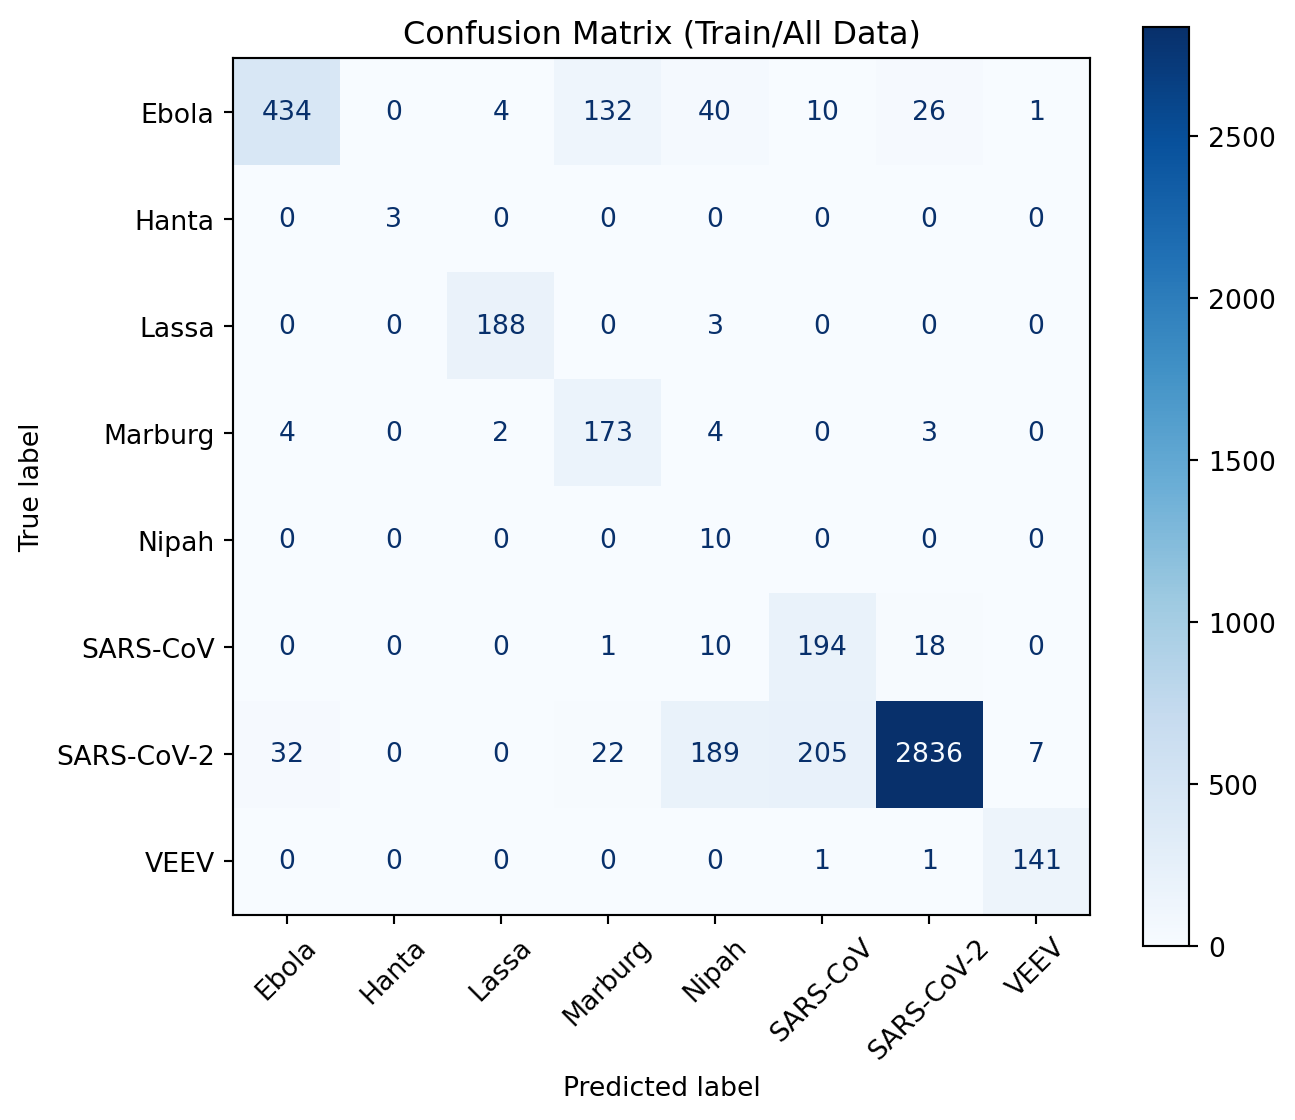

In [69]:
# --- Predictions on ALL (in-sample) ---
yPredEnc = finalCls.predict(XAllBits)

# Class labels (strings) for display
if 'labelEncoder' in globals():
    displayLabels = labelEncoder.classes_
    yTrueStr = labelEncoder.inverse_transform(yEncAllValid)
    yPredStr = labelEncoder.inverse_transform(yPredEnc)
else:
    # fallback: show encoded ints if no encoder is available
    displayLabels = finalCls.classes_
    yTrueStr = yEncAllValid
    yPredStr = yPredEnc


cm = confusion_matrix(yTrueStr, yPredStr, labels=displayLabels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=displayLabels)
fig, ax = plt.subplots(figsize=(7,6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=True)
ax.set_title("Confusion Matrix (Train/All Data)")
ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
plt.tight_layout()
plt.show()

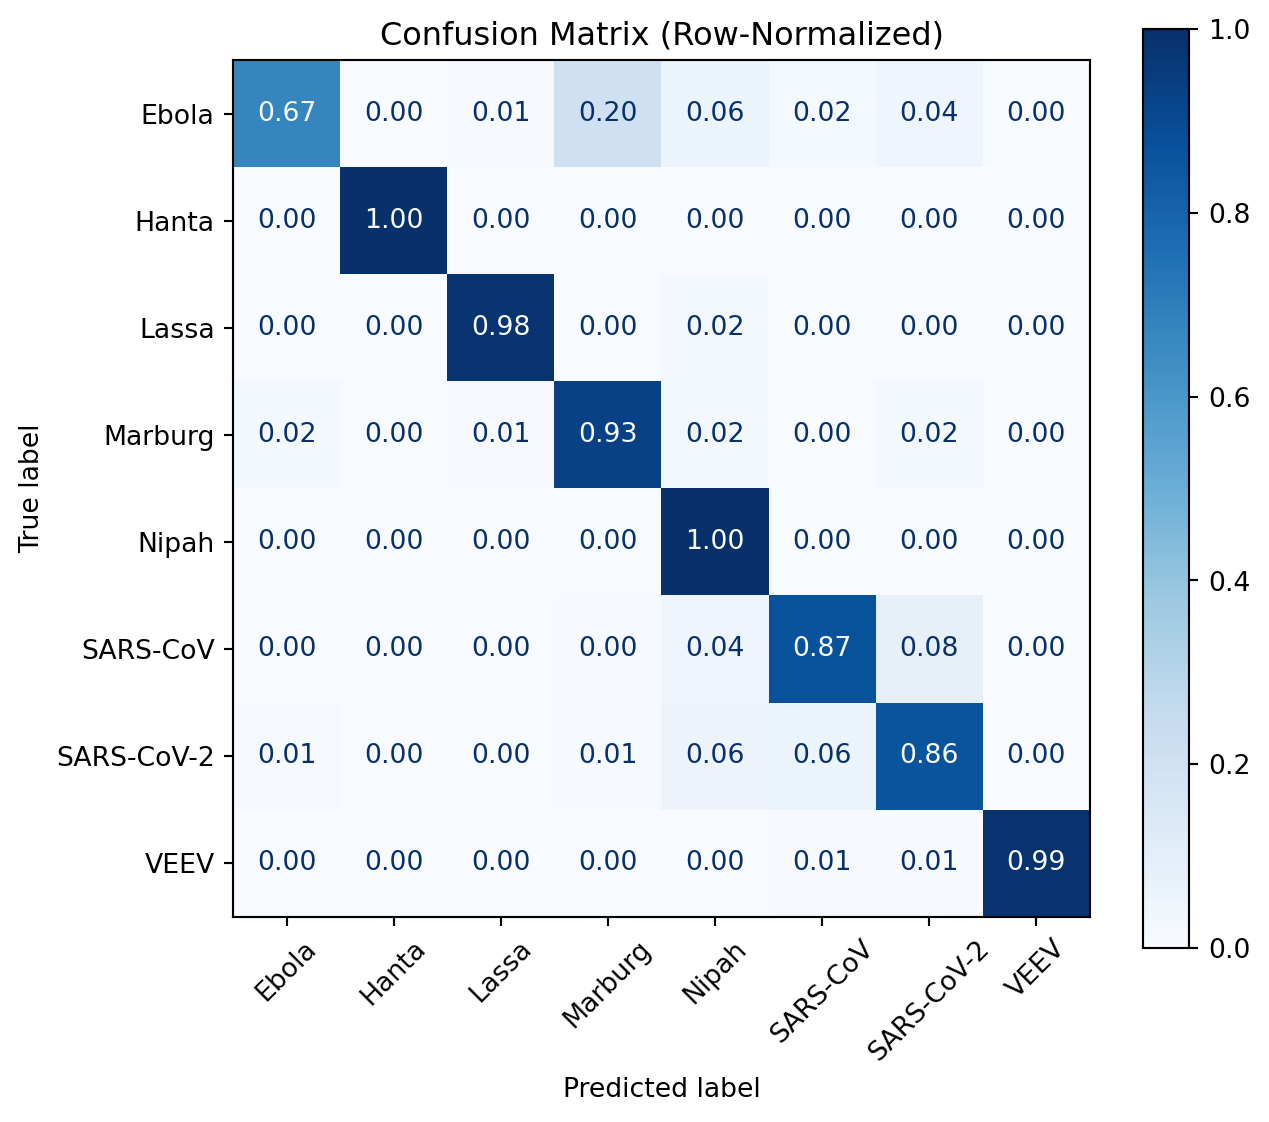

In [70]:
# Confusion matrix (row-normalized by true class)
cm_norm = confusion_matrix(yTrueStr, yPredStr, labels=displayLabels, normalize="true")
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=displayLabels)
fig, ax = plt.subplots(figsize=(7,6))
disp_norm.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=True, values_format=".2f")
ax.set_title("Confusion Matrix (Row-Normalized)")
ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
plt.tight_layout()
plt.savefig(saveDir + 'allVirus_fullData_ConMat.svg', format='svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + 'allVirus_fullData_ConMat.png', format='png', bbox_inches='tight', dpi=300)
plt.show()

### Per-class precision/recall/F1 values

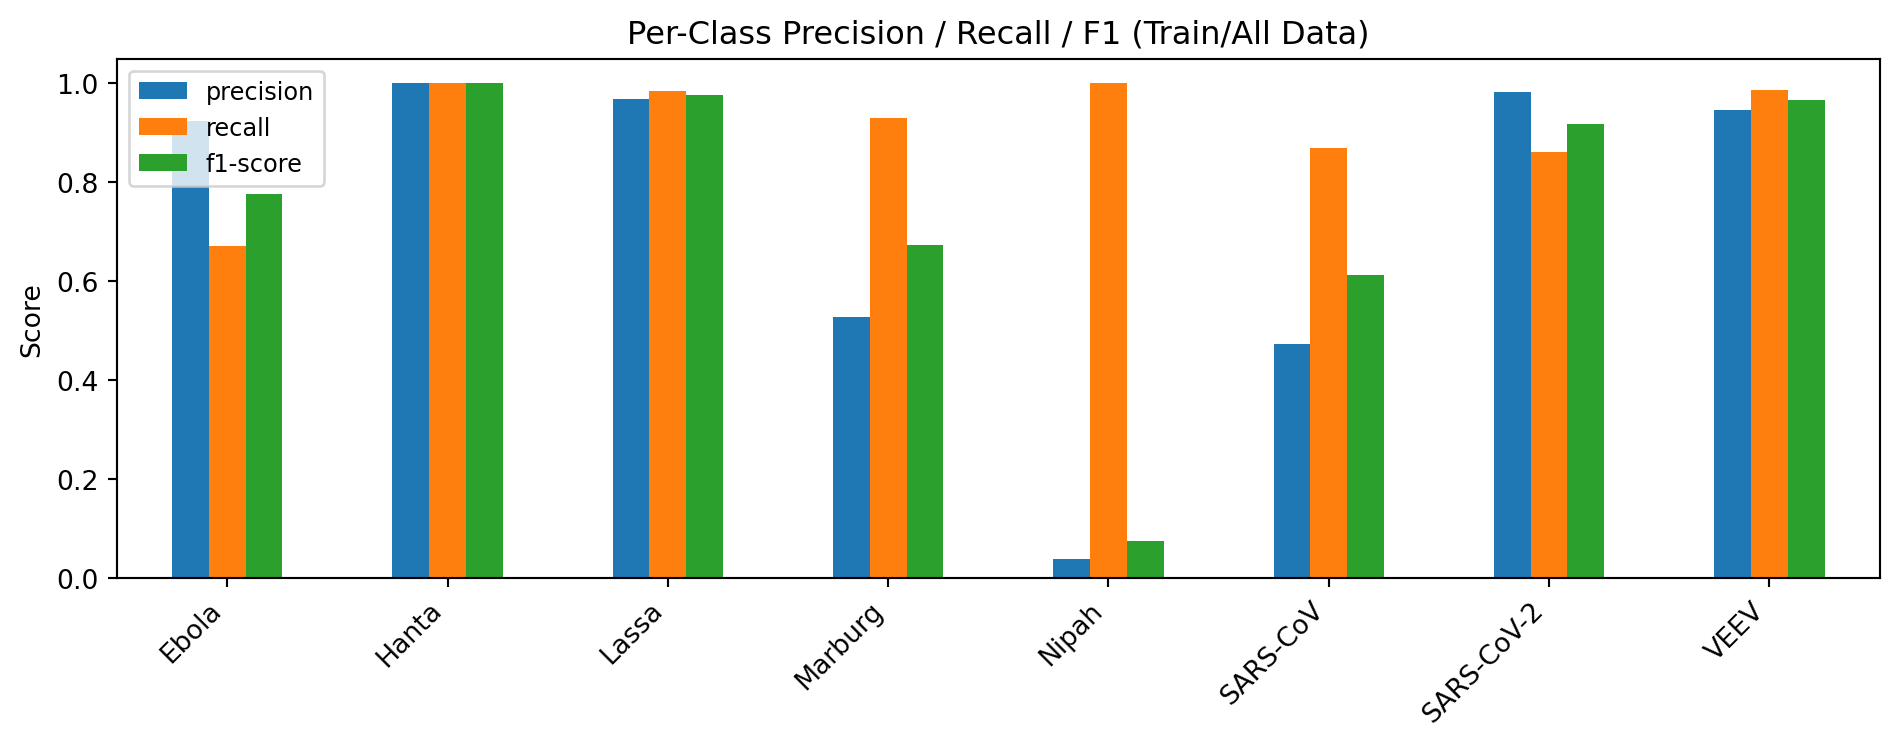

In [71]:
report = classification_report(yTrueStr, yPredStr, target_names=displayLabels, output_dict=True)
rep_df = pd.DataFrame(report).T.loc[displayLabels, ["precision", "recall", "f1-score"]]

ax = rep_df.plot(kind="bar", figsize=(10,4))
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Per-Class Precision / Recall / F1 (Train/All Data)")
plt.xticks(rotation=45, ha="right")
plt.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(saveDir + 'allVirus_fullData_F1.svg', format='svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + 'allVirus_fullData_F1.png', format='png', bbox_inches='tight', dpi=300)
plt.show()

# Validation

In [72]:
EnamineAntiviralsData = pd.read_csv( modelBuildingDataDir + "Enamine_antiviralsData.csv")
print(EnamineAntiviralsData.shape)
EnamineAntiviralsData.head()

(19490, 2)


,Smiles,Source
0,NC(=O)NC(=O)Cn1c(=O)c(C#N)cn(C2CC2)c1=O,Enamine_antivirals
1,CC(C)CNC(=O)Cn1c(=O)c(C#N)cn(C2CC2)c1=O,Enamine_antivirals
2,O=C(Cn1cccnc1=O)NC1CCCCCC1,Enamine_antivirals
3,CCC(=O)Nc1ccc(cn1)N1CCOCC1,Enamine_antivirals
4,Cc1nn(C)c(C)c1CC(=O)NC(C1CC1)C1CC1,Enamine_antivirals


Keep SMILES as strings

In [73]:
smi_enamine = EnamineAntiviralsData["Smiles"].astype(str).reset_index(drop=False)  # keeps 'index' column

Validate SMILES with RDKit

In [74]:
valid_mask = smi_enamine["Smiles"].apply(lambda s: Chem.MolFromSmiles(s) is not None).to_numpy()
valid_rows = smi_enamine.loc[valid_mask, "index"].to_numpy()
smi_valid  = smi_enamine.loc[valid_mask, "Smiles"].tolist()

print(f"[Enamine] valid molecular smiles: {len(smi_valid)} / {len(smi_enamine)}")

[Enamine] valid molecular smiles: 19490 / 19490


Regression on pPotency data

In [78]:
# MACAW features for Enamine (regression head)
X_enamine_reg = mcw.transform(smi_valid)

# Predict potency
Y_enamine_pred = regr_pred.predict(X_enamine_reg)  # regrPred = best GridSearchCV or best estimator

Plot the results

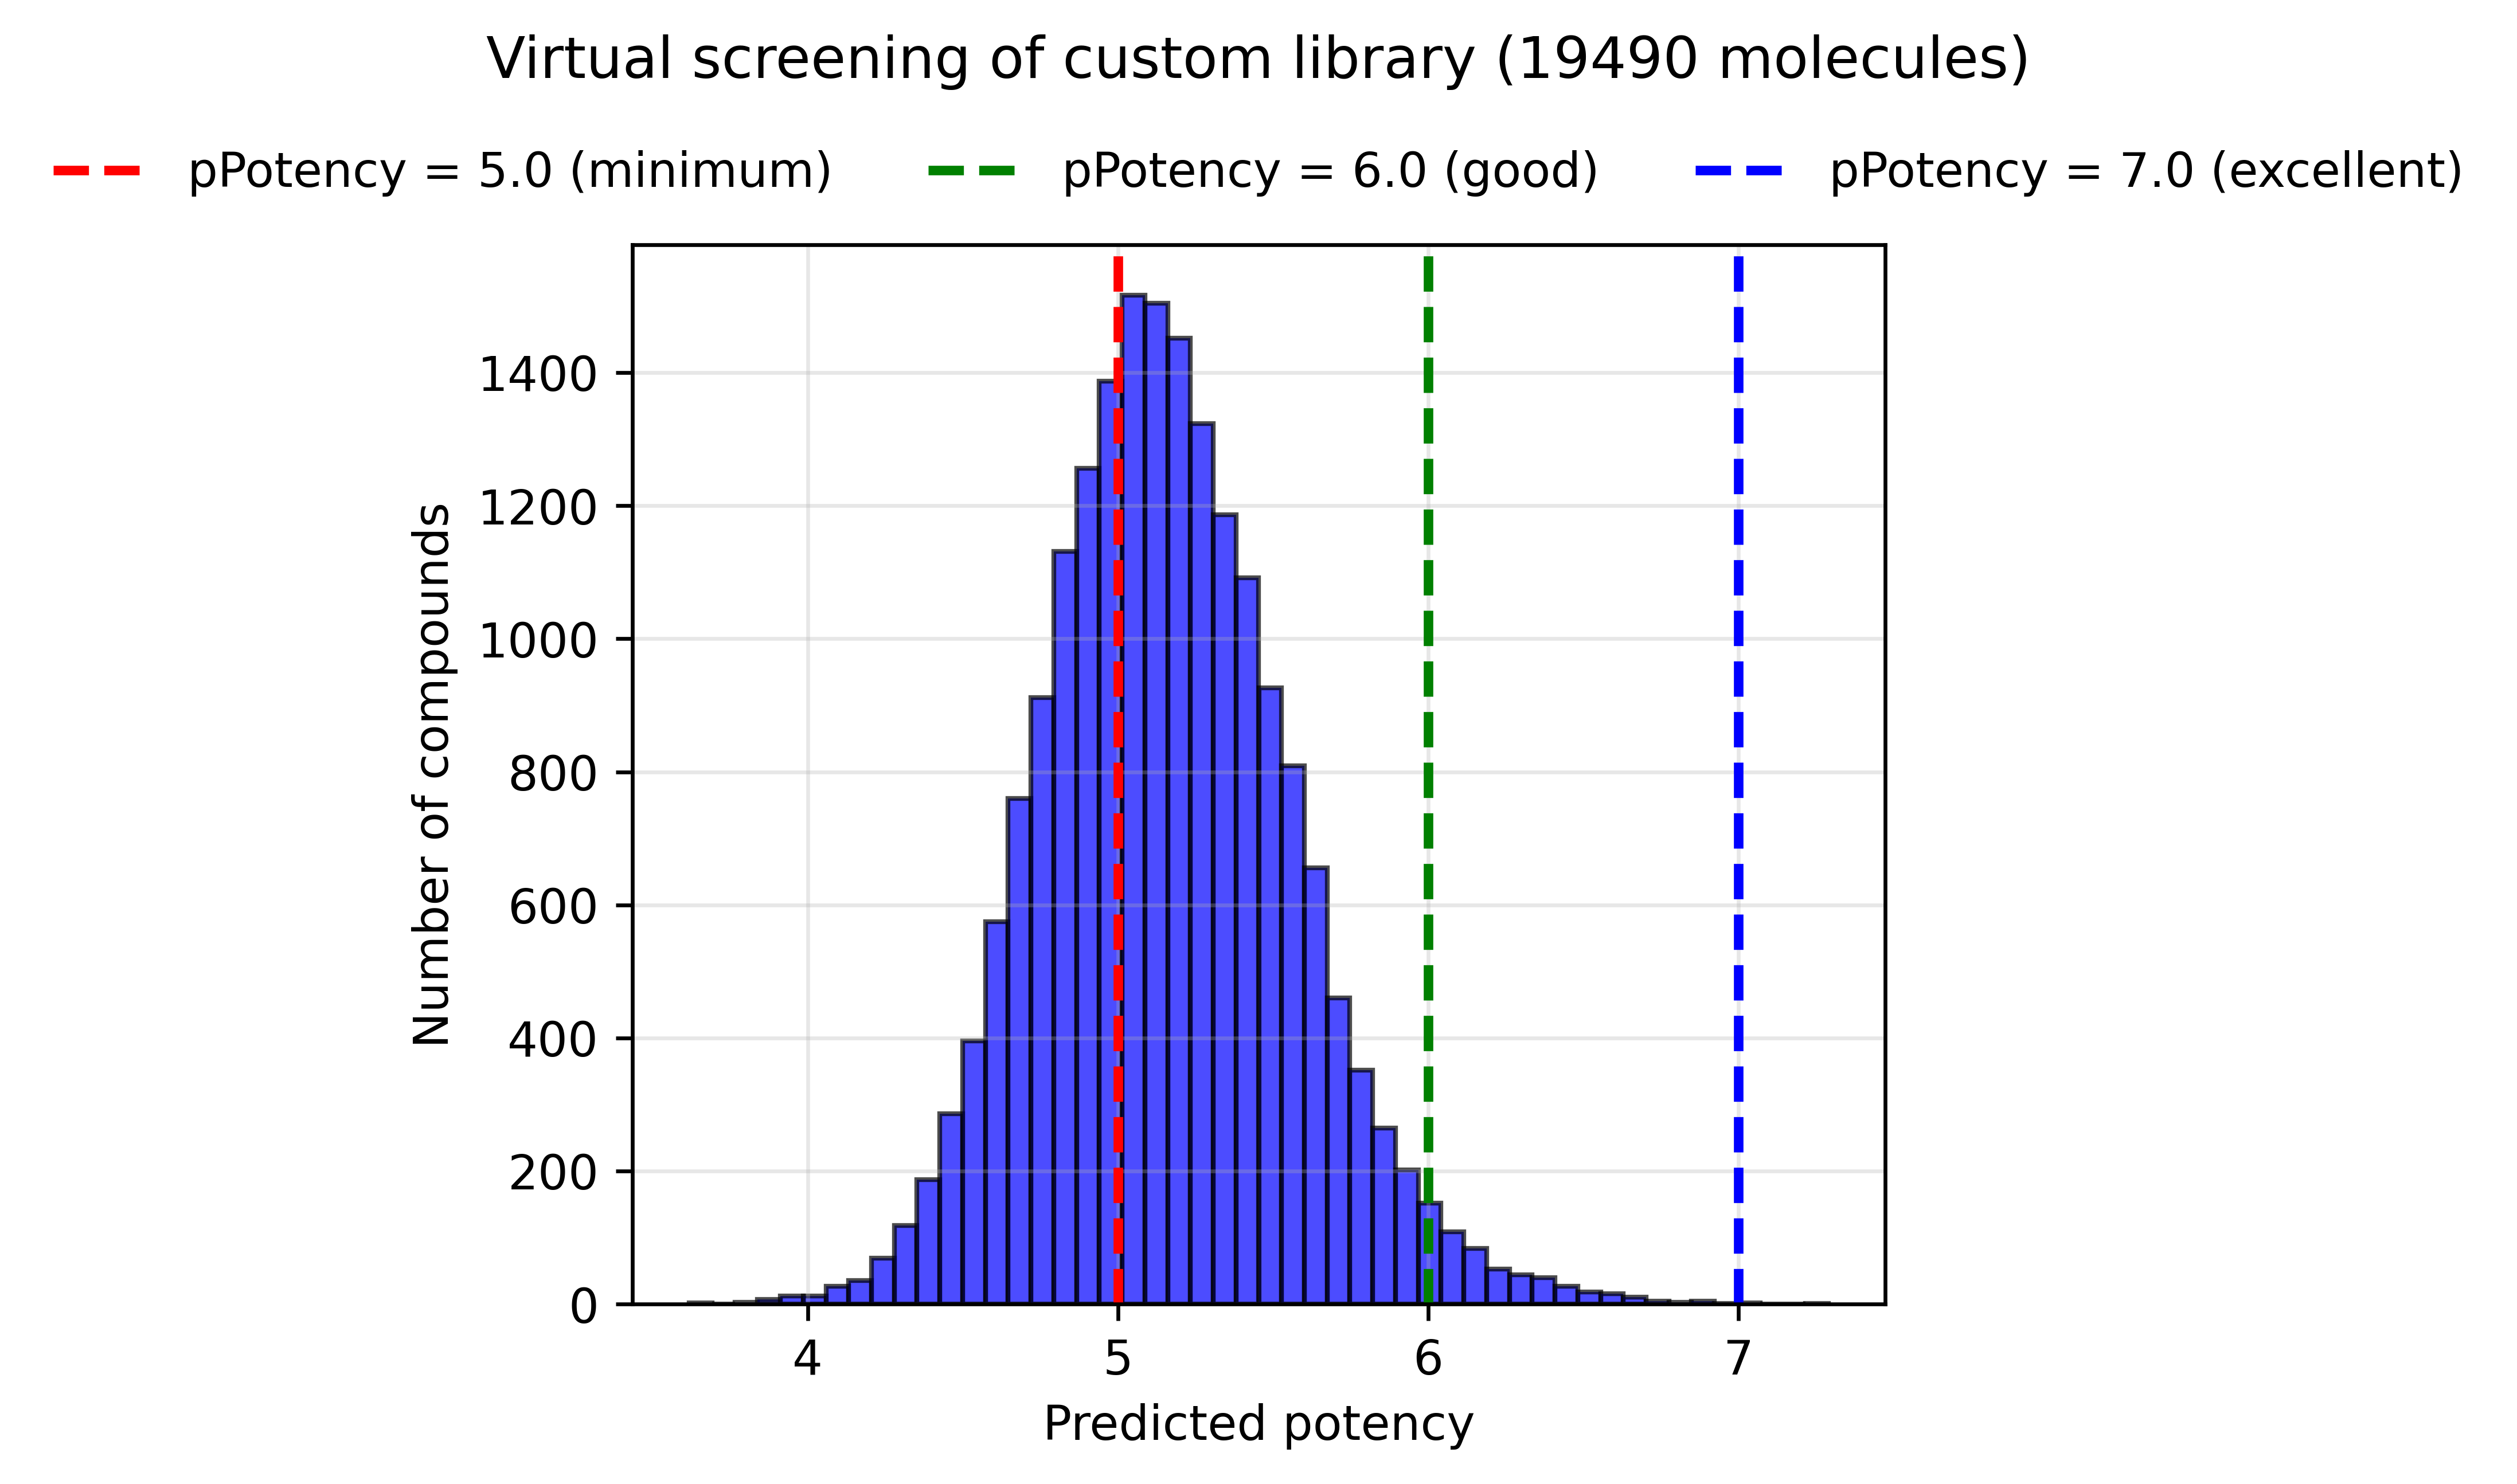

In [81]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y_enamine_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
plt.axvline(x=5, color='r', linestyle='--', linewidth=2, label='pPotency = 5.0 (minimum)') 
plt.axvline(x=6, color='g', linestyle='--', linewidth=2, label='pPotency = 6.0 (good)')
plt.axvline(x=7, color='b', linestyle='--', linewidth=2, label='pPotency = 7.0 (excellent)')

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + 'allVirus_validation_Reg.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + 'allVirus_validation_Reg.png', bbox_inches='tight', dpi=300)
plt.show()

In [84]:
# Define multiple priority levels
high_priority_idx = np.where(Y_enamine_pred >= 7)[0]
medium_priority_idx = np.where((Y_enamine_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y_enamine_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 3 compounds
Medium priority (6 ≤ pPotency < 7.0): 493 compounds
Low priority (5 ≤ pPotency < 6): 12088 compounds


In [85]:
EnamineAntiviralsData_final_Reg = EnamineAntiviralsData.iloc[idx].copy()
EnamineAntiviralsData_final_Reg['pPotency_prediction'] = Y_enamine_pred[idx]

EnamineAntiviralsData_final_Reg

,Smiles,Source,pPotency_prediction
4865,OC1Cc2ccccc2C1NC(=O)C1CCNC(=O)C1,Enamine_DDS1675,7.066303
16348,O=C(CC1Nc2ccccc2NC1=O)NCCc1ccccc1,Enamine_Phenotypic,7.290395
18443,C[C@]12CC[C@H]3[C@@H](CCc4cc(O)ccc34)[C@@H]1CC...,Enamine_Phenotypic,7.067511


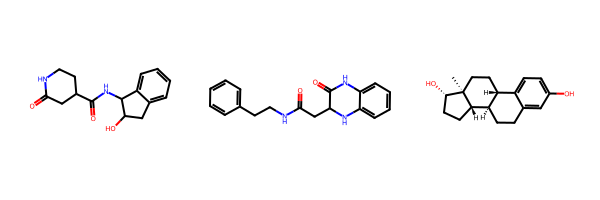

In [86]:
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntiviralsData_final_Reg.Smiles[:50]]

Draw.MolsToGridImage(molecules, subImgSize=(200,200), molsPerRow=3, useSVG=True)

### Classification task Enamine dataset

In [87]:
from rdkit.Chem import AllChem

def morganBits(smilesList, nBits=2048, radius=3):
    X = np.zeros((len(smilesList), nBits), dtype=np.uint8)
    for i, s in enumerate(smilesList):
        m = Chem.MolFromSmiles(s)
        if m is None: 
            continue
        fp = AllChem.GetMorganFingerprintAsBitVect(m, radius=radius, nBits=nBits)
        X[i, list(fp.GetOnBits())] = 1
    return X

X_enamine_cls = morganBits(smi_valid, nBits=2048, radius=3)

Predict class probabilities

In [88]:
# Predict probabilities and top-1 / top-3
proba = finalCls.predict_proba(X_enamine_cls)       # [n_valid, n_classes]
top1 = np.argmax(proba, axis=1)

# classes as strings
classes_str = labelEncoder.classes_ if "labelEncoder" in globals() else finalCls.classes_
predVirus_valid = classes_str[top1]
predVirusConf_valid = proba[np.arange(len(top1)), top1]

# Top-3 labels + probs (nice for triage)
top3_idx = np.argsort(-proba, axis=1)[:, :3]
predVirusTop3_valid = []
predVirusTop3Proba_valid = []
for r in range(top3_idx.shape[0]):
    labels3 = classes_str[top3_idx[r]]
    probs3 = [f"{labels3[j]}:{proba[r, top3_idx[r][j]]:.2f}" for j in range(len(labels3))]
    predVirusTop3_valid.append(", ".join(labels3))
    predVirusTop3Proba_valid.append(", ".join(probs3))


Assemble results in a table

In [89]:
def safeInsert(df, loc, name, values):
    if name in df.columns:
        df.drop(columns=[name], inplace=True)
    df.insert(loc, name, values)

# Start with a copy of the valid subset rows
EnamineAntiviralsData_final_Cls = EnamineAntiviralsData.iloc[valid_rows].copy()

# Attach regression (potency)
safeInsert(EnamineAntiviralsData_final_Cls, 0, "pred_pPotency", np.round(Y_enamine_pred, 3))

# Attach classification (virus)
safeInsert(EnamineAntiviralsData_final_Cls, 1, "predVirus", predVirus_valid)
safeInsert(EnamineAntiviralsData_final_Cls, 2, "predVirusConf", np.round(predVirusConf_valid, 3))
safeInsert(EnamineAntiviralsData_final_Cls, 3, "predVirusTop3", predVirusTop3_valid)
safeInsert(EnamineAntiviralsData_final_Cls, 4, "predVirusTop3Proba", predVirusTop3Proba_valid)

# Optional: composite rank for prioritization
alpha, beta = 1.0, 0.5
rankScore = alpha * EnamineAntiviralsData_final_Cls["pred_pPotency"].to_numpy() + \
            beta  * EnamineAntiviralsData_final_Cls["predVirusConf"].to_numpy()
safeInsert(EnamineAntiviralsData_final_Cls, 5, "rankScore", np.round(rankScore, 3))

print("[Enamine] final shape:", EnamineAntiviralsData_final_Cls.shape)
EnamineAntiviralsData_final_Cls.head()

[Enamine] final shape: (19490, 8)


,pred_pPotency,predVirus,predVirusConf,predVirusTop3,predVirusTop3Proba,rankScore,Smiles,Source
0,4.966,SARS-CoV-2,0.427,"SARS-CoV-2, Ebola, SARS-CoV","SARS-CoV-2:0.43, Ebola:0.18, SARS-CoV:0.17",5.180,NC(=O)NC(=O)Cn1c(=O)c(C#N)cn(C2CC2)c1=O,Enamine_antivirals
1,5.174,SARS-CoV-2,0.477,"SARS-CoV-2, SARS-CoV, Ebola","SARS-CoV-2:0.48, SARS-CoV:0.23, Ebola:0.13",5.413,CC(C)CNC(=O)Cn1c(=O)c(C#N)cn(C2CC2)c1=O,Enamine_antivirals
2,4.819,SARS-CoV-2,0.441,"SARS-CoV-2, SARS-CoV, Ebola","SARS-CoV-2:0.44, SARS-CoV:0.19, Ebola:0.16",5.040,O=C(Cn1cccnc1=O)NC1CCCCCC1,Enamine_antivirals
3,5.217,SARS-CoV-2,0.372,"SARS-CoV-2, Ebola, SARS-CoV","SARS-CoV-2:0.37, Ebola:0.20, SARS-CoV:0.17",5.403,CCC(=O)Nc1ccc(cn1)N1CCOCC1,Enamine_antivirals
4,4.999,SARS-CoV-2,0.429,"SARS-CoV-2, SARS-CoV, Ebola","SARS-CoV-2:0.43, SARS-CoV:0.20, Ebola:0.14",5.214,Cc1nn(C)c(C)c1CC(=O)NC(C1CC1)C1CC1,Enamine_antivirals


Filter for pred_pPotency >= 7.0

In [90]:
EnamineAntiviralsData_final_pPotency = EnamineAntiviralsData_final_Cls[
    EnamineAntiviralsData_final_Cls['pred_pPotency'] >= 7.0
]
EnamineAntiviralsData_final_pPotency

,pred_pPotency,predVirus,predVirusConf,predVirusTop3,predVirusTop3Proba,rankScore,Smiles,Source
4865,7.066,SARS-CoV-2,0.486,"SARS-CoV-2, SARS-CoV, Ebola","SARS-CoV-2:0.49, SARS-CoV:0.18, Ebola:0.14",7.309,OC1Cc2ccccc2C1NC(=O)C1CCNC(=O)C1,Enamine_DDS1675
16348,7.290,SARS-CoV-2,0.427,"SARS-CoV-2, SARS-CoV, Ebola","SARS-CoV-2:0.43, SARS-CoV:0.18, Ebola:0.17",7.504,O=C(CC1Nc2ccccc2NC1=O)NCCc1ccccc1,Enamine_Phenotypic
18443,7.068,SARS-CoV-2,0.417,"SARS-CoV-2, SARS-CoV, Ebola","SARS-CoV-2:0.42, SARS-CoV:0.22, Ebola:0.15",7.276,C[C@]12CC[C@H]3[C@@H](CCc4cc(O)ccc34)[C@@H]1CC...,Enamine_Phenotypic


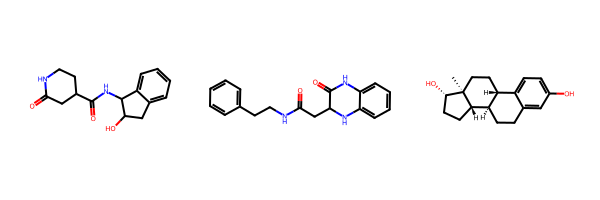

In [91]:
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntiviralsData_final_pPotency.Smiles[:50]]

Draw.MolsToGridImage(molecules, subImgSize=(200,200), molsPerRow=3, useSVG=True)

Filter for rankScore >= 7.0
 
 **rankScore=α×pred_pPotency+β×predVirusConf** (α = 1.0, β = 0.5)

* ≥ 7.5	--> Very promising (strong potency + good confidence)
* 7.0–7.5 -->	Potent hits, moderate confidence
* 6.0–7.0 -->	Potentially interesting, lower confidence or moderate potency
* < 6.0	--> Weak activity or uncertain classification

In [92]:
EnamineAntiviralsData_final_rankScore = EnamineAntiviralsData_final_Cls[
    EnamineAntiviralsData_final_Cls['rankScore'] >= 7.0
]
EnamineAntiviralsData_final_rankScore

,pred_pPotency,predVirus,predVirusConf,predVirusTop3,predVirusTop3Proba,rankScore,Smiles,Source
3442,6.852,SARS-CoV-2,0.373,"SARS-CoV-2, SARS-CoV, Ebola","SARS-CoV-2:0.37, SARS-CoV:0.22, Ebola:0.17",7.038,OC(=O)C1CC(NC(=O)C2CCOC2)c2ccccc12,Enamine_DDS252
4865,7.066,SARS-CoV-2,0.486,"SARS-CoV-2, SARS-CoV, Ebola","SARS-CoV-2:0.49, SARS-CoV:0.18, Ebola:0.14",7.309,OC1Cc2ccccc2C1NC(=O)C1CCNC(=O)C1,Enamine_DDS1675
4896,6.944,SARS-CoV-2,0.468,"SARS-CoV-2, SARS-CoV, Ebola","SARS-CoV-2:0.47, SARS-CoV:0.23, Ebola:0.13",7.178,CC(=O)NC(CC(=O)NC1C(O)Cc2ccccc12)c1ccccc1,Enamine_DDS1706
5989,6.874,SARS-CoV-2,0.422,"SARS-CoV-2, SARS-CoV, Ebola","SARS-CoV-2:0.42, SARS-CoV:0.21, Ebola:0.13",7.085,CC(C)C(=O)N1C[C@H]([C@@H](C1)c1ccccc1)C(=O)O,Enamine_DDS2799
6504,6.820,SARS-CoV-2,0.381,"SARS-CoV-2, Ebola, SARS-CoV","SARS-CoV-2:0.38, Ebola:0.19, SARS-CoV:0.18",7.010,OC1Cc2ccccc2C1NC(=O)NCCNC(=O)c1ccco1,Enamine_DDS3314
7223,6.922,SARS-CoV-2,0.450,"SARS-CoV-2, SARS-CoV, Ebola","SARS-CoV-2:0.45, SARS-CoV:0.27, Ebola:0.11",7.147,C[C@@H](NC(=O)N[C@@H]1C[C@H]1c1ccco1)c1ccc(F)cc1,Enamine_DDS4033
8016,6.894,SARS-CoV-2,0.491,"SARS-CoV-2, SARS-CoV, Ebola","SARS-CoV-2:0.49, SARS-CoV:0.23, Ebola:0.13",7.140,OC(=O)C[C@H](NC(=O)C1CCS(=O)(=O)N1)c1ccc2ccccc2c1,Enamine_DDS4826
16348,7.290,SARS-CoV-2,0.427,"SARS-CoV-2, SARS-CoV, Ebola","SARS-CoV-2:0.43, SARS-CoV:0.18, Ebola:0.17",7.504,O=C(CC1Nc2ccccc2NC1=O)NCCc1ccccc1,Enamine_Phenotypic
18358,6.771,SARS-CoV-2,0.520,"SARS-CoV-2, SARS-CoV, Ebola","SARS-CoV-2:0.52, SARS-CoV:0.16, Ebola:0.16",7.031,CCCCc1c(C)nc2nc(SCc3nc4n(CCCC)c(=O)[nH]c(=O)c4...,Enamine_Phenotypic
18443,7.068,SARS-CoV-2,0.417,"SARS-CoV-2, SARS-CoV, Ebola","SARS-CoV-2:0.42, SARS-CoV:0.22, Ebola:0.15",7.276,C[C@]12CC[C@H]3[C@@H](CCc4cc(O)ccc34)[C@@H]1CC...,Enamine_Phenotypic


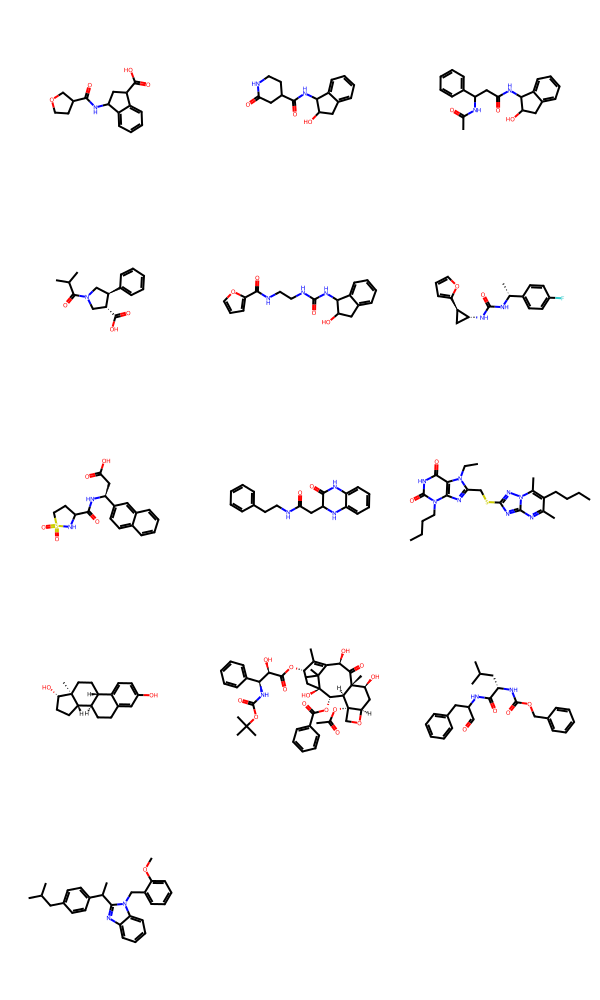

In [93]:
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntiviralsData_final_rankScore.Smiles[:50]]

Draw.MolsToGridImage(molecules, subImgSize=(200,200), molsPerRow=3, useSVG=True)

Filter for rankScore >= 7.5 (best predicted molecule)

In [94]:
EnamineAntiviralsData_final_rankScore_best = EnamineAntiviralsData_final_Cls[
    EnamineAntiviralsData_final_Cls['rankScore'] >= 7.5
]
EnamineAntiviralsData_final_rankScore_best

,pred_pPotency,predVirus,predVirusConf,predVirusTop3,predVirusTop3Proba,rankScore,Smiles,Source
16348,7.29,SARS-CoV-2,0.427,"SARS-CoV-2, SARS-CoV, Ebola","SARS-CoV-2:0.43, SARS-CoV:0.18, Ebola:0.17",7.504,O=C(CC1Nc2ccccc2NC1=O)NCCc1ccccc1,Enamine_Phenotypic


In [95]:
EnamineAntiviralsData_final_rankScore_best.shape

(1, 8)

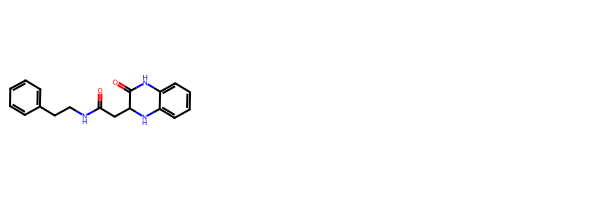

In [96]:
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntiviralsData_final_rankScore_best.Smiles[:50]]

Draw.MolsToGridImage(molecules, subImgSize=(200,200), molsPerRow=3, useSVG=True)

### Extract molecular properties of the best predicted drug molecule

In [97]:
bestDrugMoleculeSMILES = EnamineAntiviralsData_final_rankScore_best["Smiles"]

smilesList = bestDrugMoleculeSMILES.tolist()
print(f"Number of top molecules: {len(smilesList)}")

Number of top molecules: 1


Convert each SMILES to RDKit molecule objects

In [100]:
from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors

mols = [Chem.MolFromSmiles(smi) for smi in smilesList if Chem.MolFromSmiles(smi) is not None]
print(f"Successfully parsed {len(mols)} valid molecules out of {len(smilesList)}")

# Remove or fix the problematic line

molProps = []
for i, mol in enumerate(mols):
    props = {
        "index": i,
        "SMILES": Chem.MolToSmiles(mol),
        "MolWt": Descriptors.MolWt(mol),
        "LogP": Crippen.MolLogP(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "HBD": rdMolDescriptors.CalcNumHBD(mol),
        "HBA": rdMolDescriptors.CalcNumHBA(mol),
        "RotBonds": rdMolDescriptors.CalcNumRotatableBonds(mol),
        "AromaticRings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "HeavyAtoms": mol.GetNumHeavyAtoms(),
        "QED": Descriptors.qed(mol),
    }
    molProps.append(props)

molPropsDF = pd.DataFrame(molProps)
molPropsDF.head()

Successfully parsed 1 valid molecules out of 1


,index,SMILES,MolWt,LogP,TPSA,HBD,HBA,RotBonds,AromaticRings,HeavyAtoms,QED
0,0,O=C(CC1Nc2ccccc2NC1=O)NCCc1ccccc1,309.369,2.1682,70.23,3,3,5,2,23,0.792547


Add mordred properties

In [101]:
from mordred import Calculator, descriptors

# Build a calculator for ALL 2D descriptors (ignore 3D)
calc = Calculator(descriptors, ignore_3D=True)

# This returns a pandas DataFrame aligned to the order of `mols`
mordredDF = calc.pandas(mols, quiet=True, nproc=4)

# Mordred can output non-numeric and NaN/inf
# Replace infs with NaN
mordredDF = mordredDF.replace([np.inf, -np.inf], np.nan)
# Drop columns that are entirely NaN
mordredDF = mordredDF.dropna(axis=1, how="all")
# Keep only numeric columns
numericCols = mordredDF.select_dtypes(include=[np.number]).columns
mordredNumDF = mordredDF[numericCols].copy()
# Optionally fill remaining NaNs with 0 
mordredNumDF = mordredNumDF.fillna(0.0)

print(f"Mordred: {mordredDF.shape[1]} total columns, {mordredNumDF.shape[1]} numeric columns kept.")
mordredNumDF.head()

Mordred: 1613 total columns, 1453 numeric columns kept.


,ABC,ABCGG,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,LogEE_A,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
0,17.815569,13.474433,0,0,30.024382,2.391574,4.783148,30.024382,1.305408,4.056909,...,9.873595,56.955817,309.147727,7.36066,1394,32,116.0,132.0,6.416667,5.138889


Combine all the molecular descriptors

In [102]:
combinedDF = pd.concat(
    [molPropsDF.reset_index(drop=True), mordredNumDF.reset_index(drop=True)],
    axis=1
)
combinedDF

,index,SMILES,MolWt,LogP,TPSA,HBD,HBA,RotBonds,AromaticRings,HeavyAtoms,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
0,0,O=C(CC1Nc2ccccc2NC1=O)NCCc1ccccc1,309.369,2.1682,70.23,3,3,5,2,23,...,9.873595,56.955817,309.147727,7.36066,1394,32,116.0,132.0,6.416667,5.138889
